In [1]:
# from data_synthesizer.util import  plot_training_loss, ModelType
from typing import Tuple
import pandas as pd
import pickle

from data_loader import DataLoader
from data_synthesizer.pipeline import load_all_results

from evaluation_report.ressemblance_report import ResemblanceReport


In [2]:
import sys
from pathlib import Path

# Add repo root so `import experiments` works in notebooks.
sys.path.append(str(Path.cwd().parent.parent))

from experiments.paths import RESULTS_DIR, DATA_DIR, BASELINE_DIR, EXTRA_DIR


## Loading Data

In [3]:
cat_list_credit_card = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 'default.payment.next.month']
num_list_credit_card = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
credit_qai_columns = ['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE']
credit_risk_column = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','default.payment.next.month']

df_real_credit_card_train = DataLoader(f'{DATA_DIR}/credit_card_Train.csv').get_dataframe(cat_list_credit_card, str, drop_identation=True)
df_real_credit_card_test = DataLoader(f'{DATA_DIR}/credit_card_Test.csv').get_dataframe(cat_list_credit_card, str, drop_identation=True)
credit_real_dict ={'data' : df_real_credit_card_train, 'cat_list' : cat_list_credit_card, 'num_list' : num_list_credit_card}

In [4]:
cat_list_adult = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']
num_list_adult = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','native-country','income', 'race']
df_real_adult_train = DataLoader(f'{DATA_DIR}/adult_train.csv').get_dataframe(cat_list_adult, str)
df_real_adult_test = DataLoader(f'{DATA_DIR}/adult_test.csv').get_dataframe(cat_list_adult, str)

In [5]:
num_list_cardio = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_list_cardio = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

cardio_qai_columns = ['age','gender','height','weight']
cardio_risk_column = ['ap_lo','ap_hi','cholesterol','gluc','smoke','alco','active','cardio']

df_real_cardio_train = DataLoader(f'{DATA_DIR}/cardio_train.csv').get_dataframe(cat_list_cardio, category_type=str, sep = ',')
df_real_cardio_test = DataLoader(f'{DATA_DIR}/cardio_test.csv').get_dataframe(cat_list_cardio, category_type=str, sep = ',')

In [6]:
credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline').to_legacy_dict()
credit_tvae  = load_all_results(f'{BASELINE_DIR}/credit_tvae_baseline').to_legacy_dict()
# credit_ctgan_eps_001  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.01')
# credit_ctgan_eps_005  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.05')
# credit_ctgan_eps_01  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.1')
# credit_ctgan_eps_015  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.15')
# credit_ctgan_eps_02  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.2')
# credit_ctgan_eps_025  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.25')
# credit_ctgan_eps_03  = load_all_results('../scripts/epsilon_comparison/credit_ctgan_eps_0.3')


# credit_ctgan_eps_heom_001  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.01')
# credit_ctgan_eps_heom_005  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.05')
# credit_ctgan_eps_heom_01  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.1')
# credit_ctgan_eps_heom_015  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.15')
# credit_ctgan_eps_heom_02  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.2')
# credit_ctgan_eps_heom_025  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.25')
# credit_ctgan_eps_heom_03  = load_all_results('../scripts/epsilon_comparison_heom/credit_ctgan_eps_0.3')

# credit_ctgan_eps_tabnet_001  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.01')
# credit_ctgan_eps_tabnet_005  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.05')
# credit_ctgan_eps_tabnet_01  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.1')
# credit_ctgan_eps_tabnet_015  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.15')
# credit_ctgan_eps_tabnet_02  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.2')
# credit_ctgan_eps_tabnet_025  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.25')
# credit_ctgan_eps_tabnet_03  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.3')
# credit_ctgan_eps_tabnet_035  = load_all_results('../scripts/epsilon_comparison_tabnet/credit_ctgan_eps_0.35')

# credit_tvae_eps_001  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.01')
# credit_tvae_eps_005  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.05')
# credit_tvae_eps_01  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.1')
# credit_tvae_eps_015  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.15')
# credit_tvae_eps_02  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.2')
# credit_tvae_eps_025  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.25')
# credit_tvae_eps_03  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.3')
# credit_tvae_eps_035  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.35')
# credit_tvae_eps_04  = load_all_results('../scripts/epsilon_comparison/credit_tvae_eps_0.4')

# dict_results_credit_ctgan  = {
#     'credit CTGAN' : credit_ctgan,
#     'credit CTGAN 0.3' : credit_ctgan_eps_03,
#     'credit CTGAN 0.25' : credit_ctgan_eps_025,
#     'credit CTGAN 0.2' : credit_ctgan_eps_02,
#     'credit CTGAN 0.15' : credit_ctgan_eps_015,
#     'credit CTGAN 0.1' : credit_ctgan_eps_01,
#     'credit CTGAN 0.05' : credit_ctgan_eps_005,
#     'credit CTGAN 0.01' : credit_ctgan_eps_001,
# }

# dict_results_credit_ctgan_heom  = {
#     'credit CTGAN' : credit_ctgan,
#     'credit CTGAN 0.3' : credit_ctgan_eps_heom_03,
#     'credit CTGAN 0.25' : credit_ctgan_eps_heom_025,
#     'credit CTGAN 0.2' : credit_ctgan_eps_heom_02,
#     'credit CTGAN 0.15' : credit_ctgan_eps_heom_015,
#     'credit CTGAN 0.1' : credit_ctgan_eps_heom_01,
#     'credit CTGAN 0.05' : credit_ctgan_eps_heom_005,
#     'credit CTGAN 0.01' : credit_ctgan_eps_heom_001,
# }


# dict_results_credit_ctgan_tabnet  = {
#     'credit CTGAN' : credit_ctgan,
#     'credit CTGAN 0.35' : credit_ctgan_eps_tabnet_035,
#     'credit CTGAN 0.3' : credit_ctgan_eps_tabnet_03,
#     'credit CTGAN 0.25' : credit_ctgan_eps_tabnet_025,
#     'credit CTGAN 0.2' : credit_ctgan_eps_tabnet_02,
#     'credit CTGAN 0.15' : credit_ctgan_eps_tabnet_015,
#     'credit CTGAN 0.1' : credit_ctgan_eps_tabnet_01,
#     'credit CTGAN 0.05' : credit_ctgan_eps_tabnet_005,
#     'credit CTGAN 0.01' : credit_ctgan_eps_tabnet_001,
# }

# dict_results_credit_tvae  = {
#     'credit TVAE' : credit_tvae,
#     'credit TVAE 04' :credit_tvae_eps_04,
#     'credit TVAE 035' :credit_tvae_eps_035,
#     'credit TVAE 03' :credit_tvae_eps_03,
#     'credit TVAE 025' :credit_tvae_eps_025,
#     'credit TVAE 02' :credit_tvae_eps_02,
#     'credit TVAE 015' :credit_tvae_eps_015,
#     'credit TVAE 01' :credit_tvae_eps_01,
#     'credit TVAE 005' :credit_tvae_eps_005,
#     'credit TVAE 001' :credit_tvae_eps_001
# }


credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline').to_legacy_dict()
credit_tvae  = load_all_results(f'{BASELINE_DIR}/credit_tvae_baseline').to_legacy_dict()
credit_ctgan_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.005').to_legacy_dict()
credit_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.01').to_legacy_dict()
credit_ctgan_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.05').to_legacy_dict()
credit_ctgan_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.1').to_legacy_dict()
credit_ctgan_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.15').to_legacy_dict()
credit_ctgan_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.2').to_legacy_dict()
credit_ctgan_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.25').to_legacy_dict()
credit_ctgan_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.3').to_legacy_dict()
credit_ctgan_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.35').to_legacy_dict()
credit_ctgan_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.4').to_legacy_dict()

credit_tvae_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.005').to_legacy_dict()
credit_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.01').to_legacy_dict()
credit_tvae_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.05').to_legacy_dict()
credit_tvae_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.1').to_legacy_dict()
credit_tvae_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.15').to_legacy_dict()
credit_tvae_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.2').to_legacy_dict()
credit_tvae_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.25').to_legacy_dict()
credit_tvae_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.3').to_legacy_dict()
credit_tvae_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.35').to_legacy_dict()
credit_tvae_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.4').to_legacy_dict()

dict_results_credit_ctgan_heom_any  = {
    'credit CTGAN' : credit_ctgan,
    'credit CTGAN 0.4' : credit_ctgan_heom_any_eps_04,
    'credit CTGAN 0.35' : credit_ctgan_heom_any_eps_035,
    'credit CTGAN 0.3' : credit_ctgan_heom_any_eps_03,
    'credit CTGAN 0.25' : credit_ctgan_heom_any_eps_025,
    'credit CTGAN 0.2' : credit_ctgan_heom_any_eps_02,
    'credit CTGAN 0.15' : credit_ctgan_heom_any_eps_015,
    'credit CTGAN 0.1' : credit_ctgan_heom_any_eps_01,
    'credit CTGAN 0.05' : credit_ctgan_heom_any_eps_005,
    'credit CTGAN 0.01' : credit_ctgan_heom_any_eps_001,
    'credit CTGAN 0.005' : credit_ctgan_heom_any_eps_0005,    
}
dict_results_credit_tvae_heom_any  = {
    'credit TVAE' : credit_tvae,
    'credit TVAE 0.4' : credit_tvae_heom_any_eps_04,
    'credit TVAE 0.35' : credit_tvae_heom_any_eps_035,
    'credit TVAE 0.3' :credit_tvae_heom_any_eps_03,
    'credit TVAE 0.25' :credit_tvae_heom_any_eps_025,
    'credit TVAE 0.2' :credit_tvae_heom_any_eps_02,
    'credit TVAE 0.15' :credit_tvae_heom_any_eps_015,
    'credit TVAE 0.1' :credit_tvae_heom_any_eps_01,
    'credit TVAE 0.05' :credit_tvae_heom_any_eps_005,
    'credit TVAE 0.01' :credit_tvae_heom_any_eps_001,
    'credit TVAE 0.005' :credit_tvae_heom_any_eps_0005
}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [7]:
adult_ctgan  = load_all_results(f'{BASELINE_DIR}/adult_ctgan_baseline').to_legacy_dict()
adult_tvae  = load_all_results(f'{BASELINE_DIR}/adult_tvae_baseline').to_legacy_dict()
# adult_ctgan_eps_001  = load_all_results('../scripts/epsilon_comparison/adult_ctgan_eps_0.01')
# adult_ctgan_eps_005  = load_all_results('../scripts/epsilon_comparison/adult_ctgan_eps_0.05')
# adult_ctgan_eps_01  = load_all_results('../scripts/epsilon_comparison/adult_ctgan_eps_0.1')
# adult_ctgan_eps_015  = load_all_results('../scripts/epsilon_comparison/adult_ctgan_eps_0.15')
# adult_ctgan_eps_02  = load_all_results('../scripts/epsilon_comparison/adult_ctgan_eps_0.2')
# adult_ctgan_eps_025  = load_all_results('../scripts/epsilon_comparison/adult_ctgan_eps_0.25')
# adult_ctgan_eps_03  = load_all_results('../scripts/epsilon_comparison/adult_ctgan_eps_0.3')

# adult_tvae_eps_001  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.01')
# adult_tvae_eps_005  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.05')
# adult_tvae_eps_01  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.1')
# adult_tvae_eps_015  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.15')
# adult_tvae_eps_02  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.2')
# adult_tvae_eps_025  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.25')
# adult_tvae_eps_03  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.3')
# adult_tvae_eps_035  = load_all_results('../scripts/epsilon_comparison/adult_tvae_eps_0.35')

# dict_results_adult_ctgan  = {
#     'adult CTGAN' : adult_ctgan,
#     'adult CTGAN 0.3' : adult_ctgan_eps_03,
#     'adult CTGAN 0.25' : adult_ctgan_eps_025,
#     'adult CTGAN 0.2' : adult_ctgan_eps_02,
#     'adult CTGAN 0.15' : adult_ctgan_eps_015,
#     'adult CTGAN 0.1' : adult_ctgan_eps_01,
#     'adult CTGAN 0.05' : adult_ctgan_eps_005,
#     'adult CTGAN 0.01' : adult_ctgan_eps_001
# }
# dict_results_adult_tvae  = {
#     'adult TVAE' : adult_tvae,
#     'adult TVAE 0.35' : adult_tvae_eps_035,
#     'adult TVAE 03' :adult_tvae_eps_03,
#     'adult TVAE 025' :adult_tvae_eps_025,
#     'adult TVAE 02' :adult_tvae_eps_02,
#     'adult TVAE 015' :adult_tvae_eps_015,
#     'adult TVAE 01' :adult_tvae_eps_01,
#     'adult TVAE 005' :adult_tvae_eps_005,
#     'adult TVAE 001' :adult_tvae_eps_001
# }

adult_ctgan  = load_all_results(f'{BASELINE_DIR}/adult_ctgan_baseline').to_legacy_dict()
adult_tvae  = load_all_results(f'{BASELINE_DIR}/adult_tvae_baseline').to_legacy_dict()
adult_ctgan_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.005').to_legacy_dict()
adult_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.01').to_legacy_dict()
adult_ctgan_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.05').to_legacy_dict()
adult_ctgan_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.1').to_legacy_dict()
adult_ctgan_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.15').to_legacy_dict()
adult_ctgan_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.2').to_legacy_dict()
adult_ctgan_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.25').to_legacy_dict()
adult_ctgan_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.3').to_legacy_dict()
adult_ctgan_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.35').to_legacy_dict()
adult_ctgan_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.4').to_legacy_dict()

adult_tvae_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.005').to_legacy_dict()
adult_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.01').to_legacy_dict()
adult_tvae_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.05').to_legacy_dict()
adult_tvae_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.1').to_legacy_dict()
adult_tvae_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.15').to_legacy_dict()
adult_tvae_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.2').to_legacy_dict()
adult_tvae_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.25').to_legacy_dict()
adult_tvae_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.3').to_legacy_dict()
adult_tvae_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.35').to_legacy_dict()
adult_tvae_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.4').to_legacy_dict()

dict_results_adult_ctgan_heom_any  = {
    'adult CTGAN' : adult_ctgan,
    'adult CTGAN 0.4' : adult_ctgan_heom_any_eps_04,
    'adult CTGAN 0.35' : adult_ctgan_heom_any_eps_035,
    'adult CTGAN 0.3' : adult_ctgan_heom_any_eps_03,
    'adult CTGAN 0.25' : adult_ctgan_heom_any_eps_025,
    'adult CTGAN 0.2' : adult_ctgan_heom_any_eps_02,
    'adult CTGAN 0.15' : adult_ctgan_heom_any_eps_015,
    'adult CTGAN 0.1' : adult_ctgan_heom_any_eps_01,
    'adult CTGAN 0.05' : adult_ctgan_heom_any_eps_005,
    'adult CTGAN 0.01' : adult_ctgan_heom_any_eps_001,
    'adult CTGAN 0.005' : adult_ctgan_heom_any_eps_0005,    
}
dict_results_adult_tvae_heom_any  = {
    'adult TVAE' : adult_tvae,
    'adult TVAE 0.4' : adult_tvae_heom_any_eps_04,
    'adult TVAE 0.35' : adult_tvae_heom_any_eps_035,
    'adult TVAE 0.3' :adult_tvae_heom_any_eps_03,
    'adult TVAE 0.25' :adult_tvae_heom_any_eps_025,
    'adult TVAE 0.2' :adult_tvae_heom_any_eps_02,
    'adult TVAE 0.15' :adult_tvae_heom_any_eps_015,
    'adult TVAE 0.1' :adult_tvae_heom_any_eps_01,
    'adult TVAE 0.05' :adult_tvae_heom_any_eps_005,
    'adult TVAE 0.01' :adult_tvae_heom_any_eps_001,
    'adult TVAE 0.005' :adult_tvae_heom_any_eps_0005
}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [8]:
cardio_ctgan  = load_all_results(f'{BASELINE_DIR}/cardio_ctgan_baseline').to_legacy_dict()
cardio_tvae  = load_all_results(f'{BASELINE_DIR}/cardio_tvae_baseline').to_legacy_dict()
# cardio_ctgan_eps_001  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.01')
# cardio_ctgan_eps_005  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.05')
# cardio_ctgan_eps_01  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.1')
# cardio_ctgan_eps_015  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.15')
# cardio_ctgan_eps_02  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.2')
# cardio_ctgan_eps_025  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.25')
# cardio_ctgan_eps_03  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.3')
# cardio_ctgan_eps_035  = load_all_results('../scripts/epsilon_comparison/cardio_ctgan_eps_0.35')

# cardio_tvae_eps_001  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.01')
# cardio_tvae_eps_005  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.05')
# cardio_tvae_eps_01  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.1')
# cardio_tvae_eps_015  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.15')
# cardio_tvae_eps_02  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.2')
# cardio_tvae_eps_025  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.25')
# cardio_tvae_eps_03  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.3')
# cardio_tvae_eps_035  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.35')
# cardio_tvae_eps_04  = load_all_results('../scripts/epsilon_comparison/cardio_tvae_eps_0.4')
# # 
# dict_results_cardio_ctgan  = {
#     'cardio CTGAN' : cardio_ctgan,
#     'cardio CTGAN 0.35' : cardio_ctgan_eps_035,
#     'cardio CTGAN 0.3' : cardio_ctgan_eps_03,
#     'cardio CTGAN 0.25' : cardio_ctgan_eps_025,
#     'cardio CTGAN 0.2' : cardio_ctgan_eps_02,
#     'cardio CTGAN 0.15' : cardio_ctgan_eps_015,
#     'cardio CTGAN 0.1' : cardio_ctgan_eps_01,
#     'cardio CTGAN 0.05' : cardio_ctgan_eps_005,
#     'cardio CTGAN 0.01' : cardio_ctgan_eps_001
# }

# dict_results_cardio_tvae  = {
#     'cardio TVAE' : cardio_tvae,
#     'cardio TVAE 04' :cardio_tvae_eps_04,
#     'cardio TVAE 035' :cardio_tvae_eps_035,
#     'cardio TVAE 03' :cardio_tvae_eps_03,
#     'cardio TVAE 025' :cardio_tvae_eps_025,
#     'cardio TVAE 02' :cardio_tvae_eps_02,
#     'cardio TVAE 015' :cardio_tvae_eps_015,
#     'cardio TVAE 01' :cardio_tvae_eps_01,
#     'cardio TVAE 005' :cardio_tvae_eps_005,
#     'cardio TVAE 001' :cardio_tvae_eps_001
# }


cardio_ctgan  = load_all_results(f'{BASELINE_DIR}/cardio_ctgan_baseline').to_legacy_dict()
cardio_tvae  = load_all_results(f'{BASELINE_DIR}/cardio_tvae_baseline').to_legacy_dict()
cardio_ctgan_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.005').to_legacy_dict()
cardio_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.01').to_legacy_dict()
cardio_ctgan_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.05').to_legacy_dict()
cardio_ctgan_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.1').to_legacy_dict()
cardio_ctgan_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.15').to_legacy_dict()
cardio_ctgan_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.2').to_legacy_dict()
cardio_ctgan_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.25').to_legacy_dict()
cardio_ctgan_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.3').to_legacy_dict()
cardio_ctgan_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.35').to_legacy_dict()
cardio_ctgan_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.4').to_legacy_dict()

cardio_tvae_heom_any_eps_0005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.005').to_legacy_dict()
cardio_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.01').to_legacy_dict()
cardio_tvae_heom_any_eps_005  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.05').to_legacy_dict()
cardio_tvae_heom_any_eps_01  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.1').to_legacy_dict()
cardio_tvae_heom_any_eps_015  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.15').to_legacy_dict()
cardio_tvae_heom_any_eps_02  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.2').to_legacy_dict()
cardio_tvae_heom_any_eps_025  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.25').to_legacy_dict()
cardio_tvae_heom_any_eps_03  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.3').to_legacy_dict()
cardio_tvae_heom_any_eps_035  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.35').to_legacy_dict()
cardio_tvae_heom_any_eps_04  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.4').to_legacy_dict()

dict_results_cardio_ctgan_heom_any  = {
    'cardio CTGAN' : cardio_ctgan,
    'cardio CTGAN 0.4' : cardio_ctgan_heom_any_eps_04,
    'cardio CTGAN 0.35' : cardio_ctgan_heom_any_eps_035,
    'cardio CTGAN 0.3' : cardio_ctgan_heom_any_eps_03,
    'cardio CTGAN 0.25' : cardio_ctgan_heom_any_eps_025,
    'cardio CTGAN 0.2' : cardio_ctgan_heom_any_eps_02,
    'cardio CTGAN 0.15' : cardio_ctgan_heom_any_eps_015,
    'cardio CTGAN 0.1' : cardio_ctgan_heom_any_eps_01,
    'cardio CTGAN 0.05' : cardio_ctgan_heom_any_eps_005,
    'cardio CTGAN 0.01' : cardio_ctgan_heom_any_eps_001,
    'cardio CTGAN 0.005' : cardio_ctgan_heom_any_eps_0005,    
}
dict_results_cardio_tvae_heom_any  = {
    'cardio TVAE' : cardio_tvae,
    'cardio TVAE 0.4' : cardio_tvae_heom_any_eps_04,
    'cardio TVAE 0.35' : cardio_tvae_heom_any_eps_035,
    'cardio TVAE 0.3' :cardio_tvae_heom_any_eps_03,
    'cardio TVAE 0.25' :cardio_tvae_heom_any_eps_025,
    'cardio TVAE 0.2' :cardio_tvae_heom_any_eps_02,
    'cardio TVAE 0.15' :cardio_tvae_heom_any_eps_015,
    'cardio TVAE 0.1' :cardio_tvae_heom_any_eps_01,
    'cardio TVAE 0.05' :cardio_tvae_heom_any_eps_005,
    'cardio TVAE 0.01' :cardio_tvae_heom_any_eps_001,
    'cardio TVAE 0.005' :cardio_tvae_heom_any_eps_0005
}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

## Visualization of $\epsilon$ versus ressemblance univariate

### Utilities

In [9]:
def get_results_spec_dict(results_dict, keys):
    result_spec_dict = dict()
    for result_key, result_value  in results_dict.items() :
        nested_value = result_value
        for key in keys:
            nested_value = nested_value[key]
        result_spec_dict[result_key] = nested_value
    return result_spec_dict 

In [10]:
def get_jensen_shanon_num(results_dict) :
    js_num_dict = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_univariate','univariate_num_js','JS_divergence'])
    return js_num_dict

def get_cohen_num(results_dict) :
    cohen_num = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_univariate','univariate_num_js','cohen_s_d'])
    return cohen_num

def get_jensen_shanon_cat(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_univariate','jensen_shanon','JS_divergence'])
    return js_cat

def get_diff_norm_cramer_cat(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_multivariate','diff_norm_cramer'])
    return js_cat  

def get_cramer_spearman_correlation_coefficient_cat(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_multivariate','cramer_spearman_correlation_coefficient'])
    return js_cat  

def get_diff_norm_pearson_num(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_multivariate','pearson_norm_diff'])
    return js_cat  

def get_pearson_spearman_correlation_coefficient_num(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_multivariate','pearson_spearman_correlation_coefficient'])
    return js_cat  

def get_corr_ratio_spearman_correlation_coefficient_catnum(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_numerical_multivariate','corr_ratio_spearman_correlation_coefficient'])
    return js_cat  

def get_diff_norm_corr_ratio_catnum(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_numerical_multivariate','diff_norm_corr_ratio'])
    return js_cat  


In [11]:
def get_results_spec_dict(results_dict, keys):
    result_spec_dict = dict()
    for result_key, result_value  in results_dict.items() :
        nested_value = result_value
        for key in keys:
            nested_value = nested_value[key]
        result_spec_dict[result_key] = nested_value
    return result_spec_dict 

def get_jensen_shanon_num(results_dict) :
    js_num_dict = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_univariate','univariate_num_js','JS_divergence'])
    return js_num_dict

def get_cohen_num(results_dict) :
    cohen_num = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_univariate','univariate_num_js','cohen_s_d'])
    return cohen_num

def get_jensen_shanon_cat(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_univariate','jensen_shanon','JS_divergence'])
    return js_cat  

def get_synth_data(results_dict) :
    synth_data = get_results_spec_dict(results_dict, ['generation_results','synthetic_data'])
    return synth_data

def get_plotable_measure(dict_results) :

    dict_jensen_shanon  = get_jensen_shanon_cat(dict_results)
    dict_jensen_shanon_num  = get_jensen_shanon_num(dict_results)
    dict_cohen_num = get_cohen_num(dict_results)

    first_key = next(iter(dict_jensen_shanon))
    dict_ = {key : [] for key in dict_jensen_shanon[first_key].index}
    dict_num = {key : [] for key in dict_cohen_num[first_key].index}
    dict_num_js = {key : [] for key in dict_cohen_num[first_key].index}

    for key in dict_jensen_shanon :
        for index , value in zip(dict_jensen_shanon[key].index, dict_jensen_shanon[key]) :
            dict_[index].append(value) 

    for key in dict_cohen_num :
        for index , value in zip(dict_cohen_num[key].index, dict_cohen_num[key]) :
            dict_num[index].append(value) 

    for key in dict_jensen_shanon_num :
        for index , value in zip(dict_jensen_shanon_num[key].index, dict_jensen_shanon_num[key]) :
            dict_num_js[index].append(value) 

    return dict_, dict_num_js, dict_num



In [12]:
import numpy as np


def sort_by_epsilon(dict_measure: dict, epsilons: np.ndarray):
    """
    Re‑order every feature vector in `dict_measure` according to *ascending*
    ε so tighter constraints appear to the **right** on the plot.
    Returns the sorted epsilons and a new dictionary with aligned values.
    """
    order = np.argsort(epsilons)          # ascending: 0.01 … 0.33
    eps_sorted = epsilons[order]          # shape (k,)

    dict_sorted = {feat: np.asarray(vals)[order] 
                   for feat, vals in dict_measure.items()}
    return eps_sorted, dict_sorted

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_privacy_vs_quality_to_keep_1(
        dict_measure: dict,
        epsilons: np.ndarray,            # [baseline ε̂_no-filter, τ₁, τ₂, ..., τm]
        metric_label: str,
        baseline_eps: float,             # ε̂ at no-filter (e.g., 0.43)
        title_suffix: str = "",
        *,
        ax=None,                         # NEW: draw into an existing axis
        show_panel_title: bool = True,   # NEW: turn off per-panel titles for grids
        show_axis_labels: bool = True,   # NEW: turn off x/y labels for grids (use fig.supxlabel/supylabel)
        include_features=None,
        highlight_features=None,
        feature_palette=None,
        legend_outside: bool = True,
        legend_cols: int = 1,
        show_legend: bool = True,        # NEW: allow turning legend entries off per panel
        # Baseline display
        omit_baseline_from_curves: bool = True,
        show_baseline_strip: bool = True,
        baseline_strip_side: str = "left",   # "left" | "right"
        strip_pad_frac: float = 0.10,
        jitter_frac: float = 0.006,
        show_baseline_median: bool = True,
        show_baseline_mean_diamond: bool = True,
        # Visual polish
        thin_alpha: float = 0.25,
        thick_alpha: float = 0.95,
        thin_lw: float = 0.9,
        thick_lw: float = 1.6,
        mean_lw: float = 2.6,
        band_alpha: float = 0.14,
        # Annotations
        annotation_mode: str = "compact",    # "compact" | "none" | "full"
        put_delta_in_title: bool = True,
        # Layout / margins
        x_margin: float = 0.00,
        y_margin: float = 0.08,
        right_pad_after_invert: float = 0.10,
        left_pad_after_invert:  float = 0.02,
        right_tight_rect: float = 0.78,
        # Export
        savepath: str = None,
        dpi: int = 300
    ):
    """
    Publication-grade panel: measure vs. privacy threshold τ.

    - The x-axis shows τ thresholds (smaller τ ⇒ tighter).
    - The baseline (no filter) is shown as a slim strip at the side with one dot per feature.
    - If ax is provided, the function draws into that axis and DOES NOT call tight_layout().
    """

    # ---- feature selection ----
    if include_features is not None:
        dict_measure = {k: v for k, v in dict_measure.items() if k in include_features}

    highlight_features = set(highlight_features or [])

    # ---- arrays ----
    epsilons = np.asarray(epsilons)

    # Locate the baseline column (ε̂ at no filter).
    if np.any(np.isclose(epsilons, baseline_eps)):
        bidx = int(np.where(np.isclose(epsilons, baseline_eps))[0][0])
    else:
        # Safety: if baseline value is NOT in epsilons, assume it is the first column.
        bidx = 0

    feats = list(dict_measure.keys())
    if not feats:
        raise ValueError("No features to plot.")

    vals  = np.vstack([np.asarray(dict_measure[f]) for f in feats])  # (K, E)
    K, E  = vals.shape
    if E != len(epsilons):
        raise ValueError("Length mismatch: arrays in dict_measure must align with 'epsilons'.")

    # sort features by *baseline* value (desc) so legend follows what you see
    baseline_vec = vals[:, bidx]
    order = np.argsort(-baseline_vec)
    feats = [feats[i] for i in order]
    vals  = vals[order, :]
    baseline_vec = baseline_vec[order]

    # colors
    default_cmap = cm.get_cmap("tab10", K)
    def get_colour(i, feat):
        if feature_palette and feat in feature_palette:
            return feature_palette[feat]
        return default_cmap(i % default_cmap.N)

    # mask baseline from τ-sweep if requested
    if omit_baseline_from_curves:
        mask = np.ones(E, dtype=bool); mask[bidx] = False
    else:
        mask = np.ones(E, dtype=bool)

    taus_plot = epsilons[mask]     # interpret remaining values as τ thresholds
    mat_plot  = vals[:, mask]      # (K, E_eff)
    m_mean    = mat_plot.mean(axis=0)
    m_std     = mat_plot.std(axis=0)

    # ---- axes handling ----
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
        created_fig = True
    else:
        fig = ax.figure

    # curves: feature-wise measure across τ
    for i, feat in enumerate(feats):
        y = mat_plot[i]
        ax.plot(
            taus_plot, y,
            lw=thick_lw if feat in highlight_features else thin_lw,
            alpha=thick_alpha if feat in highlight_features else thin_alpha,
            color=get_colour(i, feat),
            zorder=2 if feat in highlight_features else 1,
            label=feat if (feat in highlight_features and show_legend) else None
        )

    # mean ± std across features
    ax.plot(
        taus_plot, m_mean, marker='o', lw=mean_lw, color='black',
        label=(f"mean {metric_label}" if show_legend else None), zorder=3
    )
    ax.fill_between(
        taus_plot, m_mean - m_std, m_mean + m_std,
        alpha=band_alpha, color='black', zorder=2,
        label=("± 1 std" if show_legend else None)
    )

    # baseline strip (outside τ-axis)
    x_lo, x_hi = float(np.min(taus_plot)), float(np.max(taus_plot))
    if show_baseline_strip:
        span = abs(x_hi - x_lo); pad = span * strip_pad_frac if span > 0 else 0.05
        # choose 'left' so after inversion it appears on the left, separate from τ-axis
        x_ref = (x_hi + pad) if baseline_strip_side == "left" else (x_lo - pad)

        ax.axvline(x_ref, linestyle=":", linewidth=1.0, alpha=.5, zorder=1)
        ax.annotate(
            "baseline\n(no filter)", xy=(x_ref, 1), xycoords=('data', 'axes fraction'),
            xytext=(4, -4), textcoords='offset points',
            rotation=90, va='top', ha='left', fontsize='small'
        )

        rng = np.random.default_rng(12345)
        jitter = (rng.uniform(-1, 1, size=K) * span * jitter_frac)
        for i, b in enumerate(baseline_vec):
            ax.plot(
                [x_ref + jitter[i]], [b], 'o',
                ms=4.0 if feats[i] in highlight_features else 3.2,
                alpha=0.9 if feats[i] in highlight_features else 0.6,
                color=get_colour(i, feats[i]), zorder=4
            )

        if show_baseline_median:
            b_med = float(np.median(baseline_vec))
            ax.hlines(
                b_med, x_ref - pad * 0.16, x_ref + pad * 0.16,
                colors='black', linewidth=1.4, zorder=5
            )

        if show_baseline_mean_diamond:
            b_mean = float(np.mean(baseline_vec))
            ax.plot(
                [x_ref], [b_mean], marker='D', ms=6,
                color='black', zorder=6,
                label=(f"baseline mean {metric_label}" if show_legend else None)
            )

        # include strip in limits + tiny extra
        extra = (abs(x_hi - x_lo) if abs(x_hi - x_lo) > 0 else 1.0) * 0.03
        ax.set_xlim(min(x_lo, x_ref), max(x_hi, x_ref) + extra)
    else:
        ax.set_xlim(min(x_lo, x_hi), max(x_lo, x_hi))

    # --- annotations ---
    j = int(np.argmin(m_mean)) if len(taus_plot) else 0
    if annotation_mode != "none" and len(taus_plot) > 0:
        ax.plot([taus_plot[j]], [m_mean[j]], marker='o', ms=5.5, color='black', zorder=6)
        if annotation_mode == "compact":
            ax.annotate(
                f"τ*={taus_plot[j]:g}", xy=(taus_plot[j], m_mean[j]),
                xytext=(6, 8), textcoords="offset points",
                ha="left", va="bottom", fontsize="small"
            )
        elif annotation_mode == "full":
            ax.annotate(
                f"min mean at τ={taus_plot[j]:g}\n{metric_label}={m_mean[j]:.3f}",
                xy=(taus_plot[j], m_mean[j]),
                xytext=(8, 10), textcoords="offset points",
                ha="left", va="bottom", fontsize="small",
                arrowprops=dict(arrowstyle='-', lw=0.8, color='black', shrinkA=2, shrinkB=2)
            )

    # --- title ---
    title = f"{metric_label} vs. τ {title_suffix}".strip()
    if put_delta_in_title and show_baseline_strip and len(taus_plot) > 0:
        delta = m_mean[j] - np.mean(baseline_vec)
        title += f"  —  Δ mean vs baseline: {delta:+.3f}"

    if show_panel_title:
        ax.set_title(title)

    # cosmetics
    if show_axis_labels:
        ax.set_xlabel("privacy threshold τ  (lower ⇒ tighter)")
        ax.set_ylabel(metric_label)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")

    ax.grid(True, alpha=.3)

    # invert x so higher τ is on the left
    ax.invert_xaxis()

    # explicit inner padding after inversion
    x1, x2 = ax.get_xlim()                 # with inverted axis, x1 > x2
    lo, hi = min(x1, x2), max(x1, x2)
    span = hi - lo if hi > lo else 1.0
    lo_padded = lo - span * left_pad_after_invert
    hi_padded = hi + span * right_pad_after_invert
    if x1 > x2:
        ax.set_xlim(hi_padded, lo_padded)
    else:
        ax.set_xlim(lo_padded, hi_padded)

    # small y margin
    ax.margins(x=x_margin, y=y_margin)

    # legend (only if requested; do not tight_layout when part of a larger figure)
    if show_legend:
        if legend_outside:
            ax.legend(
                frameon=False, ncol=legend_cols,
                bbox_to_anchor=(1.02, 1), loc="upper left",
                borderaxespad=0., fontsize="small"
            )
            if created_fig:
                plt.tight_layout(rect=[0, 0, right_tight_rect, 1])
        else:
            ax.legend(frameon=False, fontsize="small")
            if created_fig:
                plt.tight_layout()

    # y-lims with modest headroom (include baseline)
    y_min = min(float(np.min(mat_plot)), float(np.min(baseline_vec)))
    y_max = max(float(np.max(mat_plot)), float(np.max(baseline_vec)))
    if y_max > y_min:
        margin = (y_max - y_min) * 0.06
        ax.set_ylim(y_min - margin, y_max + margin)

    if savepath and created_fig:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    return fig, ax


In [14]:

def print_js_cohen(dict_results, epsilon) :
    means = {}
    js = {}
    for results, key in  zip(dict_results.values(), epsilon) :
        categorical_univariate_result = results['resemblance_evaluation_results']['categorical_univariate']
        numerical_univariate_result = results['resemblance_evaluation_results']['numerical_univariate']
        jensen_shanon_mean = categorical_univariate_result['jensen_shanon']
        cohen = numerical_univariate_result['univariate_num_js']['cohen_s_d']
        js[key] = jensen_shanon_mean['JS_divergence']
        means[key] = cohen
    print(pd.DataFrame(means))
    print(pd.DataFrame(js).to_markdown())

In [15]:
def get_mean_univariate_evaluation_markdown(dict_results, epsilon):
    means = {}
    for results, key in  zip(dict_results.values(), epsilon) :
        categorical_univariate_result = results['resemblance_evaluation_results']['categorical_univariate']
        numerical_univariate_result = results['resemblance_evaluation_results']['numerical_univariate']
        jensen_shanon_mean = categorical_univariate_result['jensen_shanon_data_mean']
        cohen = numerical_univariate_result['univariate_num_js']['cohen_s_d']
        means[key] = [jensen_shanon_mean['JS_divergence'], cohen.mean()]
    df = pd.DataFrame(means, index=['categorical JS divergence mean', "numerical cohen's d mean"])
    print(df.to_markdown())

In [16]:
import numpy as np
import pandas as pd
from typing import Dict, Iterable, List, Tuple, Optional

def _value_probs(s: pd.Series, include_na: bool = False) -> pd.Series:
    """
    Probability mass of a categorical series.
    """
    if include_na:
        s = s.astype("object").where(s.notna(), "NaN")
        return s.value_counts(dropna=False, normalize=True)
    return s.value_counts(dropna=True, normalize=True)

def js_contrib_discrete(
    p: pd.Series,
    q: pd.Series,
    base: int = 2
) -> Tuple[pd.DataFrame, float, float]:
    """
    Per-category contributions to Jensen–Shannon divergence between two discrete
    distributions p (REAL) and q (SYNTH).

    Parameters
    ----------
    p, q : pd.Series
        Index are categories, values are probabilities that sum to 1 (they will
        be reindexed to the union of categories; missing categories get 0).
    base : int
        Log base; 2 yields JS in bits (SciPy uses base=2 and reports sqrt(JS)).

    Returns
    -------
    contrib_df : pd.DataFrame
        Columns: [category, p, q, m, js_contrib, abs_diff, direction]
        Sorted by js_contrib desc. Sum(js_contrib) == JS divergence.
    js_divergence : float
        Jensen–Shannon divergence (base-2).
    js_distance : float
        sqrt(JS divergence); matches scipy.spatial.distance.jensenshannon.
    """
    idx = p.index.union(q.index)
    p = p.reindex(idx, fill_value=0.0).astype(float)
    q = q.reindex(idx, fill_value=0.0).astype(float)
    m = 0.5 * (p + q)

    # Handle terms where p or q is zero by continuity: t*log(t/m) -> 0 when t=0.
    with np.errstate(divide='ignore', invalid='ignore'):
        term_p = np.where(p > 0, p * np.log(p / m), 0.0)
        term_q = np.where(q > 0, q * np.log(q / m), 0.0)
    js_contrib = 0.5 * (term_p + term_q) / np.log(base)

    contrib_df = pd.DataFrame({
        "category": idx,
        "p": p.values,
        "q": q.values,
        "m": m.values,
        "js_contrib": js_contrib,
        "abs_diff": np.abs(q.values - p.values),
        "direction": np.where(q.values > p.values, "over",
                        np.where(q.values < p.values, "under", "match"))
    }).sort_values("js_contrib", ascending=False).reset_index(drop=True)

    js_div = float(contrib_df["js_contrib"].sum())
    js_dist = float(np.sqrt(js_div))
    return contrib_df, js_div, js_dist

def explain_js_by_mode(
    real_df: pd.DataFrame,
    synth_dfs: Dict[str, pd.DataFrame],
    cat_cols: Optional[Iterable[str]] = None,
    include_na: bool = False,
    top_k: int = 5,
    min_prob: float = 0.0
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each categorical feature and each synthetic dataset, identify the
    categories ("modes") that contribute most to the JS divergence from REAL.

    Parameters
    ----------
    real_df : pd.DataFrame
        Real/reference data.
    synth_dfs : dict[str, pd.DataFrame]
        Mapping of synthetic dataset name -> DataFrame (same schema as real_df).
        Example: {"credit CTGAN 0.3": df_03, "credit CTGAN 0.01": df_001}
    cat_cols : iterable[str] or None
        Categorical columns to evaluate. If None, infers columns of dtype
        'object' or 'category'.
    include_na : bool
        If True, treats NaN as a category called "NaN".
    top_k : int
        Number of top categories to summarize per feature.
    min_prob : float
        Drop categories in BOTH p and q whose probability <= min_prob
        (helps hide ultra-rare noise in reports; does not change totals).

    Returns
    -------
    contribs : pd.DataFrame
        Long-format per-category contributions with columns:
        [dataset, feature, category, real_prob, synth_prob, abs_diff,
         js_contrib, js_divergence, js_distance, rank, pct_of_js, direction]
        Note: js_divergence/distance repeat per row for convenience.
    summary : pd.DataFrame
        One row per [dataset, feature] with totals and a compact 'top_modes'
        string that explains the leading drivers.

    Notes
    -----
    - Sum of js_contrib over categories equals JS divergence for that pair.
    - JS distance equals sqrt(JS divergence) and matches SciPy's function.
    """
    if cat_cols is None:
        cat_cols = [
            c for c in real_df.columns
            if (pd.api.types.is_categorical_dtype(real_df[c]) or
                pd.api.types.is_object_dtype(real_df[c]))
        ]

    all_rows = []
    summary_rows = []

    for feature in cat_cols:
        p = _value_probs(real_df[feature], include_na=include_na)

        for dname, sdf in synth_dfs.items():
            q = _value_probs(sdf[feature], include_na=include_na)
            contrib_df, js_div, js_dist = js_contrib_discrete(p, q, base=2)

            # Optionally suppress categories that are tiny in both p and q
            if min_prob > 0:
                mask_keep = ~((contrib_df["p"] <= min_prob) &
                              (contrib_df["q"] <= min_prob))
                contrib_df = contrib_df[mask_keep].copy()

            contrib_df["dataset"] = dname
            contrib_df["feature"] = feature
            contrib_df = contrib_df.rename(columns={"p": "real_prob",
                                                    "q": "synth_prob"})

            # Ranking & percent contribution
            contrib_df["rank"] = contrib_df["js_contrib"].rank(
                method="first", ascending=False
            ).astype(int)
            contrib_df["pct_of_js"] = (
                100.0 * contrib_df["js_contrib"] / js_div
                if js_div > 0 else 0.0
            )

            # Repeat totals on each row for convenience
            contrib_df["js_divergence"] = js_div
            contrib_df["js_distance"] = js_dist
            all_rows.append(contrib_df)

            # Build a compact top-k explanation string
            top = contrib_df.nsmallest(0, "js_contrib")  # placeholder
            top = contrib_df.sort_values("js_contrib", ascending=False).head(top_k)
            # Format like: "cat=2: 23.1% (over by +0.041)"
            formatted = [
                f"{str(r.category)}: {r.pct_of_js:.1f}% "
                f"({'over' if r.direction=='over' else 'under'} by "
                f"{(r.synth_prob - r.real_prob):+.3f})"
                for r in top.itertuples(index=False)
            ]
            summary_rows.append({
                "dataset": dname,
                "feature": feature,
                "JS_divergence": js_div,
                "JS_distance": js_dist,
                "top_modes": "; ".join(formatted)
            })

    contribs = (pd.concat(all_rows, ignore_index=True)
                  .sort_values(["dataset", "feature", "js_contrib"], ascending=[True, True, False])
                  .reset_index(drop=True))
    summary = (pd.DataFrame(summary_rows)
                 .sort_values(["feature", "JS_distance"])
                 .reset_index(drop=True))
    return contribs, summary


In [17]:
# ==========================================
# Synthetic tabular divergence & visualization toolkit
# (REAL first; legend + notes auto-stack in right gutter; no repeated colors)
# ==========================================
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import to_hex
from matplotlib.offsetbox import AnchoredText
from scipy.stats import gaussian_kde, ks_2samp, wasserstein_distance

# ---------- Utilities ----------
def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def _extract_epsilon(name: str):
    """Best-effort parse of epsilon from dataset name; returns float or None."""
    m = re.findall(r'(\d+(?:\.\d+)?)', str(name))
    if not m:
        return None
    try:
        return float(m[-1])
    except Exception:
        return None

def _order_nonreal_by_eps(names):
    items = [(k, _extract_epsilon(k)) for k in names]
    if sum(e is not None for _, e in items) >= max(2, len(items)//2):
        return [k for k,_ in sorted(items, key=lambda x: (-1 if x[1] is None else -x[1], str(x[0])))]
    return sorted(names, key=str)

def _sorted_dataset_names(datasets):
    """
    REAL-first ordering:
      - any key ending with 'REAL' appears first (keep their original relative order),
      - all others sorted by epsilon descending (fallback alphabetical).
    """
    names = list(datasets.keys())
    real = [k for k in names if str(k).strip().endswith("REAL")]
    nonreal = [k for k in names if k not in real]
    return real + _order_nonreal_by_eps(nonreal)

# ---- Color sets (hand-picked, colorblind-safe) ----
_OKABE_ITO = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#F0E442", "#000000"
]
_TOL_BRIGHT = [
    "#4477AA", "#EE6677", "#228833", "#CCBB44",
    "#66CCEE", "#AA3377", "#BBBBBB"
]
_TABLEAU10 = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"
]
_TAB20 = [to_hex(cm.get_cmap("tab20")(i)) for i in range(20)]  # fallback

def _js_divergence(p: np.ndarray, q: np.ndarray, base: float = 2.0) -> float:
    """Jensen–Shannon divergence (finite for nonnegative vectors summing to 1)."""
    p = np.asarray(p, dtype=float); q = np.asarray(q, dtype=float)
    p = p / (p.sum() + 1e-16); q = q / (q.sum() + 1e-16)
    m = 0.5 * (p + q)
    def _kl(a, b):
        mask = (a > 0) & (b > 0)
        return np.sum(a[mask] * (np.log(a[mask] / b[mask]) / np.log(base)))
    return 0.5 * (_kl(p, m) + _kl(q, m))

def _get_distinct_palette(n: int, mode: str = "category") -> list[str]:
    """Return n distinct, high-contrast colors without repeats."""
    if n <= 0:
        return []
    bank = (_OKABE_ITO + _TOL_BRIGHT + _TABLEAU10 + _TAB20) if mode == "category" \
           else (_TOL_BRIGHT + _TABLEAU10 + _OKABE_ITO + _TAB20)
    if n <= len(bank):
        return bank[:n]
    # last resort: evenly spaced HSV
    extra = n - len(bank)
    hsv = [to_hex(cm.hsv(x)) for x in np.linspace(0, 1, extra, endpoint=False)]
    return bank + hsv

def _stable_color_lookup(keys, *, mode: str = "category"):
    """Deterministic map: sorted string keys → distinct colors."""
    skeys = [str(k) for k in keys]
    skeys = list(dict.fromkeys(sorted(skeys)))
    palette = _get_distinct_palette(len(skeys), mode=mode)
    return {k: c for k, c in zip(skeys, palette)}

def _build_palette(dataset_names):
    """Datasets palette: distinct, high-contrast; no repeats within a figure."""
    return _stable_color_lookup([str(n) for n in dataset_names], mode="dataset")

def _legend_outside(ax, ncol=1, title=None, fontsize=9):
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=False,
        ncol=ncol,
        title=title,
        fontsize=fontsize,
    )

# ----- Right-gutter helpers (prevent overlap) -----
def _tight_with_right_gutter(fig, right_gutter_frac=0.36):
    """Tight layout but reserve a right gutter for legend/notes."""
    fig.tight_layout(rect=(0.0, 0.0, 1.0 - right_gutter_frac, 1.0))

def _legend_outside_topright(ax, ncol=2, title=None, fontsize=9, xpad=0.02):
    """
    Legend pinned to the top of the right gutter.
    RETURNS the Legend object so we can measure its height.
    """
    leg = ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.0 + xpad, 1.0),
        borderaxespad=0.0,
        frameon=False,
        ncol=ncol,
        title=title,
        fontsize=fontsize,
        alignment="left",
    )
    return leg

def _add_block_right_below(ax, header: str, lines: list[str], y_top_ax: float,
                           xpad=0.02, fontsize=8, vgap_ax=0.012):
    """
    Add a header+lines text block in the right gutter, whose TOP is at y_top_ax
    (axes coords). Returns the new y (bottom of block) so the next block can
    be stacked directly underneath with a small vertical gap.
    """
    text = header + ("\n" + "\n".join(lines) if lines else "")
    t = ax.text(1.0 + xpad, y_top_ax, text,
                transform=ax.transAxes, ha="left", va="top",
                fontsize=fontsize)
    fig = ax.figure
    fig.canvas.draw()  # ensure sizes are computed
    bbox_disp = t.get_window_extent(renderer=fig.canvas.get_renderer())
    bbox_ax = bbox_disp.transformed(ax.transAxes.inverted())
    height_ax = bbox_ax.height
    y_bottom_ax = y_top_ax - height_ax
    return y_bottom_ax - vgap_ax


# ============================
# Main analysis & plotting
# ============================
def analyze_synth_distributions(
    datasets: dict,
    cat_features: list,
    num_features: list,
    baseline: str | None = None,
    out_dir: str = "./analysis_out",
    kde_points: int = 512,
    kde_bw_adjust: float = 1.0,
    density_diff_threshold: float = 0.20,
    max_categories_to_plot: int = 20,
    figure_dpi: int = 150,
):
    """
    Returns
    -------
    dict with:
      - divergence_table_path, ranking_table_path (CSV files)
      - divergence_table, ranking_table (pd.DataFrame)
      - plot_dir (PNG figures)
      - ordered_names, palette, baseline
    """
    _ensure_dir(out_dir)
    plot_dir = os.path.join(out_dir, "plots")
    _ensure_dir(plot_dir)

    # REAL-first ordering and baseline selection
    ordered_names = _sorted_dataset_names(datasets)
    if baseline is None:
        reals = [k for k in ordered_names if str(k).strip().endswith("REAL")]
        baseline = reals[0] if reals else ordered_names[0]
    if baseline not in datasets:
        raise ValueError(f"Baseline '{baseline}' not in datasets.")

    # Colors per dataset (stable)
    palette = _build_palette(ordered_names)

    rows = []

    # ----- Categorical -----
    for feat in cat_features:
        # Union of categories across datasets
        cats = set()
        for name, df in datasets.items():
            if feat in df.columns:
                vals = df[feat].astype("object")
                cats.update(pd.Series(vals).dropna().unique().tolist())
        if not cats:
            continue

        # Order by baseline frequency
        base_vals = datasets[baseline][feat].astype("object")
        base_counts = base_vals.value_counts(dropna=True)
        cat_order = [c for c in base_counts.index.tolist() if c in cats]
        for c in cats:
            if c not in cat_order:
                cat_order.append(c)

        keep = cat_order[:max_categories_to_plot-1] if len(cat_order) > max_categories_to_plot else cat_order

        # Prob vectors
        prob_by_ds = {}
        for name, df in datasets.items():
            v = df[feat].astype("object")
            counts = v.value_counts(dropna=True)
            vec = []
            for c in (keep + (["Other"] if len(cat_order) > max_categories_to_plot else [])):
                if c == "Other":
                    other = counts.drop(index=keep, errors="ignore").sum()
                    vec.append(float(other))
                else:
                    vec.append(float(counts.get(c, 0.0)))
            vec = np.asarray(vec, dtype=float) + 1e-9
            prob_by_ds[name] = vec / vec.sum()

        base_p = prob_by_ds[baseline]

        # Divergences and average log2 fold-change for annotation
        avg_log2fc = np.zeros_like(base_p); n_comp = 0
        for name, p in prob_by_ds.items():
            if name == baseline:
                continue
            # JS in base 2 already (internal helper returns base chosen; we keep as base2 by dividing log base)
            jsd = _js_divergence(base_p, p)  # base=2
            tv = 0.5 * np.abs(base_p - p).sum()
            rows.append({
                "feature": feat, "type": "categorical", "dataset": name, "baseline": baseline,
                "JS_divergence": jsd, "TV_distance": tv,
                "Wasserstein": np.nan, "KS": np.nan,
                "n_baseline": int(datasets[baseline].shape[0]), "n_dataset": int(datasets[name].shape[0])
            })
            avg_log2fc += np.log2((p + 1e-15) / (base_p + 1e-15)); n_comp += 1
        if n_comp > 0:
            avg_log2fc /= n_comp

        # ----- Plot: 100% stacked bars (REAL first), legend + notes auto-stack in gutter -----
        fig = plt.figure(figsize=(10.8, 4.9), dpi=figure_dpi)
        ax = plt.gca()
        x = np.arange(len(ordered_names))
        bottoms = np.zeros(len(ordered_names))

        # Legend order: categories by baseline proportion (desc), 'Other' last
        if len(cat_order) > max_categories_to_plot:
            keys_for_plot = sorted(keep, key=lambda c: base_p[keep.index(c)], reverse=True) + ["Other"]
        else:
            keys_for_plot = sorted(keep, key=lambda c: base_p[keep.index(c)], reverse=True)

        # UNIQUE colors per category (no repeats); neutral for "Other"
        cat_colors = _stable_color_lookup([str(k) for k in keys_for_plot], mode="category")
        if "Other" in keys_for_plot:
            cat_colors["Other"] = "#9FA3A6"

        order_full = keep + (["Other"] if len(cat_order) > max_categories_to_plot else [])
        for c in keys_for_plot:
            idx = order_full.index(c)
            heights = np.array([prob_by_ds[name][idx] for name in ordered_names])
            ax.bar(
                x, heights, bottom=bottoms, label=str(c),
                color=cat_colors[str(c)], edgecolor="white", linewidth=0.6
            )
            bottoms += heights

        ax.set_xticks(x)
        ax.set_xticklabels(ordered_names, rotation=35, ha="right")
        ax.set_ylabel("Proportion")
        ax.set_title(f"{feat} — composition across synthetic thresholds (stacked)")
        ax.set_ylim(0, 1.0)
        ax.yaxis.set_major_locator(MaxNLocator(5))

        # --- Right gutter: reserve space, legend, then stack blocks under it ---
        _tight_with_right_gutter(fig, right_gutter_frac=0.38)
        leg = _legend_outside_topright(ax, ncol=2, title="Category", fontsize=9, xpad=0.02)

        # measure legend bottom to start first block below it
        fig.canvas.draw()
        leg_bbox_disp = leg.get_window_extent(renderer=fig.canvas.get_renderer())
        leg_bbox_ax = leg_bbox_disp.transformed(ax.transAxes.inverted())
        y_cursor = leg_bbox_ax.y0 - 0.015  # small gap under legend

        def idx_to_label(idx):
            c = order_full[int(idx)]
            fc = float(avg_log2fc[int(idx)])
            sign = "+" if fc >= 0 else ""
            return f"{c}: {sign}{fc:.2f} log2FC"

        order_by_fc = np.argsort(avg_log2fc)
        top_idx = order_by_fc[-3:] if len(order_by_fc) >= 3 else order_by_fc
        bot_idx = order_by_fc[:3]  if len(order_by_fc) >= 3 else order_by_fc

        over_lines  = [idx_to_label(i) for i in top_idx[::-1]]
        under_lines = [idx_to_label(i) for i in bot_idx]

        # auto-stack the two blocks (no overlap)
        y_cursor = _add_block_right_below(ax, "Over-represented vs baseline:", over_lines,
                                          y_top_ax=y_cursor, xpad=0.02, fontsize=8, vgap_ax=0.012)
        y_cursor = _add_block_right_below(ax, "Under-represented vs baseline:", under_lines,
                                          y_top_ax=y_cursor, xpad=0.02, fontsize=8, vgap_ax=0.012)

        fig.savefig(os.path.join(plot_dir, f"categorical_{feat}.png"), bbox_inches="tight", dpi=figure_dpi)
        plt.close(fig)

    # ----- Numerical -----
    for feat in num_features:
        series_by_ds = {}
        for name, df in datasets.items():
            if feat in df.columns:
                series_by_ds[name] = pd.to_numeric(df[feat], errors="coerce").values
        if len(series_by_ds) < 2:
            continue

        # Common grid
        vmin = np.inf; vmax = -np.inf
        for v in series_by_ds.values():
            v = np.asarray(v); v = v[~np.isnan(v)]
            if len(v) == 0: continue
            vmin = min(vmin, np.min(v)); vmax = max(vmax, np.max(v))
        if not np.isfinite(vmin) or not np.isfinite(vmax):
            vmin, vmax = 0.0, 1.0
        span = vmax - vmin if vmax > vmin else 1.0
        vmin -= 0.03 * span; vmax += 0.03 * span
        grid = np.linspace(vmin, vmax, kde_points)

        # KDEs
        def _kde_on_grid(values: np.ndarray, grid: np.ndarray, bw_adjust: float = 1.0):
            values = np.asarray(values)
            values = values[~np.isnan(values)]
            if len(values) < 2 or np.all(values == values[0]):
                if len(values) == 0:
                    return np.ones_like(grid) / len(grid) if len(grid) > 0 else np.array([])
                mu = float(values[0] if len(values) > 0 else 0.0)
                sigma = 1e-6 if len(values) > 1 else (1e-3 + 1e-6)
                dens = (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((grid - mu)/sigma)**2)
                dens = dens / (dens.sum() + 1e-16)
                return dens
            try:
                kde = gaussian_kde(values)
                kde.set_bandwidth(kde.factor * bw_adjust)
                dens = kde(grid)
            except Exception:
                mu = np.mean(values); sigma = np.std(values) + 1e-6
                dens = (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((grid - mu)/sigma)**2)
            dens = np.clip(dens, 0, np.inf)
            dens = dens / (dens.sum() + 1e-16)
            return dens

        densities = {name: _kde_on_grid(vals, grid, bw_adjust=kde_bw_adjust)
                     for name, vals in series_by_ds.items()}
        base_vals = series_by_ds[baseline]
        base_dens = densities[baseline]

        # Divergence rows
        for name, vals in series_by_ds.items():
            if name == baseline:
                continue
            jsd = _js_divergence(base_dens, densities[name])  # base2
            w = wasserstein_distance(base_vals[~np.isnan(base_vals)],
                                     vals[~np.isnan(vals)]) if (len(base_vals)>0 and len(vals)>0) else np.nan
            ks = ks_2samp(base_vals[~np.isnan(base_vals)],
                          vals[~np.isnan(vals)]).statistic if (len(base_vals)>0 and len(vals)>0) else np.nan
            rows.append({
                "feature": feat, "type": "numerical", "dataset": name, "baseline": baseline,
                "JS_divergence": jsd, "TV_distance": np.nan,
                "Wasserstein": w, "KS": ks,
                "n_baseline": int(datasets[baseline].shape[0]), "n_dataset": int(datasets[name].shape[0])
            })

        # Worst by JS for shading
        comp_names = [n for n in ordered_names if n in densities and n != baseline]
        if not comp_names:
            continue
        js_by_name = {n: _js_divergence(base_dens, densities[n]) for n in comp_names}
        worst = max(js_by_name.items(), key=lambda x: x[1])[0]

        # Density plot (legend outside)
        fig = plt.figure(figsize=(10.8, 4.9), dpi=figure_dpi)
        ax = plt.gca()
        ax.plot(grid, base_dens, label=f"{baseline} (baseline)", linewidth=2.2,
                color=palette[str(baseline)])
        for name in ordered_names:
            if name == baseline or name not in densities:
                continue
            ax.plot(grid, densities[name], label=name, linewidth=1.9, alpha=0.95,
                    color=palette[str(name)])
        worst_d = densities[worst]
        rel = np.where(base_dens > 1e-12, (worst_d - base_dens) / base_dens, 0.0)
        gain = rel > density_diff_threshold; loss = rel < -density_diff_threshold
        ax.fill_between(grid, base_dens, worst_d, where=gain, alpha=0.20,
                        label=f"{worst} amplified regions", color=palette[str(worst)])
        ax.fill_between(grid, base_dens, worst_d, where=loss, alpha=0.20,
                        label=f"{worst} reduced regions", color=palette[str(baseline)])
        if len(base_vals) > 0:
            q = np.quantile(base_vals[~np.isnan(base_vals)], [0.05, 0.5, 0.95])
            for qq in q:
                ax.axvline(qq, linestyle="--", linewidth=1.0, alpha=0.6, color="#666666")
        ax.set_title(f"{feat} — density comparison across thresholds\nShaded: regions where {worst} differs > {int(100*density_diff_threshold)}% from baseline")
        ax.set_xlabel(feat); ax.set_ylabel("Density")
        _tight_with_right_gutter(fig, right_gutter_frac=0.26)
        _legend_outside(ax, ncol=2, title="Dataset", fontsize=9)
        fig.savefig(os.path.join(plot_dir, f"numerical_density_{feat}.png"), bbox_inches="tight", dpi=figure_dpi)
        plt.close(fig)

        # ECDF plot
        def _ecdf(x: np.ndarray):
            x = np.asarray(x); x = x[~np.isnan(x)]
            xs = np.sort(x); n = len(xs)
            if n == 0:
                return np.array([]), np.array([])
            ys = np.arange(1, n+1) / n
            return xs, ys
        def _cdf_at(xs, xx, yy):
            idx = np.searchsorted(xx, xs, side='right') - 1
            idx = np.clip(idx, -1, len(xx)-1)
            return np.where(idx>=0, yy[idx], 0.0)

        fig = plt.figure(figsize=(10.8, 4.9), dpi=figure_dpi)
        ax = plt.gca()
        bx, by = _ecdf(base_vals)
        ax.plot(bx, by, label=f"{baseline} (baseline)", linewidth=2.2, color=palette[str(baseline)])
        for name in ordered_names:
            if name == baseline or name not in series_by_ds:
                continue
            x, y = _ecdf(series_by_ds[name])
            ax.plot(x, y, label=name, linewidth=1.9, alpha=0.95, color=palette[str(name)])
        wx, wy = _ecdf(series_by_ds[worst])
        comb = np.unique(np.concatenate([bx, wx])) if len(bx)+len(wx) > 0 else np.array([0.0])
        ks_vals = np.abs(_cdf_at(comb, bx, by) - _cdf_at(comb, wx, wy))
        ks_max = ks_vals.max() if len(ks_vals) else 0.0
        ax.set_title(f"{feat} — ECDF comparison (max KS vs {worst}: {ks_max:.3f})")
        ax.set_xlabel(feat); ax.set_ylabel("ECDF")
        _tight_with_right_gutter(fig, right_gutter_frac=0.26)
        _legend_outside(ax, ncol=2, title="Dataset", fontsize=9)
        fig.savefig(os.path.join(plot_dir, f"numerical_ecdf_{feat}.png"), bbox_inches="tight", dpi=figure_dpi)
        plt.close(fig)

    # ----- Compile divergence table & ranking -----
    div_df = pd.DataFrame(rows)
    if not div_df.empty:
        def _norm_col(col):
            v = div_df[col].astype(float)
            if np.all(np.isnan(v)): return v.fillna(0.0)
            m = np.nanpercentile(v, 95)
            m = m if (m is not None and np.isfinite(m) and m > 0) else (np.nanmax(v) if np.isfinite(np.nanmax(v)) and np.nanmax(v) > 0 else 1.0)
            return np.clip(v / m, 0, 1)

        js_n = _norm_col("JS_divergence")
        ks_n = _norm_col("KS")
        w_n  = _norm_col("Wasserstein")
        tv_n = _norm_col("TV_distance")

        score = []
        for i, row in div_df.iterrows():
            if row["type"] == "numerical":
                sc = np.nanmean([js_n.iloc[i], ks_n.iloc[i], w_n.iloc[i]])
            else:
                sc = np.nanmean([js_n.iloc[i], tv_n.iloc[i]])
            score.append(sc if np.isfinite(sc) else 0.0)
        div_df["divergence_score"] = score

        ranking = (div_df.sort_values(["feature", "divergence_score"], ascending=[True, False])
                         .groupby("feature")
                         .head(1)
                         .reset_index(drop=True))
    else:
        ranking = pd.DataFrame(columns=["feature","type","dataset","divergence_score"])

    # Save CSVs
    div_csv = os.path.join(out_dir, "divergence_table.csv")
    rank_csv = os.path.join(out_dir, "ranking_table.csv")
    div_df.to_csv(div_csv, index=False)
    ranking.to_csv(rank_csv, index=False)

    return {
        "divergence_table_path": div_csv,
        "ranking_table_path": rank_csv,
        "divergence_table": div_df,
        "ranking_table": ranking,
        "plot_dir": os.path.join(out_dir, "plots"),
        "ordered_names": ordered_names,
        "palette": palette,
        "baseline": baseline,
    }


/tmp/ipykernel_2196105/963912449.py:61: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [18]:
# --- Build detailed "drift tables" for the toolkit ---
# These helpers add per-category log2 fold-changes (not just the mean)
# and a numeric heuristic table matching the text summary logic.
import os
import numpy as np
import pandas as pd

OUT_DIR = "analysis_out"

def categorical_log2fc_table(datasets: dict, cat_features: list, baseline: str, out_dir: str, pseudocount: float = 1e-6):
    """
    Return a long-form table with per-feature, per-category, per-dataset drift vs baseline:
      - counts, probabilities (with Dirichlet smoothing), Δp, log2FC, ratio, TV & per-category JS contributions.
    """
    rows = []
    for feat in cat_features:
        # union of categories across datasets
        cats = set()
        for name, df in datasets.items():
            if feat in df.columns:
                cats.update(pd.Series(df[feat].astype("object")).dropna().unique().tolist())
        cats = sorted(list(cats), key=lambda x: str(x))

        # counts & probs with smoothing
        base_counts = datasets[baseline][feat].astype("object").value_counts(dropna=True)
        N_b = len(datasets[baseline])
        K = max(1, len(cats))
        for name, df in datasets.items():
            if name == baseline or feat not in df.columns:
                continue
            counts = df[feat].astype("object").value_counts(dropna=True)
            N_v = len(df)

            for c in cats:
                nb = float(base_counts.get(c, 0.0))
                nv = float(counts.get(c, 0.0))

                # Dirichlet(α) smoothing (α=pseudocount per category)
                p_b = (nb + pseudocount) / (N_b + pseudocount * K)
                p_v = (nv + pseudocount) / (N_v + pseudocount * K)
                ratio = p_v / p_b if p_b > 0 else np.nan
                log2fc = np.log2(ratio) if ratio > 0 else -np.inf
                delta_p = p_v - p_b
                m = 0.5 * (p_b + p_v)
                # per-category contributions (use base 2, but scale is comparable across cats)
                js_contrib = 0.5 * ((p_b * (np.log2(p_b/m) if (p_b>0 and m>0) else 0.0)) +
                                    (p_v * (np.log2(p_v/m) if (p_v>0 and m>0) else 0.0)))
                tv_contrib = 0.5 * abs(p_v - p_b)

                rows.append({
                    "feature": feat,
                    "category": c,
                    "dataset": name,
                    "baseline": baseline,
                    "n_baseline": int(nb),
                    "n_dataset": int(nv),
                    "p_baseline": p_b,
                    "p_dataset": p_v,
                    "delta_p": delta_p,
                    "ratio": ratio,
                    "log2FC": log2fc,
                    "TV_contrib": tv_contrib,
                    "JS_contrib": js_contrib
                })
    df_out = pd.DataFrame(rows)
    path = os.path.join(out_dir, "categorical_log2fc_table.csv")
    df_out.to_csv(path, index=False)
    return path, df_out

def numeric_heuristic_table(datasets: dict, num_features: list, baseline: str, out_dir: str, tail_q=(0.05, 0.95)):
    """
    Return a long-form table per numeric feature & dataset with the quantiles used by the heuristic
    and derived indicators (median shift %, low/high tail loss, tail mass changes).
    """
    rows = []
    qL, qH = tail_q
    for feat in num_features:
        if feat not in datasets[baseline].columns:
            continue
        b = pd.to_numeric(datasets[baseline][feat], errors="coerce").dropna().values
        if len(b) == 0:
            continue
        qbL, q50b, qbH = np.quantile(b, [qL, 0.5, qH])
        # Baseline tail masses using its own thresholds
        for name, df in datasets.items():
            if name == baseline or feat not in df.columns:
                continue
            v = pd.to_numeric(df[feat], errors="coerce").dropna().values
            if len(v) == 0:
                continue
            qvL, q50v, qvH = np.quantile(v, [qL, 0.5, qH])
            # Relative shifts
            rel_med = (q50v / q50b - 1.0) if q50b != 0 else np.nan
            rel_low = (qvL / qbL - 1.0) if qbL != 0 else np.nan
            rel_high = (qvH / qbH - 1.0) if qbH != 0 else np.nan
            # Tail mass changes measured at BASELINE cutpoints
            p_b_low = (b <= qbL).mean()
            p_b_high = (b >= qbH).mean()
            p_v_low = (v <= qbL).mean()
            p_v_high = (v >= qbH).mean()
            rows.append({
                "feature": feat,
                "dataset": name,
                "baseline": baseline,
                "qL": qL, "qH": qH,
                "qL_baseline": qbL, "median_baseline": q50b, "qH_baseline": qbH,
                "qL_variant": qvL, "median_variant": q50v, "qH_variant": qvH,
                "rel_median_shift": rel_med,       # >0 means median up
                "rel_low_quantile_shift": rel_low, # >0 means low tail shifted up (tail loss)
                "rel_high_quantile_shift": rel_high, # <0 means high tail dropped
                "delta_tail_mass_low": p_v_low - p_b_low,
                "delta_tail_mass_high": p_v_high - p_b_high
            })
    df_out = pd.DataFrame(rows)
    path = os.path.join(out_dir, "numeric_heuristic_table.csv")
    df_out.to_csv(path, index=False)
    return path, df_out



In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import to_hex

# ================================
# High-contrast, CVD-safe palettes
# ================================
_OKABE_ITO = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#F0E442", "#000000"
]
_TOL_BRIGHT = [
    "#4477AA", "#EE6677", "#228833", "#CCBB44",
    "#66CCEE", "#AA3377", "#BBBBBB"
]
_TABLEAU10 = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"
]
_TAB20 = [to_hex(cm.get_cmap("tab20")(i)) for i in range(20)]  # fallback bank

def _get_distinct_palette(n: int, mode: str = "category") -> list[str]:
    """Return n distinct, high-contrast colors without repeats."""
    if n <= 0:
        return []
    if mode == "category":
        bank = _OKABE_ITO + _TOL_BRIGHT + _TABLEAU10 + _TAB20
    else:  # dataset
        bank = _TOL_BRIGHT + _TABLEAU10 + _OKABE_ITO + _TAB20
    if n <= len(bank):
        return bank[:n]
    # last resort: evenly spaced HSV (rare)
    extra = n - len(bank)
    hsv = [to_hex(cm.hsv(x)) for x in np.linspace(0, 1, extra, endpoint=False)]
    return bank + hsv

# ==================================
# Shared palette & labeling utilities
# ==================================

def _stable_color_lookup(keys, *, mode: str = "category"):
    """
    Deterministic color map for discrete keys (categories/datasets).
    - Keys are stringified to avoid dtype mismatches.
    - Uses high-contrast palettes; no repeats within a figure.
    """
    skeys = [str(k) for k in keys]
    skeys = list(dict.fromkeys(sorted(skeys)))  # stable unique order
    palette = _get_distinct_palette(len(skeys), mode=mode)
    return {k: c for k, c in zip(skeys, palette)}

def _legend_outside(ax, ncol=1, title=None, fontsize=9):
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=False,
        ncol=ncol,
        title=title,
        fontsize=fontsize,
    )

def _annotate_barh_values(ax, bars, fmt="{:.2f}", pad_frac=0.01):
    """
    Put numeric labels just outside the end of horizontal bars.
    Expands x-limits slightly to prevent clipping.
    """
    if not bars:
        return
    xmin, xmax = ax.get_xlim()
    absmax = max(abs(xmin), abs(xmax), 1e-9)
    pad = absmax * max(pad_frac, 0.005)
    ax.set_xlim(xmin - pad, xmax + pad)
    for rect in bars:
        width = rect.get_width()
        y = rect.get_y() + rect.get_height() / 2
        ha = "left" if width >= 0 else "right"
        x = width + (pad if width >= 0 else -pad)
        ax.text(x, y, fmt.format(width), va="center", ha=ha, fontsize=8)

# ================
# Core math helper
# ================

def _js_b2(x):
    """Convert per-category JS contributions to base 2 (bits) if given in nats."""
    return x / np.log(2.0)

# ============================
# Plotting functions (updated)
# ============================

def plot_log2fc_diverging(
    cat_table: pd.DataFrame,
    feature: str,
    dataset_order=None,
    min_baseline_p=0.0,
    top_k=None,
    save_dir=None,
    dpi=150,
    *,
    show_values=True,
    value_fmt="{:.2f}",
    title_extra=None,
):
    """
    Diverging horizontal bars (one figure per dataset) for log2FC vs REAL.
    - Category colors: Okabe–Ito (extended); no repeats.
    - Legend outside; values labeled outside bars.
    """
    df = cat_table.loc[cat_table["feature"] == feature].copy()
    df = df[df["p_baseline"] >= float(min_baseline_p)]

    if dataset_order is None:
        dataset_order = sorted(df["dataset"].unique(), key=str)

    # Optionally restrict to top-k by max |log2FC| across datasets
    if top_k is not None:
        agg = (
            df.assign(abs_log2FC=df["log2FC"].abs())
              .groupby("category", as_index=False)["abs_log2FC"].max()
              .sort_values("abs_log2FC", ascending=False)
              .head(int(top_k))
        )
        df = df[df["category"].isin(agg["category"])]

    # Order categories by baseline probability (most common first)
    order = (
        df[["category", "p_baseline"]].drop_duplicates()
          .set_index("category")["p_baseline"]
          .sort_values(ascending=False)
    ).index

    P = (
        df.pivot(index="category", columns="dataset", values="log2FC")
          .reindex(index=order, columns=dataset_order)
    )

    # Stable category color map
    cat_keys = [str(c) for c in P.index.tolist()]
    cat_colors = _stable_color_lookup(cat_keys, mode="category")

    for d in dataset_order:
        vals = P[d].dropna()
        if vals.empty:
            continue

        fig = plt.figure(figsize=(10.0, max(3.2, 0.30 * len(vals))), dpi=dpi)
        ax = plt.gca()

        y = np.arange(len(vals))
        colors = [cat_colors[str(c)] for c in vals.index]

        bars = ax.barh(y, vals.values, color=colors, edgecolor="white", linewidth=0.6)
        ax.axvline(0, linestyle="--", linewidth=1, color="#666666")

        ax.set_yticks(y)
        ax.set_yticklabels(vals.index)
        ax.set_xlabel(r"log$_2$ fold-change vs real")

        t_suffix = f" — {title_extra}" if title_extra else ""
        ax.set_title(f"{feature} — log$_2$FC by category ({d} vs real){t_suffix}")

        if show_values:
            _annotate_barh_values(ax, bars, fmt=value_fmt)

        _legend_outside(ax, ncol=1, title="Category", fontsize=9)

        fig.tight_layout()
        if save_dir:
            fig.savefig(f"{save_dir}/log2fc_{feature}_{d}.png", bbox_inches="tight", dpi=dpi)
        plt.close(fig)

def plot_log2fc_heatmap(
    cat_table: pd.DataFrame,
    feature: str,
    dataset_order=None,
    top_k=30,
    order_by="baseline",
    save_path=None,
    dpi=150,
    *,
    title_extra=None,
):
    """
    Heatmap of log2FC (categories × datasets), symmetric color limits.
    - Uses a strong diverging cmap ('PuOr_r') for contrast.
    """
    df = cat_table.loc[cat_table["feature"] == feature].copy()
    if dataset_order is None:
        dataset_order = sorted(df["dataset"].unique(), key=str)

    # Choose categories to display
    if order_by == "amplitude":
        cats = (
            df.assign(a=np.abs(df["log2FC"]))
              .groupby("category", as_index=False)["a"].max()
              .sort_values("a", ascending=False)
              .head(int(top_k))["category"].tolist()
        )
    else:
        cats = (
            df[["category", "p_baseline"]].drop_duplicates()
              .sort_values("p_baseline", ascending=False)
              .head(int(top_k))["category"].tolist()
        )
    df = df[df["category"].isin(cats)]

    P = (
        df.pivot(index="category", columns="dataset", values="log2FC")
          .reindex(columns=dataset_order)
    )

    # Symmetric limits from robust (95th pct) amplitude
    arr = P.values
    finite = np.isfinite(arr)
    L = np.nanpercentile(np.abs(arr[finite]), 95) if finite.any() else 1.0
    vmin, vmax = -L, +L

    fig = plt.figure(figsize=(10.0, max(3.2, 0.42 * len(cats))), dpi=dpi)
    ax = plt.gca()
    im = ax.imshow(P.values, aspect="auto", vmin=vmin, vmax=vmax, cmap="PuOr_r")
    ax.set_yticks(np.arange(len(P.index)))
    ax.set_yticklabels(P.index)
    ax.set_xticks(np.arange(len(P.columns)))
    ax.set_xticklabels(P.columns, rotation=45, ha="right")

    cbar = plt.colorbar(im)
    cbar.set_label(r"log$_2$ fold-change vs real")

    t_suffix = f" — {title_extra}" if title_extra else ""
    ax.set_title(f"{feature} — log$_2$FC heatmap (categories × datasets){t_suffix}")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)
    plt.close(fig)

def plot_js_contrib_stack(
    cat_table: pd.DataFrame,
    feature: str,
    dataset_order=None,
    top_k=10,
    normalize=True,
    save_path=None,
    dpi=150,
    *,
    other_color="#9FA3A6",  # neutral gray for "Other"
    legend_cols=2,
    title_extra=None,
):
    """
    Stacked bar of per-category JS contributions (fraction or bits).
    - Category colors: Okabe–Ito (extended); no repeats.
    - White separators for readability; legend outside.
    """
    df = cat_table.loc[cat_table["feature"] == feature].copy()
    df["JS_b2"] = _js_b2(df["JS_contrib"])
    if dataset_order is None:
        dataset_order = sorted(df["dataset"].unique(), key=str)

    total = (
        df.groupby("dataset", as_index=False)["JS_b2"]
          .sum().rename(columns={"JS_b2": "JS_total"})
    )
    df = df.merge(total, on="dataset", how="left")
    df["share"] = df["JS_b2"] / df["JS_total"].where(df["JS_total"] > 0, np.nan)

    # Select top-k categories by max share across datasets
    top = (
        df.groupby("category", as_index=False)["share"].max()
          .sort_values("share", ascending=False)
          .head(int(top_k))["category"]
    )
    keep_df = df[df["category"].isin(top)]

    val_col = "share" if normalize else "JS_b2"
    M = (
        keep_df.pivot_table(index="dataset", columns="category", values=val_col, aggfunc="sum")
               .reindex(dataset_order)
    )

    # Add "Other"
    if normalize:
        other = 1.0 - M.sum(axis=1)
    else:
        other = (total.set_index("dataset")["JS_total"] - M.sum(axis=1))
    M["Other"] = other.clip(lower=0)

    # Colors: unique per category (including "Other")
    cat_keys = [str(c) for c in M.columns.tolist()]
    cat_colors = _stable_color_lookup(cat_keys, mode="category")
    cat_colors["Other"] = other_color

    fig = plt.figure(figsize=(10.0, 5.0), dpi=dpi)
    ax = plt.gca()
    bottoms = np.zeros(len(M))
    x = np.arange(len(M))

    for c in M.columns:
        ax.bar(
            x, M[c].values, bottom=bottoms, label=str(c),
            color=cat_colors[str(c)], edgecolor="white", linewidth=0.6
        )
        bottoms += M[c].values

    ax.set_xticks(x)
    ax.set_xticklabels(M.index, rotation=45, ha="right")

    ax.set_ylabel("share of JS divergence" if normalize else "JS contribution (bits)")

    t_suffix = f" — {title_extra}" if title_extra else ""
    ax.set_title(f"{feature} — category contributions to JS ({'fraction' if normalize else 'bits'}){t_suffix}")

    _legend_outside(ax, ncol=legend_cols, title="Category", fontsize=9)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)
    plt.close(fig)

def plot_js_contrib_lollipop(
    cat_table: pd.DataFrame,
    feature: str,
    dataset: str,
    top_k=15,
    save_path=None,
    dpi=150,
    *,
    show_values=True,
    value_fmt="{:.3f}",
    title_extra=None,
):
    """
    Lollipop chart of the top-k per-category JS contributions (bits) for one dataset.
    - Category colors: Okabe–Ito (extended); legend outside.
    - Values labeled just outside markers.
    """
    df = cat_table[(cat_table["feature"] == feature) & (cat_table["dataset"] == dataset)].copy()
    df["JS_b2"] = _js_b2(df["JS_contrib"])
    df = df.sort_values("JS_b2", ascending=False).head(int(top_k))
    if df.empty:
        return

    cat_colors = _stable_color_lookup([str(c) for c in df["category"].tolist()], mode="category")

    fig = plt.figure(figsize=(10.0, max(3.2, 0.30 * len(df))), dpi=dpi)
    ax = plt.gca()
    y = np.arange(len(df))
    xvals = df["JS_b2"].values
    cols = [cat_colors[str(c)] for c in df["category"]]

    # stems
    for yi, xv, col in zip(y, xvals, cols):
        ax.hlines(yi, 0, xv, linewidth=2, color=col)
    # markers
    ax.scatter(xvals, y, s=36, color=cols, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(df["category"])
    ax.set_xlabel("JS contribution (bits)")

    t_suffix = f" — {title_extra}" if title_extra else ""
    ax.set_title(f"{feature} — top-{top_k} JS contributors ({dataset} vs real){t_suffix}")

    if show_values:
        xmax = xvals.max() if len(xvals) else 1.0
        pad = 0.02 * max(xmax, 1e-9)
        for yi, xv in zip(y, xvals):
            ax.text(xv + pad, yi, value_fmt.format(xv), va="center", ha="left", fontsize=8)
        ax.set_xlim(0, xmax * 1.08)

    _legend_outside(ax, ncol=1, title="Category", fontsize=9)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)
    plt.close(fig)

def plot_js_cumulative(
    cat_table: pd.DataFrame,
    feature: str,
    dataset: str,
    save_path=None,
    dpi=150,
    *,
    title_extra=None,
):
    """
    Cumulative share of JS vs number of categories (sorted by contribution) for one dataset.
    - Dataset color from a distinct, high-contrast palette.
    - Legend outside (dataset key).
    """
    df = cat_table[(cat_table["feature"] == feature) & (cat_table["dataset"] == dataset)].copy()
    df["JS_b2"] = _js_b2(df["JS_contrib"])
    df = df.sort_values("JS_b2", ascending=False)
    if df.empty:
        return

    # Single dataset color (use dataset palette mode)
    ds_color = _get_distinct_palette(1, mode="dataset")[0]

    cum = df["JS_b2"].cumsum()
    total = df["JS_b2"].sum()
    share = cum / total if total > 0 else cum

    fig = plt.figure(figsize=(9.2, 4.4), dpi=dpi)
    ax = plt.gca()
    ax.plot(np.arange(1, len(share) + 1), share.values, lw=2.25, color=ds_color, label=str(dataset))
    ax.axhline(0.8, linestyle="--", linewidth=1, color="#666666")

    ax.set_xlabel("Top-k categories (sorted by contribution)")
    ax.set_ylabel("Cumulative share of JS")

    t_suffix = f" — {title_extra}" if title_extra else ""
    ax.set_title(f"{feature} — cumulative JS contribution ({dataset} vs real){t_suffix}")

    _legend_outside(ax, ncol=1, title="Dataset", fontsize=9)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)
    plt.close(fig)


/tmp/ipykernel_2196105/1780505993.py:22: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [20]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_log2fc_heatmaps_grid(
    cat_table: pd.DataFrame,
    features: list[str],
    dataset_order=None,
    top_k=30,
    order_by="baseline",
    *,
    ncols=3,
    figsize=(15, 10),
    save_path=None,
    dpi=150,
    title_prefix="log2FC Heatmaps — ",
):
    """
    Plot multiple feature-level log2FC heatmaps in a grid of subplots.

    Parameters
    ----------
    cat_table : pd.DataFrame
        Table with columns ['feature','dataset','category','log2FC','p_baseline'].
    features : list[str]
        Feature names to plot.
    dataset_order : list[str] | None
        Order of dataset columns (e.g., epsilons descending).
    top_k : int
        Top categories by baseline prob or amplitude to show.
    order_by : str
        'baseline' or 'amplitude' for selecting categories.
    ncols : int
        Number of subplot columns.
    figsize : tuple
        (width, height) of the full figure.
    save_path : str | None
        If provided, saves the figure to this path.
    dpi : int
        Resolution of the saved figure.
    title_prefix : str
        Prefix for the figure’s global title.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if dataset_order is None:
        dataset_order = sorted(cat_table["dataset"].unique(), key=str)

    n_features = len(features)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=figsize, dpi=dpi,
                             constrained_layout=True)
    axes = np.array(axes).reshape(-1)  # flatten for easy indexing

    vlims = []
    # compute symmetric vmin/vmax across all features for shared color scale
    for feat in features:
        df = cat_table.loc[cat_table["feature"] == feat].copy()
        if order_by == "amplitude":
            cats = (df.assign(a=np.abs(df["log2FC"]))
                      .groupby("category", as_index=False)["a"].max()
                      .sort_values("a", ascending=False)
                      .head(int(top_k))["category"].tolist())
        else:
            cats = (df[["category", "p_baseline"]].drop_duplicates()
                      .sort_values("p_baseline", ascending=False)
                      .head(int(top_k))["category"].tolist())
        df = df[df["category"].isin(cats)]
        arr = df.pivot(index="category", columns="dataset", values="log2FC").values
        finite = np.isfinite(arr)
        if finite.any():
            vlims.append(np.nanpercentile(np.abs(arr[finite]), 95))
    L = np.nanmax(vlims) if vlims else 1.0
    vmin, vmax = -L, +L

    for i, feat in enumerate(features):
        ax = axes[i]
        df = cat_table.loc[cat_table["feature"] == feat].copy()
        if order_by == "amplitude":
            cats = (df.assign(a=np.abs(df["log2FC"]))
                      .groupby("category", as_index=False)["a"].max()
                      .sort_values("a", ascending=False)
                      .head(int(top_k))["category"].tolist())
        else:
            cats = (df[["category", "p_baseline"]].drop_duplicates()
                      .sort_values("p_baseline", ascending=False)
                      .head(int(top_k))["category"].tolist())
        df = df[df["category"].isin(cats)]

        P = (df.pivot(index="category", columns="dataset", values="log2FC")
               .reindex(columns=dataset_order))
        im = ax.imshow(P.values, aspect="auto",
                       vmin=vmin, vmax=vmax, cmap="PuOr_r")
        ax.set_title(feat, fontsize=10)
        ax.set_yticks(np.arange(len(P.index)))
        ax.set_yticklabels(P.index, fontsize=7)
        ax.set_xticks(np.arange(len(P.columns)))
        ax.set_xticklabels(P.columns, rotation=45, ha="right", fontsize=7)

    # remove extra subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # shared colorbar
    cbar = fig.colorbar(im, ax=axes.tolist(), orientation="horizontal",
                        fraction=0.03, pad=0.05)
    cbar.set_label(r"log$_2$ fold-change vs real")

    fig.suptitle(f"{title_prefix}{len(features)} features", fontsize=12, y=1.02)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)
    return fig


In [21]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# =========================
# Categorical grid (stacks)
# =========================
def plot_categorical_stacks_grid(
    datasets: dict[str, pd.DataFrame],
    cat_features: list[str],
    *,
    baseline: str | None = None,
    max_categories_to_plot: int = 20,
    figure_dpi: int = 150,
    ncols: int = 3,
    figsize=(18, 10),
    save_path: str | None = None,
):
    """
    One figure with a stacked-proportion subplot per categorical feature.
    - REAL-first dataset order; shared category legend on the right with 'feature: category' labels.
    - White separators between segments for readability.
    - Increased subplot spacing to avoid x tick / title collision.
    """
    # --- ordering & baseline ---
    ordered_names = _sorted_dataset_names(datasets)
    if baseline is None:
        reals = [k for k in ordered_names if str(k).strip().endswith("REAL")]
        baseline = reals[0] if reals else ordered_names[0]
    if baseline not in datasets:
        raise ValueError(f"Baseline '{baseline}' not in datasets.")

    # --- collect union of displayed categories per feature (for global legend) ---
    # We’ll color by *category string* (stable across features) but label as "feature: category".
    union_cats_for_color = []
    legend_entries = []  # list of (label, cat_string)
    per_feat_keep = {}
    for feat in cat_features:
        if feat not in datasets[baseline].columns:
            continue
        # union of cats across datasets for this feature
        cats = set()
        for name, df in datasets.items():
            if feat in df.columns:
                cats.update(pd.Series(df[feat].astype("object")).dropna().unique().tolist())
        if not cats:
            continue

        base_counts = datasets[baseline][feat].astype("object").value_counts(dropna=True)
        order = [c for c in base_counts.index.tolist() if c in cats]
        for c in cats:
            if c not in order:
                order.append(c)

        keep = order[:max_categories_to_plot-1] if len(order) > max_categories_to_plot else order
        per_feat_keep[feat] = (order, keep)

        # entries for legend
        for c in keep:
            union_cats_for_color.append(str(c))
            legend_entries.append((f"{feat}: {c}", str(c)))
        if len(order) > max_categories_to_plot:
            union_cats_for_color.append("Other")
            legend_entries.append((f"{feat}: Other", "Other"))

    # stable unique for coloring
    union_cats_for_color = list(dict.fromkeys(union_cats_for_color))
    cat_colors = _stable_color_lookup(union_cats_for_color, mode="category")
    if "Other" in union_cats_for_color:
        cat_colors["Other"] = "#9FA3A6"

    # --- figure & axes ---
    n = len(cat_features)
    ncols = max(1, int(ncols))
    nrows = math.ceil(max(1, n) / ncols)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, dpi=figure_dpi,
        squeeze=False, constrained_layout=False
    )
    axes = axes.ravel()

    for i, feat in enumerate(cat_features):
        ax = axes[i]
        # skip features missing everywhere
        present = [feat in df.columns for df in datasets.values()]
        if not any(present):
            ax.axis("off")
            continue

        # prepare category sets
        order, keep = per_feat_keep.get(feat, ([], []))
        if not keep:
            ax.axis("off")
            continue
        show_other = len(order) > max_categories_to_plot
        order_full = keep + (["Other"] if show_other else [])

        # compute per-dataset proportions
        prob_by_ds = {}
        for name, df in datasets.items():
            if feat not in df.columns:
                vec = np.zeros(len(order_full), dtype=float)
                if len(order_full) > 0:
                    vec[-1 if show_other else 0] = 1.0
                prob_by_ds[name] = vec
                continue
            v = df[feat].astype("object")
            counts = v.value_counts(dropna=True)
            vec = []
            for c in order_full:
                if c == "Other":
                    other = counts.drop(index=keep, errors="ignore").sum()
                    vec.append(float(other))
                else:
                    vec.append(float(counts.get(c, 0.0)))
            vec = np.asarray(vec, dtype=float) + 1e-9
            prob_by_ds[name] = vec / vec.sum()

        # draw stacks
        x = np.arange(len(ordered_names))
        bottoms = np.zeros(len(ordered_names))
        for c in order_full:
            idx = order_full.index(c)
            heights = np.array([prob_by_ds[name][idx] for name in ordered_names])
            ax.bar(
                x, heights, bottom=bottoms, label=str(c),
                color=cat_colors[str(c)], edgecolor="white", linewidth=0.6
            )
            bottoms += heights

        ax.set_title(feat, fontsize=11, pad=8)
        ax.set_ylim(0, 1.0)
        ax.yaxis.set_major_locator(MaxNLocator(4))
        ax.set_xticks(x)
        ax.set_xticklabels(ordered_names, rotation=35, ha="right", fontsize=8)
        ax.set_ylabel("Proportion" if i % ncols == 0 else "")

    # hide any extra axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # --- global legend on the right (labels: "feature: category") ---
    # Deduplicate identical labels if any
    seen = set()
    handles = []
    labels = []
    for lab, cat in legend_entries:
        if lab in seen:
            continue
        seen.add(lab)
        handles.append(plt.Line2D([0], [0], marker="s", lw=0, color=cat_colors[cat], label=lab))
        labels.append(lab)

    # reserve right margin + extra vertical space between rows to avoid collisions
    fig.subplots_adjust(right=0.82, hspace=0.55, wspace=0.25, bottom=0.08, top=0.92)
    leg = fig.legend(
        handles=handles, labels=labels,
        loc="center left", bbox_to_anchor=(0.845, 0.5),
        frameon=False, title="Category (feature: value)", ncol=1, fontsize=9
    )
    if leg and leg.get_title():
        leg.get_title().set_fontsize(10)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=figure_dpi)
    return fig


# =========================
# Numerical grid (densities)
# =========================
def plot_numerical_densities_grid(
    datasets: dict[str, pd.DataFrame],
    num_features: list[str],
    *,
    baseline: str | None = None,
    kde_points: int = 512,
    kde_bw_adjust: float = 1.0,
    density_diff_threshold: float = 0.20,
    figure_dpi: int = 150,
    ncols: int = 3,
    figsize=(18, 10),
    save_path: str | None = None,
    shade_worst: bool = True,
):
    """
    One figure with a density overlay subplot per numerical feature.
    - REAL-first dataset order; shared dataset legend on the right.
    - Increased subplot spacing to avoid x tick / title collision.
    """
    # --- ordering & baseline ---
    ordered_names = _sorted_dataset_names(datasets)
    if baseline is None:
        reals = [k for k in ordered_names if str(k).strip().endswith("REAL")]
        baseline = reals[0] if reals else ordered_names[0]
    if baseline not in datasets:
        raise ValueError(f"Baseline '{baseline}' not in datasets.")

    ds_palette = _build_palette(ordered_names)

    # grid
    n = len(num_features)
    ncols = max(1, int(ncols))
    nrows = math.ceil(max(1, n) / ncols)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, dpi=figure_dpi,
        squeeze=False, constrained_layout=False
    )
    axes = axes.ravel()

    for i, feat in enumerate(num_features):
        ax = axes[i]
        # collect series
        series_by_ds = {}
        for name, df in datasets.items():
            if feat in df.columns:
                series_by_ds[name] = pd.to_numeric(df[feat], errors="coerce").values
        if len(series_by_ds) < 2:
            ax.axis("off")
            continue

        # common grid
        vmin = np.inf; vmax = -np.inf
        for v in series_by_ds.values():
            v = v[~np.isnan(v)]
            if len(v) == 0: continue
            vmin = min(vmin, np.min(v)); vmax = max(vmax, np.max(v))
        if not np.isfinite(vmin) or not np.isfinite(vmax):
            vmin, vmax = 0.0, 1.0
        span = vmax - vmin if vmax > vmin else 1.0
        vmin -= 0.03 * span; vmax += 0.03 * span
        grid = np.linspace(vmin, vmax, kde_points)

        # KDE
        def _kde_on_grid(values: np.ndarray, grid: np.ndarray, bw_adjust: float = 1.0):
            values = values[~np.isnan(values)]
            if len(values) < 2 or np.all(values == values[0]):
                if len(values) == 0:
                    return np.ones_like(grid) / len(grid) if len(grid) > 0 else np.array([])
                mu = float(values[0])
                sigma = 1e-6
                dens = (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((grid - mu)/sigma)**2)
                dens = dens / (dens.sum() + 1e-16)
                return dens
            kde = gaussian_kde(values)
            kde.set_bandwidth(kde.factor * bw_adjust)
            dens = kde(grid)
            dens = np.clip(dens, 0, np.inf)
            dens = dens / (dens.sum() + 1e-16)
            return dens

        densities = {name: _kde_on_grid(vals, grid, bw_adjust=kde_bw_adjust)
                     for name, vals in series_by_ds.items()}
        base_vals = series_by_ds[baseline]
        base_dens = densities[baseline]

        # lines
        ax.plot(grid, base_dens, label=f"{baseline}", linewidth=2.0,
                color=ds_palette[str(baseline)])
        for name in ordered_names:
            if name == baseline or name not in densities:
                continue
            ax.plot(grid, densities[name], label=name, linewidth=1.6, alpha=0.95,
                    color=ds_palette[str(name)])

        # optional shading for worst JS
        if shade_worst:
            js = {n: 0.5 * (np.sum(densities[n] * np.log2((densities[n] + base_dens)/(2*base_dens) + 1e-16)) +
                             np.sum(base_dens * np.log2((base_dens + densities[n])/(2*densities[n]) + 1e-16)))
                  for n in densities if n != baseline}
            if js:
                worst = max(js.items(), key=lambda x: x[1])[0]
                rel = np.where(base_dens > 1e-12, (densities[worst] - base_dens) / base_dens, 0.0)
                gain = rel > density_diff_threshold; loss = rel < -density_diff_threshold
                ax.fill_between(grid, base_dens, densities[worst], where=gain, alpha=0.18,
                                color=ds_palette[str(worst)])
                ax.fill_between(grid, base_dens, densities[worst], where=loss, alpha=0.18,
                                color=ds_palette[str(baseline)])

        ax.set_title(feat, fontsize=11, pad=8)
        ax.set_xlabel(feat, fontsize=8)
        ax.set_ylabel("Density" if i % ncols == 0 else "")

    # hide extras
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # --- global dataset legend on the right ---
    handles = [plt.Line2D([0], [0], lw=2, color=ds_palette[str(n)], label=str(n))
               for n in ordered_names]
    # Add generous spacing to avoid collisions of xticks with titles
    fig.subplots_adjust(right=0.82, hspace=0.55, wspace=0.25, bottom=0.08, top=0.92)
    leg = fig.legend(
        handles=handles, labels=[h.get_label() for h in handles],
        loc="center left", bbox_to_anchor=(0.845, 0.5),
        frameon=False, title="Dataset", ncol=1, fontsize=9
    )
    if leg and leg.get_title():
        leg.get_title().set_fontsize(10)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=figure_dpi)
    return fig


### Credit Card 

#### paper

In [23]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']
synth_to_plot = ['credit CTGAN','credit CTGAN 0.01', 'credit CTGAN 0.3']

datasets = {}
datasets['credit REAL'] = df_real_credit_card_train

for key, value in dict_results_credit_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_credit_card,
    num_features=num_list_credit_card,
    baseline='credit REAL',            # default: the highest ε becomes baseline
    out_dir=f"{EXTRA_DIR}/analysis_out_credit_ctgan_new", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])


/tmp/ipykernel_281323/963912449.py:396: RuntimeWarning:

invalid value encountered in divide



Per-feature divergences: /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/extra/analysis_out_credit_ctgan_new/divergence_table.csv
Ranking table: /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/extra/analysis_out_credit_ctgan_new/ranking_table.csv
Plots: /home/dayav/projects/temp/pipeline_synthetic_tabular_data/pipeline_tabular_data_results/extra/analysis_out_credit_ctgan_new/plots


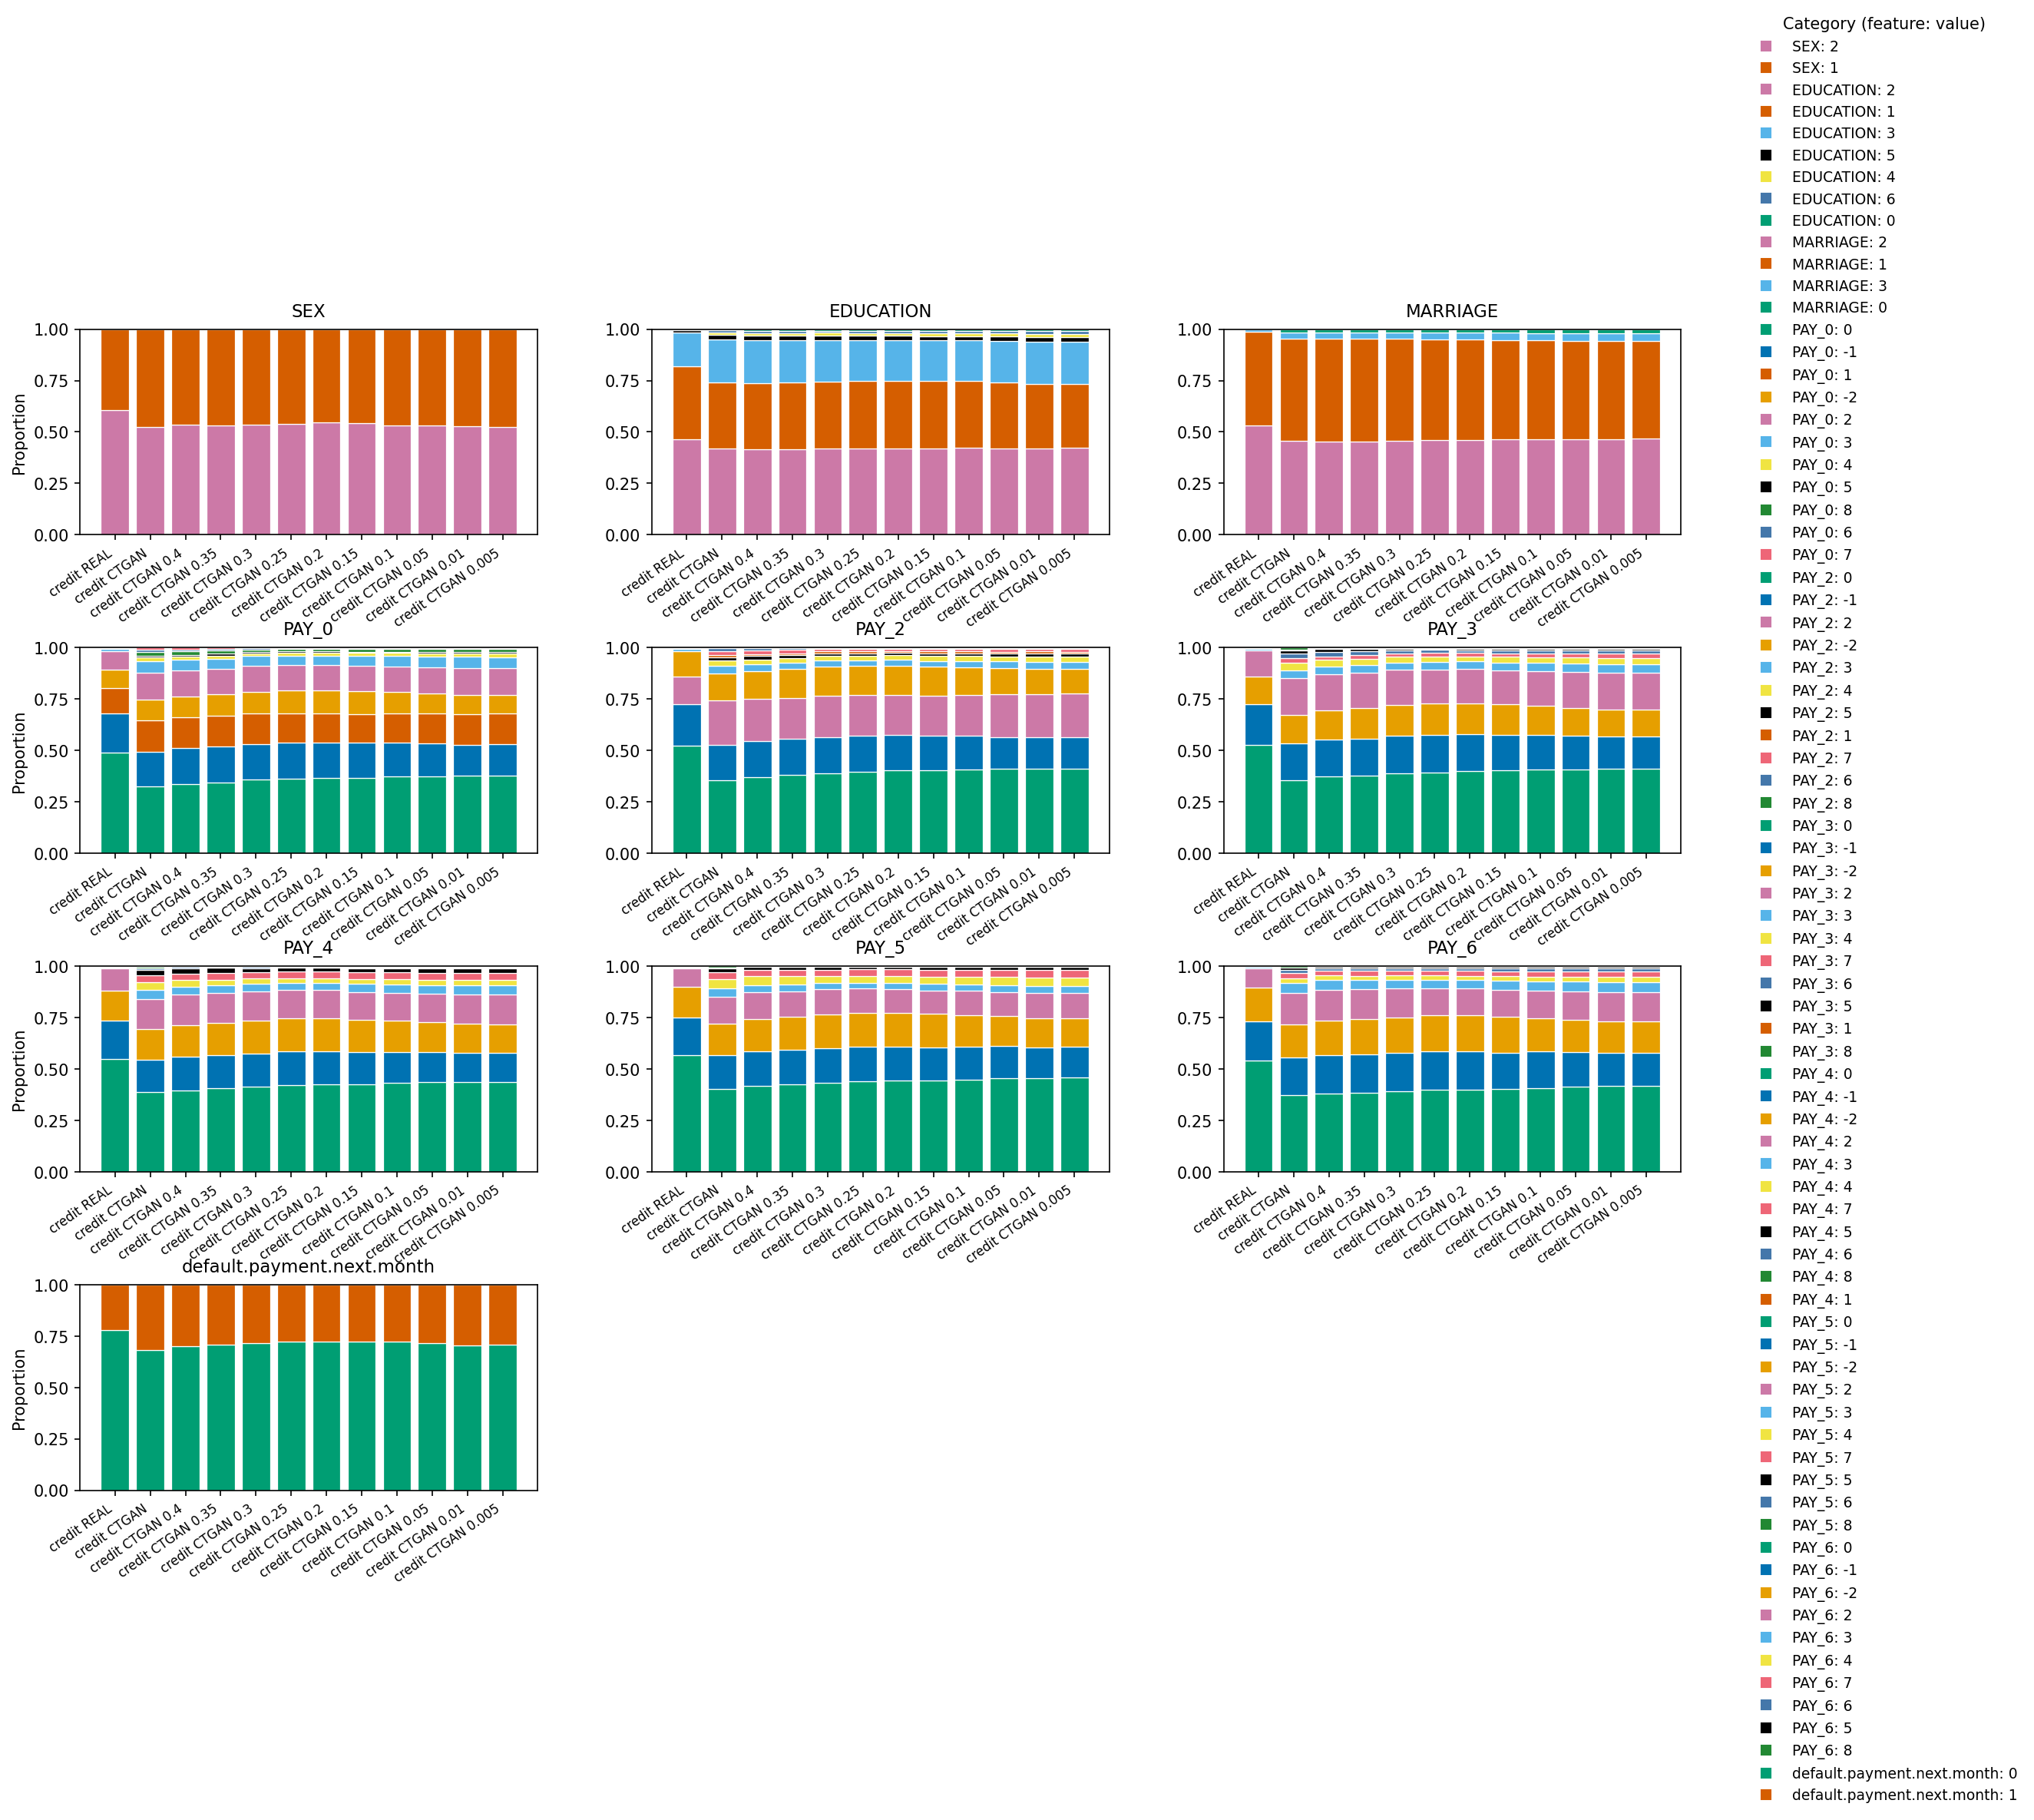

In [27]:
synth = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']
synth_to_plot = ['credit CTGAN','credit CTGAN 0.01', 'credit CTGAN 0.3']

datasets = {}
datasets['credit REAL'] = df_real_credit_card_train

for key, value in dict_results_credit_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']

fig_cat = plot_categorical_stacks_grid(
    datasets=datasets,
    cat_features=cat_list_credit_card,
    baseline='credit REAL',                 # defaults to first *REAL*
    max_categories_to_plot=20,
    ncols=3,
    figsize=(20, 12),
    save_path=f"{EXTRA_DIR}/analysis_out_credit_ctgan/plots/categorical_stacks_grid.png",
)

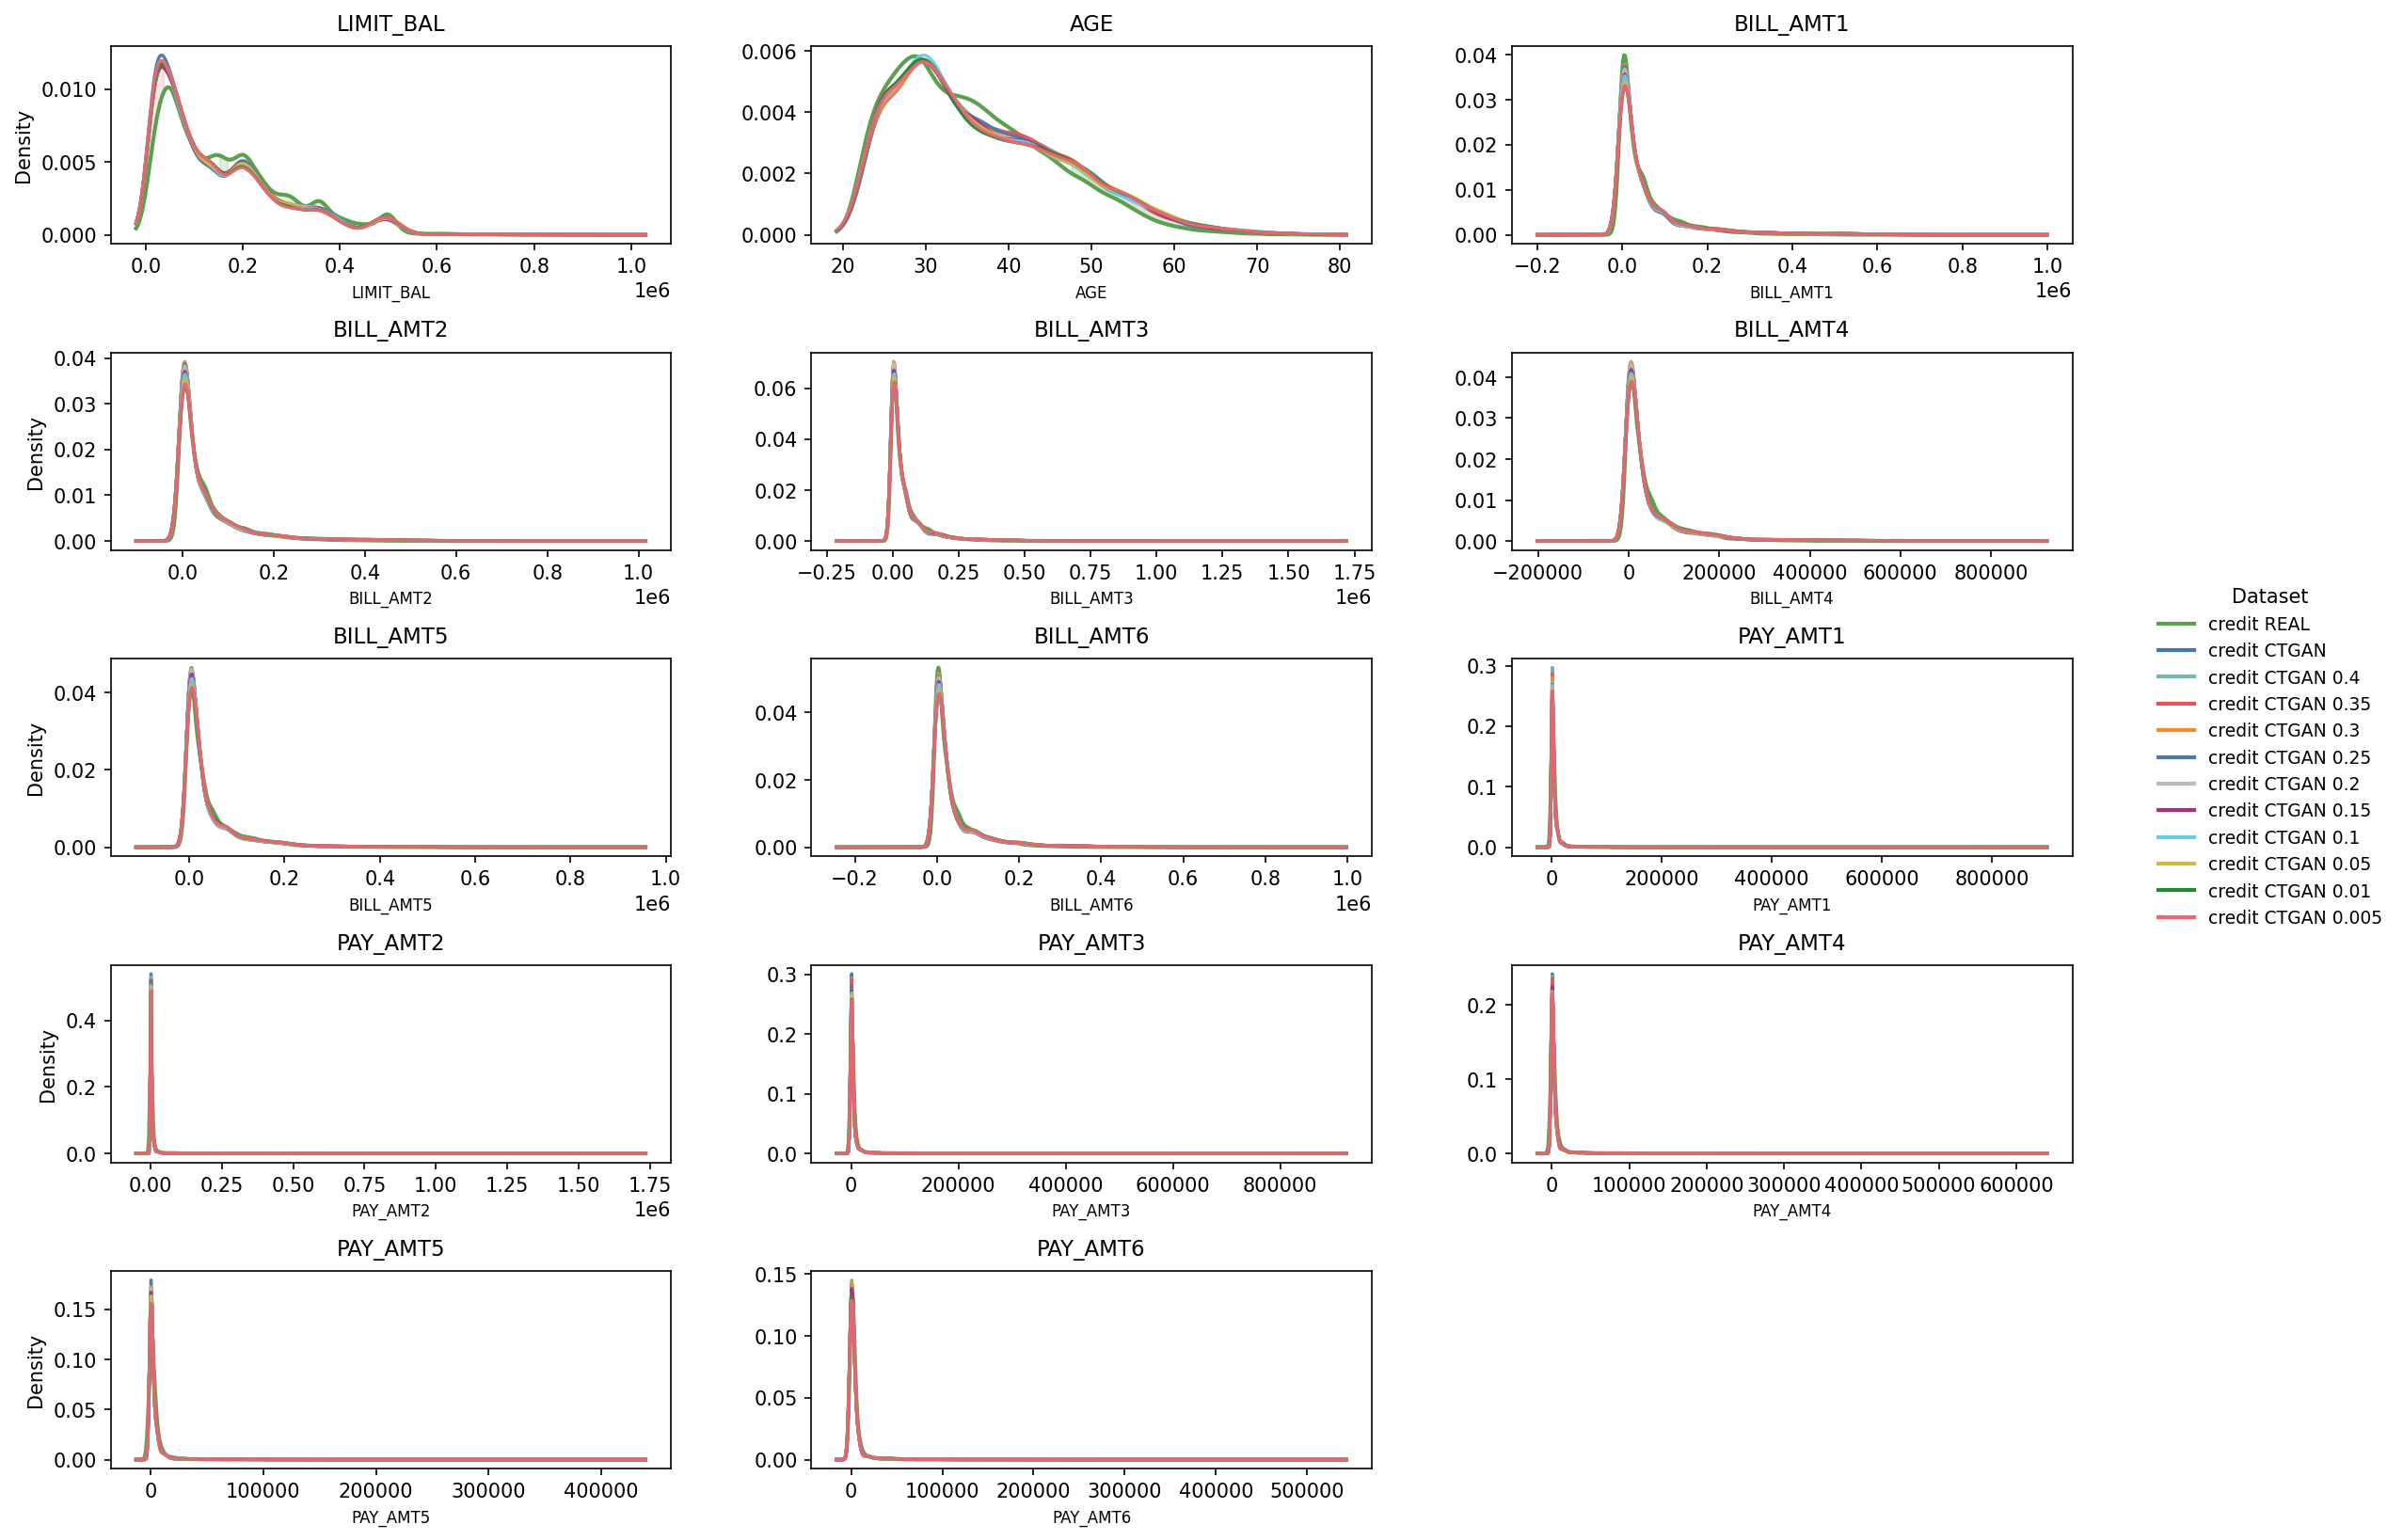

In [ ]:
synth = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']
synth_to_plot = ['credit CTGAN','credit CTGAN 0.01', 'credit CTGAN 0.3']

datasets = {}
datasets['credit REAL'] = df_real_credit_card_train

for key, value in dict_results_credit_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


# Numerical densities (all features in one figure)
fig_num = plot_numerical_densities_grid(
    datasets=datasets,
    num_features=num_list_credit_card,
    baseline='credit REAL',                 # defaults to first *REAL*
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,
    ncols=3,
    figsize=(20, 12),
    save_path=f"{EXTRA_DIR}/analysis_out_credit_ctgan/plots/numerical_densities_grid.png",
)

In [ ]:
synth = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']
# synth_to_plot = ['credit CTGAN','credit CTGAN 0.01', 'credit CTGAN 0.3']

datasets = {}
datasets['credit REAL'] = df_real_credit_card_train

for key, value in dict_results_credit_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']
p1, cat_table = categorical_log2fc_table(datasets, cat_list_credit_card, 'credit REAL', f"{EXTRA_DIR}/analysis_out_credit_ctgan", pseudocount=1e-6)
p2, num_table = numeric_heuristic_table(datasets, num_list_credit_card, 'credit REAL', f"{EXTRA_DIR}/analysis_out_credit_ctgan", tail_q=(0.05, 0.95))

In [32]:
import pandas as pd

cat_table = pd.read_csv("./analysis_out_credit_ctgan/categorical_log2fc_table.csv")
feature = "PAY_0"
datasets = [key for key in dict_results_credit_ctgan_heom_any]  # order by ε (high→low)

# 1) Diverging bars of log2FC (one figure per ε)
plot_log2fc_diverging(cat_table, feature, dataset_order=datasets,
                      min_baseline_p=0.005, top_k=20, save_dir="./analysis_out_credit_ctgan/plots")

# 2) Heatmap of log2FC across ε
plot_log2fc_heatmap(cat_table, feature, dataset_order=datasets, top_k=30,
                    order_by="baseline", save_path="./analysis_out_credit_ctgan/plots/log2fc_heatmap_PAY_0.png")

# 3) Stacked composition of JS (fraction of JS per ε)
plot_js_contrib_stack(cat_table, feature, dataset_order=datasets, top_k=10, normalize=True,
                      save_path="./analysis_out_credit_ctgan/plots/jscontrib_stack_PAY_0.png")

# 4) Lollipop of JS contributions for the tightest ε
plot_js_contrib_lollipop(cat_table, feature, dataset='credit CTGAN 0.01', top_k=15,
                         save_path="./analysis_out_credit_ctgan/plots/jscontrib_lollipop_PAY_0_eps001.png")

# 5) Cumulative JS for the tightest ε
plot_js_cumulative(cat_table, feature, dataset='credit CTGAN 0.01',
                   save_path="./analysis_out_credit_ctgan/plots/jscontrib_cumulative_PAY_0_eps001.png")


In [33]:
import pandas as pd

cat_table = pd.read_csv("./analysis_out_credit_ctgan/categorical_log2fc_table.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_credit_ctgan_heom_any]  # order by ε (high→low)

for feature in cat_list_credit_card :
    # 2) Heatmap of log2FC across ε
    plot_log2fc_heatmap(cat_table, feature, dataset_order=datasets, top_k=30,
                        order_by="baseline", save_path=f"./analysis_out_credit_ctgan/plots/log2fc_heatmap_{feature}.png")

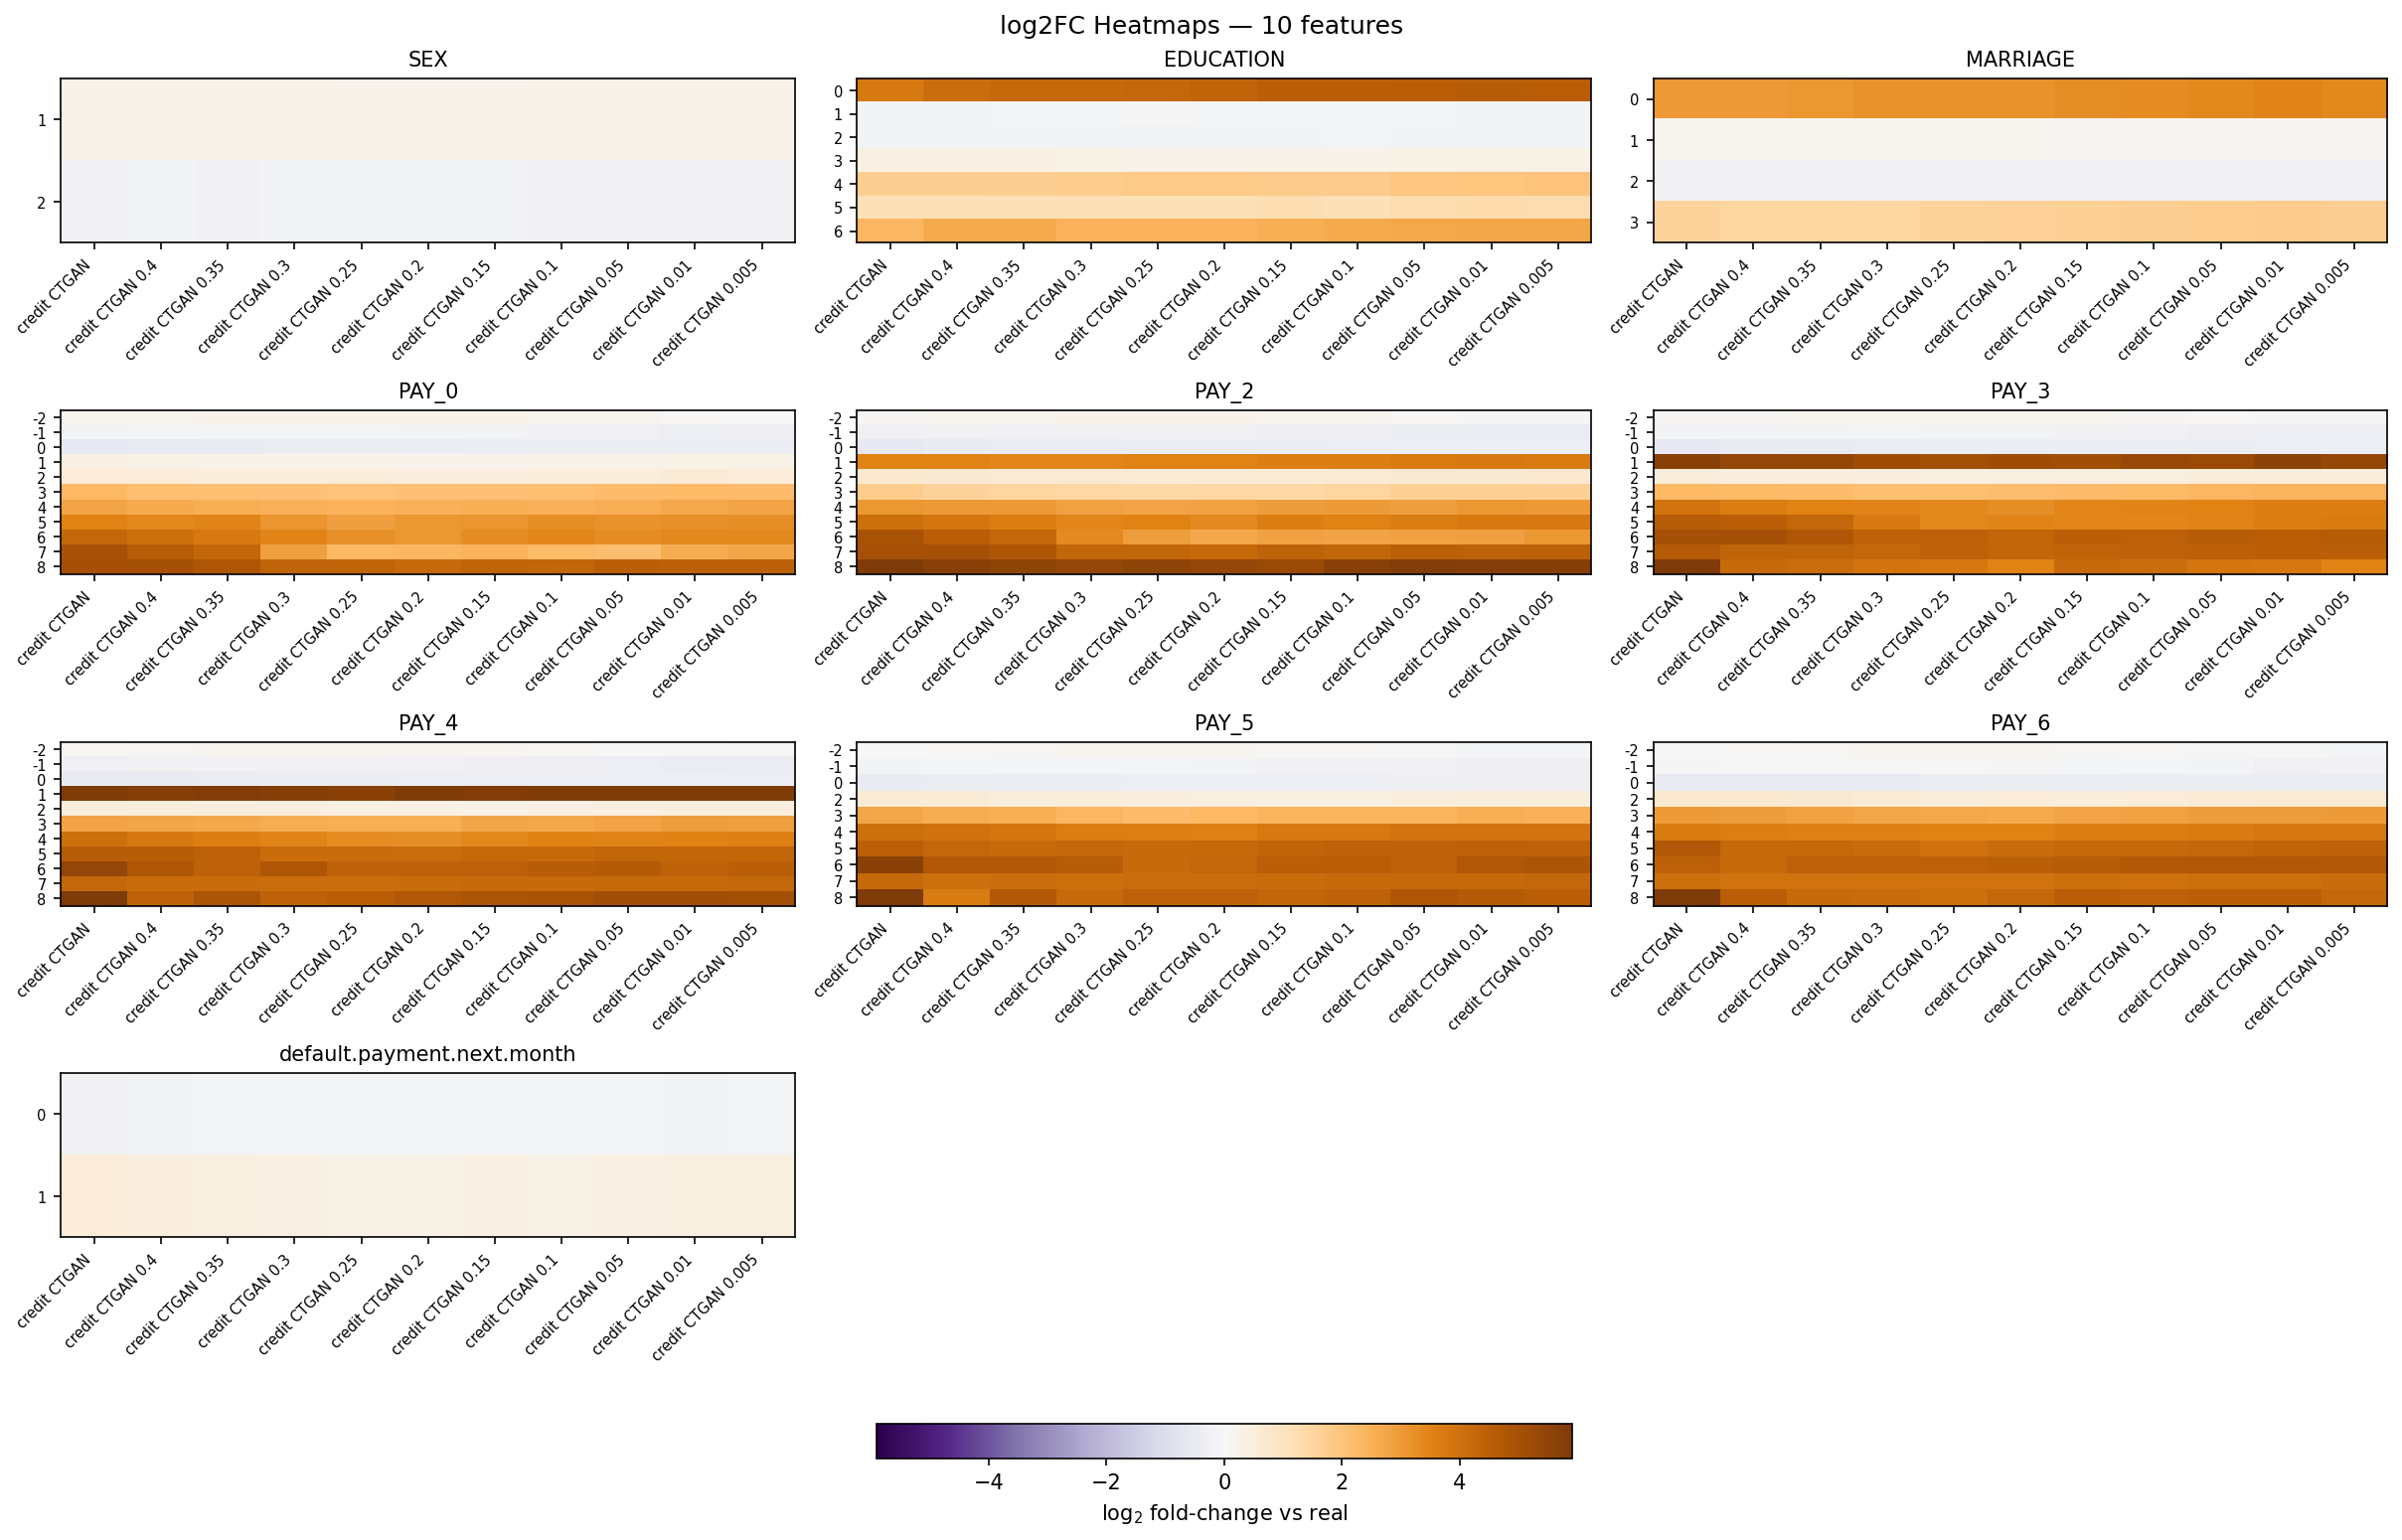

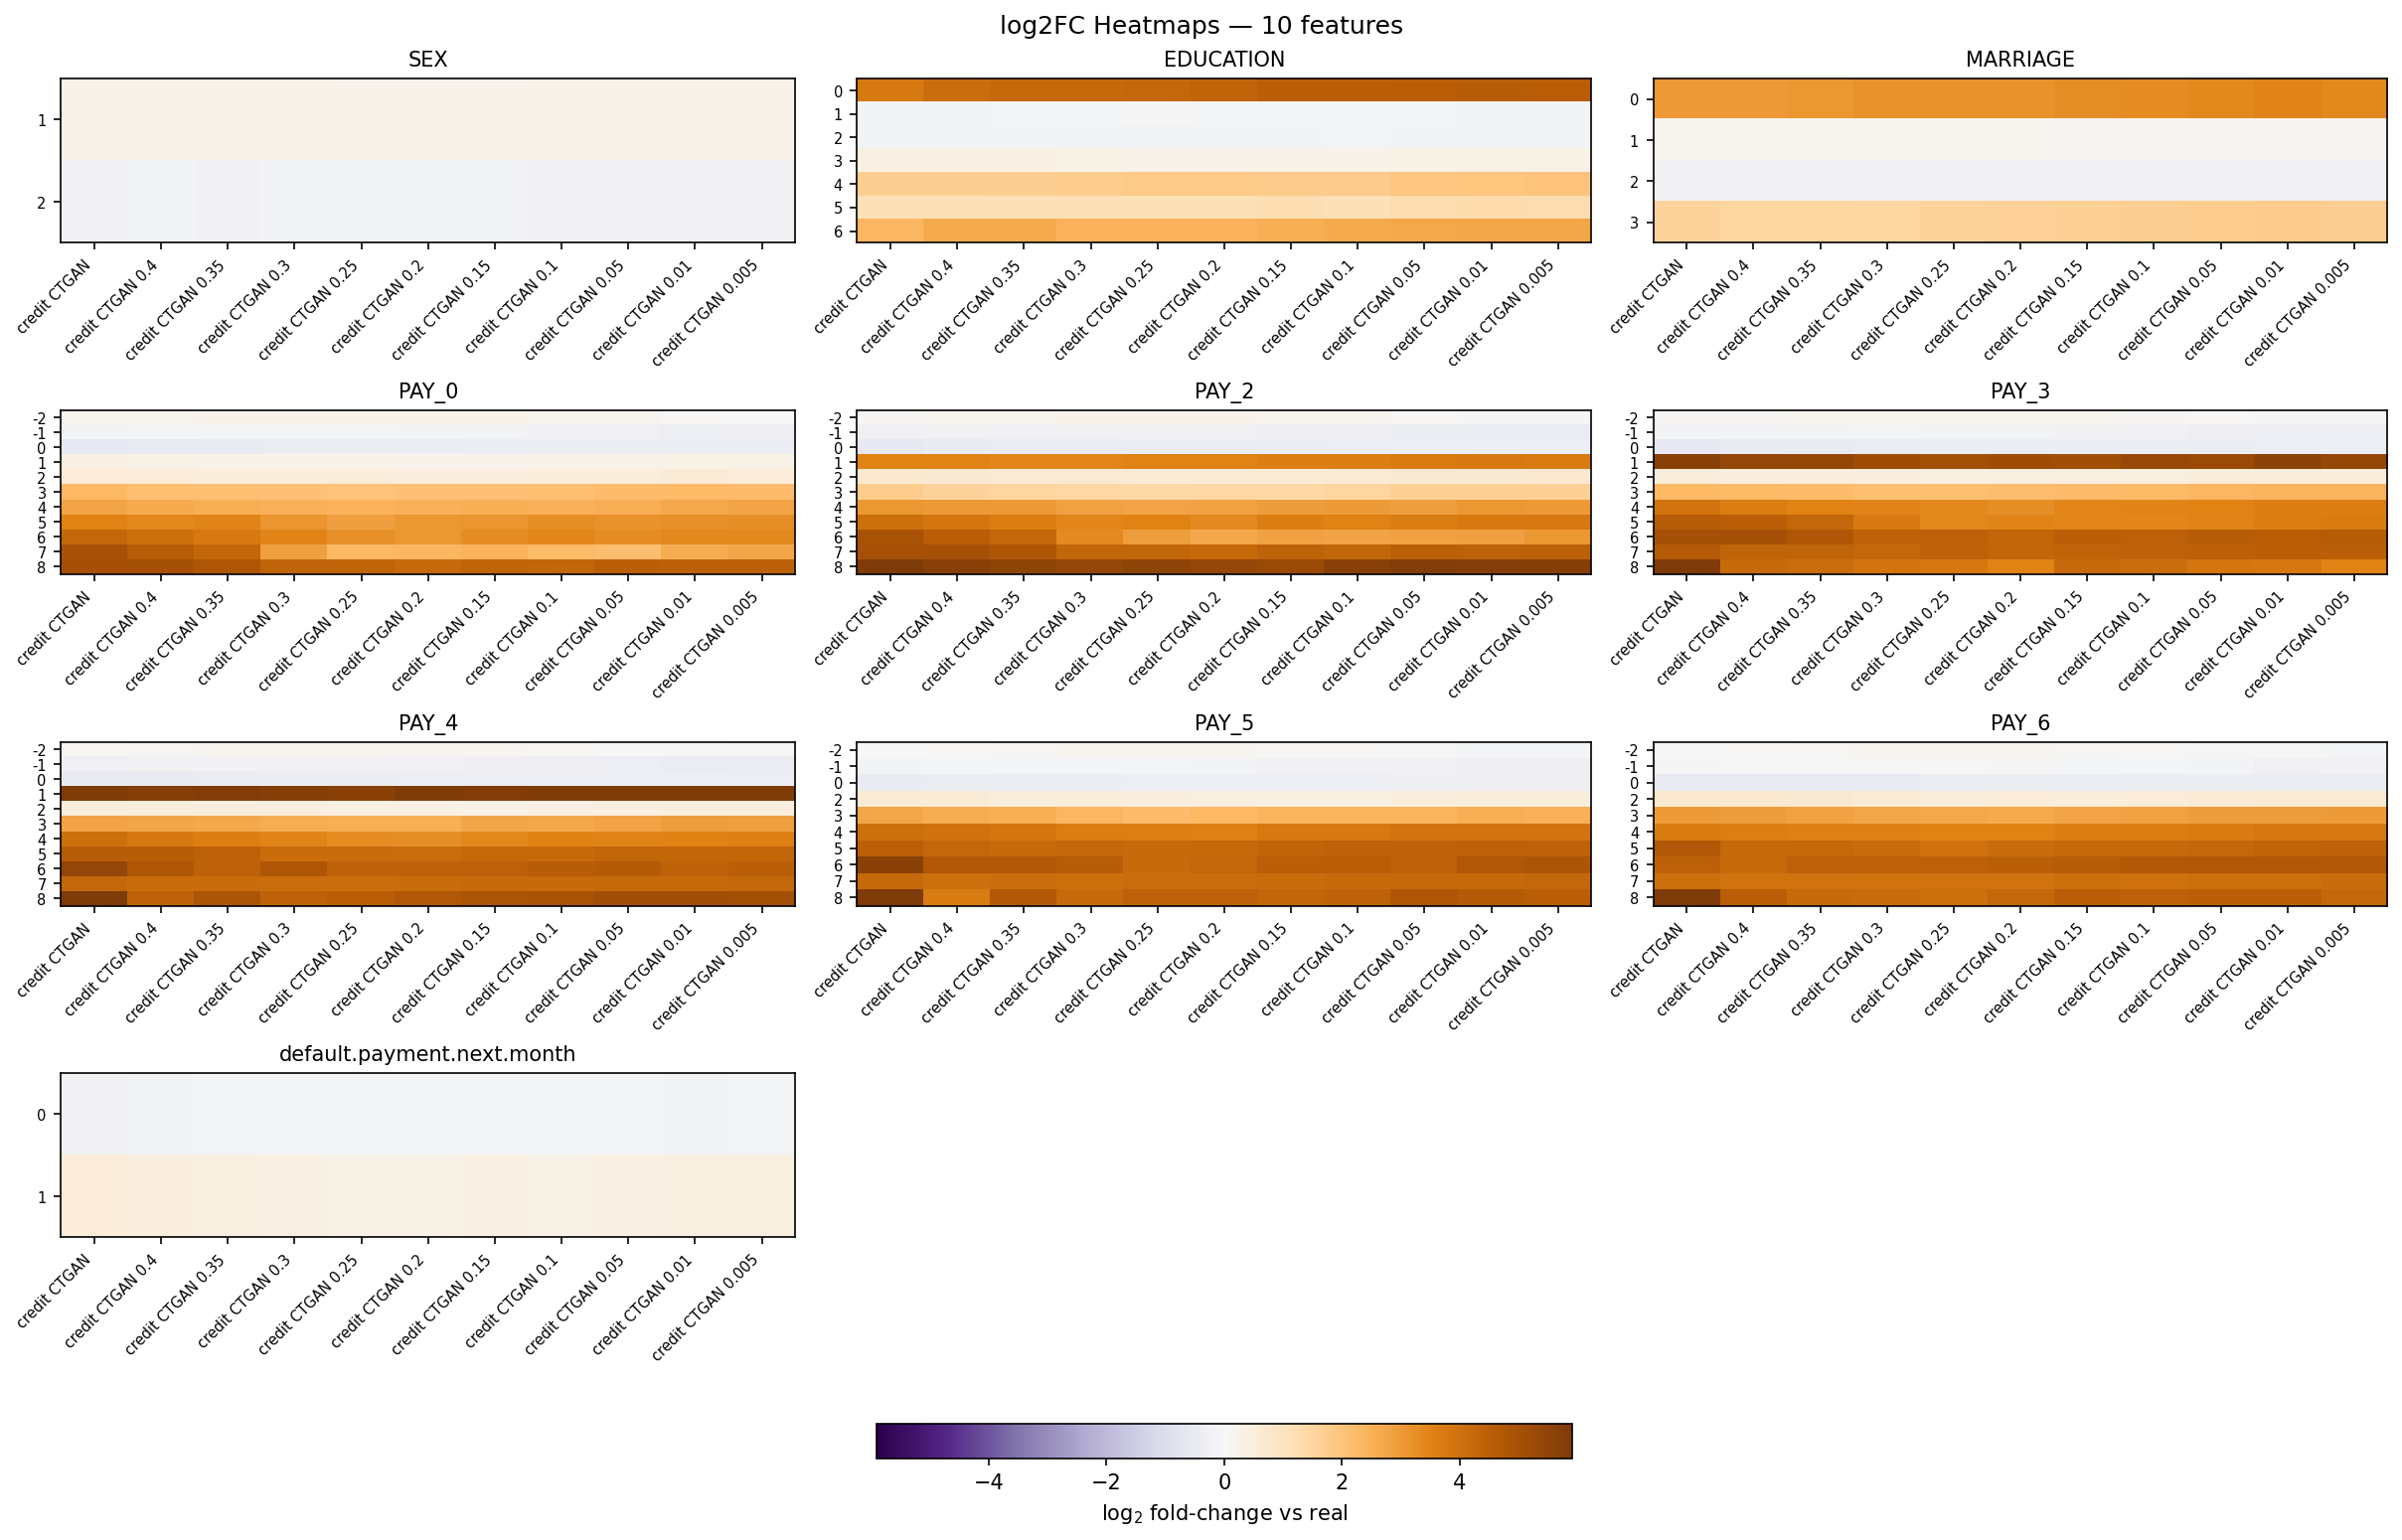

In [33]:
import pandas as pd

cat_table = pd.read_csv("./analysis_out_credit_ctgan/categorical_log2fc_table.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_credit_ctgan_heom_any]  # order by ε (high→low)

plot_log2fc_heatmaps_grid(
    cat_table,
    features=cat_list_credit_card,
    dataset_order=datasets,
    top_k=30,
    order_by="baseline",
    ncols=3,
    figsize=(16, 10),
    save_path="./analysis_out_credit_ctgan/plots/log2fc_heatmap_grid.png",
)

In [37]:
synth = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']

synth = {}
synth['credit REAL'] = df_real_credit_card_train
# synth_to_plot = ['credit CTGAN 0.01', 'credit CTGAN 0.3']

for key, value in dict_results_credit_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    synth[key] = value['generation_results']['synthetic_data']

In [30]:
# Example: compare two CTGAN variants to REAL on a set of categorical columns
synths = {
    "credit CTGAN 0.3": synth['credit CTGAN 0.01'],
    "credit CTGAN 0.01": synth['credit CTGAN 0.3']
}
real_df = synth["credit REAL"]
contribs, summary = explain_js_by_mode(
    real_df=real_df,
    synth_dfs=synth,
    cat_cols=["PAY_0", "EDUCATION", "MARRIAGE"],  # or None to auto-infer
    include_na=False,
    top_k=5,
    min_prob=0.001
)

# Inspect which modes drive JS for PAY_0
summary[summary["feature"] == "PAY_0"]

# Or view the per-mode table (sorted by contribution) for PAY_0 and a dataset
contribs.query("feature=='PAY_0' and dataset=='credit CTGAN 0.3'")[
    ["category","real_prob","synth_prob","abs_diff","js_contrib","pct_of_js","direction","rank"]
].head(10)


,category,real_prob,synth_prob,abs_diff,js_contrib,pct_of_js,direction,rank
187,3,0.011417,0.048375,0.036958,0.008866,27.516308,over,1
188,0,0.490958,0.358500,0.132458,0.007480,23.214793,under,2
189,8,0.000625,0.012667,0.012042,0.004827,14.982350,over,3
190,4,0.002500,0.014083,0.011583,0.003219,9.991786,over,4
191,2,0.089083,0.124500,0.035417,0.002128,6.604356,over,5
192,5,0.000708,0.006167,0.005458,0.001793,5.563312,over,6
193,6,0.000458,0.005167,0.004708,0.001667,5.172857,over,7
194,1,0.121542,0.146875,0.025333,0.000864,2.680380,over,8
195,7,0.000333,0.002458,0.002125,0.000659,2.046278,over,9
196,-2,0.091875,0.107458,0.015583,0.000440,1.365082,over,10


In [26]:
print(summary['top_modes'][4])

3: 27.5% (over by +0.037); 0: 23.2% (under by -0.132); 8: 15.0% (over by +0.012); 4: 10.0% (over by +0.012); 2: 6.6% (over by +0.035)


In [27]:
print(summary['top_modes'][5])

3: 31.5% (over by +0.044); 0: 15.2% (under by -0.114); 8: 14.9% (over by +0.013); 4: 11.6% (over by +0.014); 2: 8.5% (over by +0.043)


In [ ]:
from data_evaluator.univariate_evaluator import UnivariateEvaluator


synth = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']

eval = ResemblanceReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit_ctgan_heom_any)
eval.get_categorical_univariate_report()

In [ ]:
eval.get_numerical_univariate_report()

In [12]:
resemblance_evaluation = {}

for key in dict_results_credit_ctgan_heom_any :
    resemblance_evaluation[key] = dict_results_credit_ctgan_heom_any[key]['resemblance_evaluation_results']

In [ ]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any

synth = dict_results_credit_ctgan_heom_any['credit CTGAN']['generation_results']['synthetic_data']
df_real_credit_card_train = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card)

resemblance_report = ResemblanceReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit_ctgan_heom_any)
resemblance_report.get_categorical_univariate_report()
# synth = DataLoader.align_categoricals(synth, df_real_credit_card_train, cat_list_credit_card)
# # get_epsilon_heom_any(df_real_cardio_train, synth, num_list_cardio, cat_list_cardio)
# get_epsilon_heom_any(df_real_credit_card_train, synth, num_list_credit_card, cat_list_credit_card)

In [49]:

epsilon = [ 'credit CTGAN : baseline',
            'credit CTGAN eps = 0.4',
            'credit CTGAN eps = 0.35',
            'credit CTGAN eps = 0.3',
            'credit CTGAN eps = 0.25',
            'credit CTGAN eps = 0.2',
            'credit CTGAN eps = 0.15',
            'credit CTGAN eps = 0.1',
            'credit CTGAN eps = 0.05',
            'credit CTGAN eps = 0.01',
            'credit CTGAN eps = 0.005']
dict_results = dict_results_credit_ctgan_heom_any
get_mean_univariate_evaluation_markdown(dict_results_credit_ctgan_heom_any, epsilon)
print_js_cohen(dict_results_credit_ctgan_heom_any, epsilon)
# print_js_cohen_summarize(dict_results_credit_ctgan_heom_any, epsilon)




|                                |   credit CTGAN : baseline |   credit CTGAN eps = 0.4 |   credit CTGAN eps = 0.35 |   credit CTGAN eps = 0.3 |   credit CTGAN eps = 0.25 |   credit CTGAN eps = 0.2 |   credit CTGAN eps = 0.15 |   credit CTGAN eps = 0.1 |   credit CTGAN eps = 0.05 |   credit CTGAN eps = 0.01 |   credit CTGAN eps = 0.005 |
|:-------------------------------|--------------------------:|-------------------------:|--------------------------:|-------------------------:|--------------------------:|-------------------------:|--------------------------:|-------------------------:|--------------------------:|--------------------------:|---------------------------:|
| categorical JS divergence mean |                 0.185654  |                0.171719  |                 0.16546   |                0.155501  |                  0.150732 |                 0.149392 |                 0.154658  |                0.157116  |                 0.162425  |                 0.168097  |          

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_delta_vs_baseline(
        dict_measure: dict,
        epsilons: np.ndarray,
        metric_label: str,
        baseline_eps: float,
        title_suffix: str = "",
        *,
        include_features=None,
        highlight_features=None,
        feature_palette=None,
        legend_outside: bool = True,
        legend_cols: int = 1,
        # What to compute
        mode: str = "delta",        # "delta" => y(ε) - y(ε_baseline); "ratio" => y(ε)/y(ε_baseline) - 1
        # Visual polish
        thin_alpha: float = 0.25,
        thick_alpha: float = 0.95,
        thin_lw: float = 0.9,
        thick_lw: float = 1.6,
        mean_lw: float = 2.6,
        band_alpha: float = 0.14,
        # Annotations
        annotate_mean_min: bool = True,
        # Export
        savepath: str = None,
        dpi: int = 300
    ):
    """
    Δ-to-baseline plot for publication:
      - Per-feature curves are (metric(ε) - metric(baseline)) or relative ratio - 1
      - Baseline is implicitly 0 ⇒ plotted as a horizontal reference line
      - Mean Δ curve ± std across features
      - Highlights only selected features in legend; others are context
    """
    # ---- selection ----
    if include_features is not None:
        dict_measure = {k: v for k, v in dict_measure.items() if k in include_features}

    feats = list(dict_measure.keys())
    if not feats:
        raise ValueError("No features to plot.")

    if highlight_features is None:
        highlight_features = set()
    else:
        highlight_features = set(highlight_features)

    epsilons = np.asarray(epsilons)
    if np.any(np.isclose(epsilons, baseline_eps)):
        bidx = int(np.where(np.isclose(epsilons, baseline_eps))[0][0])
    else:
        bidx = int(np.argmin(np.abs(epsilons - baseline_eps)))

    # Build full matrix (K, E)
    vals = np.vstack([np.asarray(dict_measure[f]) for f in feats])
    K, E = vals.shape

    baseline_vec = vals[:, bidx]  # per-feature baseline metric

    # Convert to deltas or ratios
    if mode == "delta":
        mat = vals - baseline_vec[:, None]
        y_label = f"Δ {metric_label} vs baseline"
    elif mode == "ratio":
        # relative change, 0 = no change; guard small denominators
        denom = np.where(np.abs(baseline_vec) < 1e-12, np.sign(baseline_vec) * 1e-12, baseline_vec)
        mat = vals / denom[:, None] - 1.0
        y_label = f"relative change in {metric_label} (baseline=0)"
    else:
        raise ValueError("mode must be 'delta' or 'ratio'")

    # Exclude the baseline column from curves (keeps x compact); baseline is encoded as 0
    mask = np.ones(E, dtype=bool); mask[bidx] = False
    eps_plot = epsilons[mask]
    mat_plot = mat[:, mask]  # (K, E_eff)

    # Sort features by their baseline value (descending) so legend order is stable/meaningful
    order = np.argsort(-baseline_vec)
    feats     = [feats[i] for i in order]
    mat_plot  = mat_plot[order, :]
    baseline_vec = baseline_vec[order]

    # Colors
    default_cmap = cm.get_cmap("tab10", len(feats))
    def get_colour(i, feat):
        if feature_palette and feat in feature_palette:
            return feature_palette[feat]
        return default_cmap(i % default_cmap.N)

    # Mean ± std across features
    m_mean = mat_plot.mean(axis=0)
    m_std  = mat_plot.std(axis=0)

    # ---- plotting ----
    fig, ax = plt.subplots(figsize=(9, 5))

    # Zero reference (baseline)
    ax.axhline(0.0, color='black', lw=1.0, alpha=.5, linestyle='--', zorder=0)

    # Feature curves
    for i, feat in enumerate(feats):
        y = mat_plot[i]
        style = dict(
            lw=thick_lw if feat in highlight_features else thin_lw,
            alpha=thick_alpha if feat in highlight_features else thin_alpha,
            color=get_colour(i, feat),
            zorder=2 if feat in highlight_features else 1
        )
        ax.plot(eps_plot, y, label=feat if feat in highlight_features else None, **style)

    # Mean curve ± std
    ax.plot(eps_plot, m_mean, marker='o', lw=mean_lw, color='black',
            label=f"mean {y_label}", zorder=3)
    ax.fill_between(eps_plot, m_mean - m_std, m_mean + m_std,
                    alpha=band_alpha, color='black', zorder=2, label="± 1 std")

    # Annotate minimum (best improvement) of the mean curve
    if annotate_mean_min and len(eps_plot) > 0:
        j = int(np.argmin(m_mean))
        ax.plot([eps_plot[j]], [m_mean[j]], marker='o', ms=6, color='black', zorder=6)
        ax.annotate(
            f"min mean at ε={eps_plot[j]:g}\nΔ={m_mean[j]:+.3f}",
            xy=(eps_plot[j], m_mean[j]),
            xytext=(8, 10), textcoords="offset points",
            ha="left", va="bottom", fontsize="small",
            arrowprops=dict(arrowstyle='-', lw=0.8, color='black', shrinkA=2, shrinkB=2)
        )

    # Cosmetics
    ax.set_xlabel("privacy tolerance ε  (lower ⇒ tighter)")
    ax.set_ylabel(y_label)
    ax.set_title(f"{y_label} vs. ε {title_suffix}")
    ax.invert_xaxis()                   # keep your convention
    ax.grid(True, alpha=.3)

    # Legend
    if legend_outside:
        ax.legend(frameon=False, ncol=legend_cols,
                  bbox_to_anchor=(1.02, 1), loc="upper left",
                  borderaxespad=0., fontsize="small")
        plt.tight_layout(rect=[0, 0, 0.8, 1])
    else:
        ax.legend(frameon=False, fontsize="small")
        plt.tight_layout()

    # Y-range with modest headroom
    y_min, y_max = float(np.min(mat_plot)), float(np.max(mat_plot))
    margin = (y_max - y_min) * 0.08 if y_max > y_min else 0.02
    ax.set_ylim(y_min - margin, y_max + margin)

    if savepath:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")


/tmp/ipykernel_311307/1524250839.py:90: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



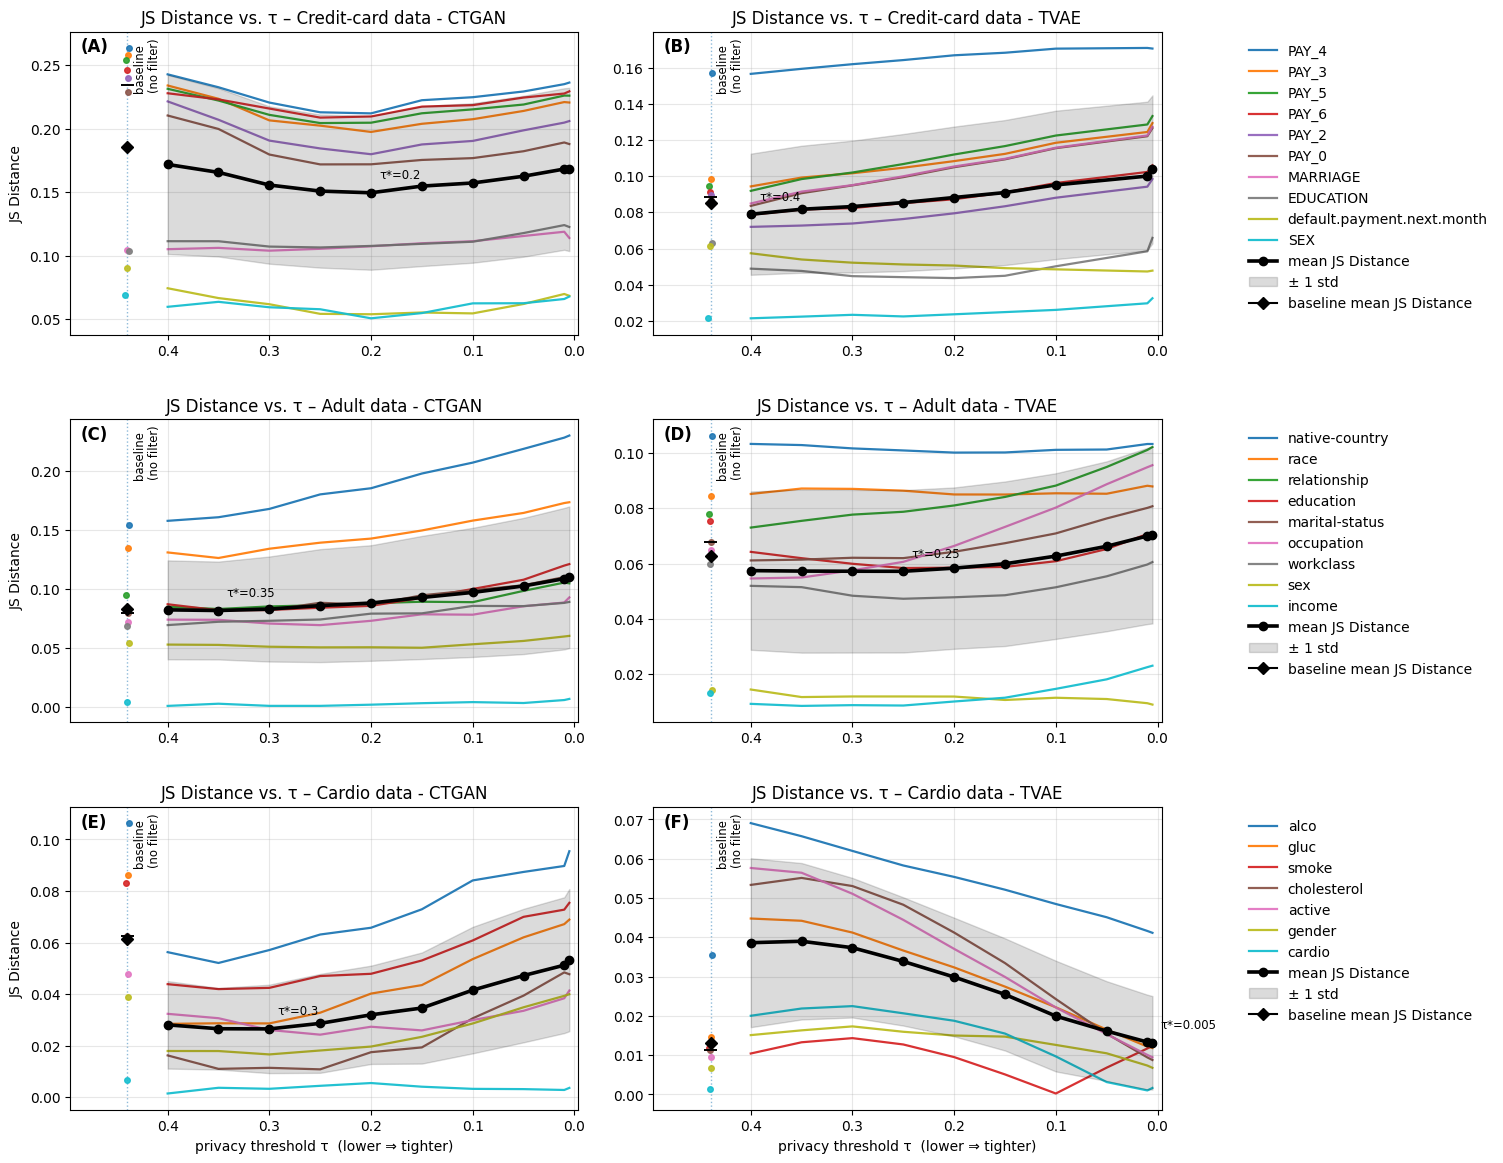

In [14]:
import matplotlib.pyplot as plt
import numpy as np


import string

def add_panel_labels(axes, *,
                     start="A",
                     fmt="({})",
                     x=0.02, y=0.98,
                     fontsize=12,
                     fontweight="bold",
                     va="top", ha="left",
                     use_axes_coords=True,
                     zorder=10):
    """
    Add (A)… labels to a list (or 2D array) of matplotlib Axes.
    Labels are placed inside each axis at (x,y) in axes-fraction coords by default.
    """
    # Flatten common containers (list of lists, np array)
    if hasattr(axes, "ravel"):
        axes_flat = list(axes.ravel())
    else:
        # assume list-like
        axes_flat = [a for row in axes for a in (row if isinstance(row, (list, tuple)) else [row])]

    letters = string.ascii_uppercase
    start_idx = letters.index(start.upper())
    for i, ax in enumerate(axes_flat):
        lab = fmt.format(letters[start_idx + i])
        coord = ax.transAxes if use_axes_coords else ax.transData
        ax.text(x, y, lab, transform=coord,
                fontsize=fontsize, fontweight=fontweight,
                va=va, ha=ha, zorder=zorder)



fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(
    nrows=3, ncols=3,
    width_ratios=[1.0, 1.0, 0.45],  # last column = legend gutter
    wspace=0.18, hspace=0.28
)



# plot axes
ax = {
    ("credit","CTGAN"): fig.add_subplot(gs[0, 0]),
    ("credit","TVAE"):  fig.add_subplot(gs[0, 1]),
    ("adult","CTGAN"):  fig.add_subplot(gs[1, 0]),
    ("adult","TVAE"):   fig.add_subplot(gs[1, 1]),
    ("cardio","CTGAN"): fig.add_subplot(gs[2, 0]),
    ("cardio","TVAE"):  fig.add_subplot(gs[2, 1]),
}

# legend axes (one per dataset row)
ax_leg = {
    "credit": fig.add_subplot(gs[0, 2]),
    "adult":  fig.add_subplot(gs[1, 2]),
    "cardio": fig.add_subplot(gs[2, 2]),
}
for a in ax_leg.values():
    a.axis("off")

# Your configs (same values you already use)
panels = {
    ("credit","CTGAN"): dict(
        params=np.array([0.43,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_credit_ctgan_heom_any,
        baseline=0.43,
        highlights=cat_list_credit_card,
        title="– Credit-card data - CTGAN",
    ),
    ("credit","TVAE"): dict(
        params=np.array([0.52,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.01,0.005]),
        results=dict_results_credit_tvae_heom_any,
        baseline=0.52,
        highlights=cat_list_credit_card,
        title="– Credit-card data - TVAE",
    ),

    ("adult","CTGAN"): dict(
        params=np.array([0.457,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_adult_ctgan_heom_any,
        baseline=0.457,
        highlights=cat_list_adult,
        title="– Adult data - CTGAN",
    ),
    ("adult","TVAE"): dict(
        params=np.array([0.56,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_adult_tvae_heom_any,
        baseline=0.56,
        highlights=cat_list_adult,
        title="– Adult data - TVAE",
    ),

    ("cardio","CTGAN"): dict(
        params=np.array([0.63,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_cardio_ctgan_heom_any,
        baseline=0.63,
        highlights=cat_list_cardio,
        title="– Cardio data - CTGAN",
    ),
    ("cardio","TVAE"): dict(
        params=np.array([0.65,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_cardio_tvae_heom_any,
        baseline=0.65,
        highlights=cat_list_cardio,
        title="– Cardio data - TVAE",
    ),
}

plot_axes_in_order = [
    ax[("credit","CTGAN")], ax[("credit","TVAE")],
    ax[("adult","CTGAN")],  ax[("adult","TVAE")],
    ax[("cardio","CTGAN")], ax[("cardio","TVAE")],
]

add_panel_labels(plot_axes_in_order, start="A", fmt="({})", x=0.02, y=0.98)
# Track whether we already created the legend for that dataset row
legend_done = {"credit": False, "adult": False, "cardio": False}

for (dataset, model), cfg in panels.items():
    dict_js_cat, dict_js_num, dict_cohen_num = get_plotable_measure(cfg["results"])
    params, dict_js_cat = sort_by_epsilon(dict_js_cat, cfg["params"])

    # only the first panel in each row provides legend entries (we then move it to the gutter)
    want_leg_entries = not legend_done[dataset]

    # plot_privacy_vs_quality_to_keep_1(
    #     dict_js_cat, params,
    #     metric_label="JS Divergence (categorical)",
    #     baseline_eps=cfg["baseline"],
    #     highlight_features=cfg["highlights"],
    #     title_suffix=cfg["title"],
    #     put_delta_in_title=False,
    #     ax=ax[(dataset, model)],
    #     legend_outside=False,   # keep legend off the plot; we'll place it in ax_leg
    #     show_legend=want_leg_entries
    # )

    plot_privacy_vs_quality_to_keep_1(
        dict_js_cat, params,
        metric_label="JS Distance",
        baseline_eps=cfg["baseline"],
        highlight_features=cfg["highlights"],
        title_suffix=cfg["title"],                # not used anymore
        put_delta_in_title=False,
        show_panel_title=True,          # NEW
        ax=ax[(dataset, model)],
        legend_outside=False,
        show_legend=want_leg_entries
    )

    # Reduce label repetition (optional)
    if model == "TVAE":
        ax[(dataset, model)].set_ylabel("")
    if dataset != "cardio":
        ax[(dataset, model)].set_xlabel("")

    # Create the row legend in the legend gutter
    if want_leg_entries:
        handles, labels = ax[(dataset, model)].get_legend_handles_labels()
        ax_leg[dataset].legend(
            handles, labels,
            loc="upper left",   # or "center left"
            frameon=False,
            fontsize="medium",
        )
        leg = ax[(dataset, model)].get_legend()
        if leg is not None:
            leg.remove()
        legend_done[dataset] = True

plt.show()


/tmp/ipykernel_2196105/1524250839.py:90: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



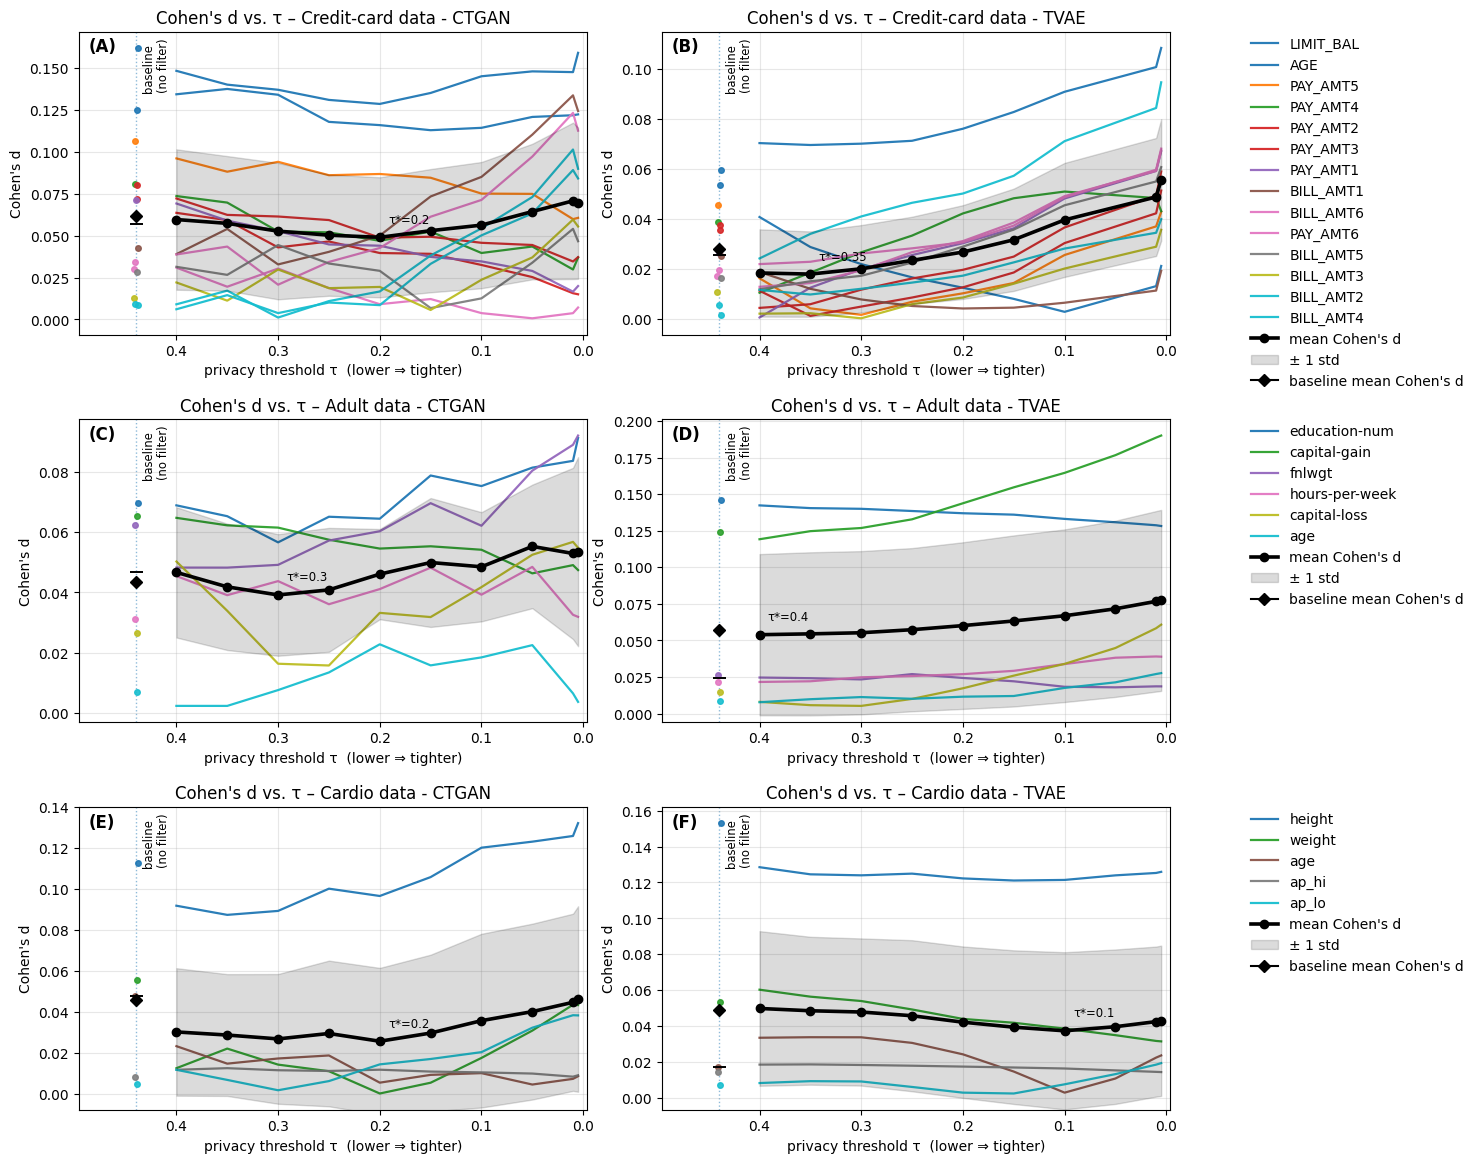

In [24]:
import matplotlib.pyplot as plt
import numpy as np


import string

def add_panel_labels(axes, *,
                     start="A",
                     fmt="({})",
                     x=0.02, y=0.98,
                     fontsize=12,
                     fontweight="bold",
                     va="top", ha="left",
                     use_axes_coords=True,
                     zorder=10):
    """
    Add (A)… labels to a list (or 2D array) of matplotlib Axes.
    Labels are placed inside each axis at (x,y) in axes-fraction coords by default.
    """
    # Flatten common containers (list of lists, np array)
    if hasattr(axes, "ravel"):
        axes_flat = list(axes.ravel())
    else:
        # assume list-like
        axes_flat = [a for row in axes for a in (row if isinstance(row, (list, tuple)) else [row])]

    letters = string.ascii_uppercase
    start_idx = letters.index(start.upper())
    for i, ax in enumerate(axes_flat):
        lab = fmt.format(letters[start_idx + i])
        coord = ax.transAxes if use_axes_coords else ax.transData
        ax.text(x, y, lab, transform=coord,
                fontsize=fontsize, fontweight=fontweight,
                va=va, ha=ha, zorder=zorder)



fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(
    nrows=3, ncols=3,
    width_ratios=[1.0, 1.0, 0.45],  # last column = legend gutter
    wspace=0.18, hspace=0.28
)



# plot axes
ax = {
    ("credit","CTGAN"): fig.add_subplot(gs[0, 0]),
    ("credit","TVAE"):  fig.add_subplot(gs[0, 1]),
    ("adult","CTGAN"):  fig.add_subplot(gs[1, 0]),
    ("adult","TVAE"):   fig.add_subplot(gs[1, 1]),
    ("cardio","CTGAN"): fig.add_subplot(gs[2, 0]),
    ("cardio","TVAE"):  fig.add_subplot(gs[2, 1]),
}

# legend axes (one per dataset row)
ax_leg = {
    "credit": fig.add_subplot(gs[0, 2]),
    "adult":  fig.add_subplot(gs[1, 2]),
    "cardio": fig.add_subplot(gs[2, 2]),
}
for a in ax_leg.values():
    a.axis("off")

# Your configs (same values you already use)
panels = {
    ("credit","CTGAN"): dict(
        params=np.array([0.43,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_credit_ctgan_heom_any,
        baseline=0.43,
        highlights=num_list_credit_card,
        title="– Credit-card data - CTGAN",
    ),
    ("credit","TVAE"): dict(
        params=np.array([0.52,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.01,0.005]),
        results=dict_results_credit_tvae_heom_any,
        baseline=0.52,
        highlights=num_list_credit_card,
        title="– Credit-card data - TVAE",
    ),

    ("adult","CTGAN"): dict(
        params=np.array([0.457,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_adult_ctgan_heom_any,
        baseline=0.457,
        highlights=num_list_adult,
        title="– Adult data - CTGAN",
    ),
    ("adult","TVAE"): dict(
        params=np.array([0.56,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_adult_tvae_heom_any,
        baseline=0.56,
        highlights=num_list_adult,
        title="– Adult data - TVAE",
    ),

    ("cardio","CTGAN"): dict(
        params=np.array([0.63,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_cardio_ctgan_heom_any,
        baseline=0.63,
        highlights=num_list_cardio,
        title="– Cardio data - CTGAN",
    ),
    ("cardio","TVAE"): dict(
        params=np.array([0.65,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_cardio_tvae_heom_any,
        baseline=0.65,
        highlights=num_list_cardio,
        title="– Cardio data - TVAE",
    ),
}

plot_axes_in_order = [
    ax[("credit","CTGAN")], ax[("credit","TVAE")],
    ax[("adult","CTGAN")],  ax[("adult","TVAE")],
    ax[("cardio","CTGAN")], ax[("cardio","TVAE")],
]

legend_done = {"credit": False, "adult": False, "cardio": False}

for (dataset, model), cfg in panels.items():
    dict_js_cat, dict_js_num, dict_cohen_num = get_plotable_measure(cfg["results"])
    params, dict_cohen_num = sort_by_epsilon(dict_cohen_num, cfg["params"])

    want_leg_entries = not legend_done[dataset]

    plot_privacy_vs_quality_to_keep_1(
        dict_cohen_num, params,
        metric_label="Cohen's d",
        baseline_eps=cfg["baseline"],
        highlight_features=cfg["highlights"],
        title_suffix=cfg["title"],                # use row/col headers instead
        put_delta_in_title=False,
        show_panel_title=True,          # IMPORTANT
        #show_axis_labels=False,          # optional (use global supxlabel/supylabel)
        ax=ax[(dataset, model)],
        legend_outside=False,
        show_legend=want_leg_entries
    )

    if want_leg_entries:
        handles, labels = ax[(dataset, model)].get_legend_handles_labels()
        ax_leg[dataset].legend(
            handles, labels,
            loc="upper left",
            frameon=False,
            fontsize="medium",
            borderaxespad=0.0
        )
        leg = ax[(dataset, model)].get_legend()
        if leg is not None:
            leg.remove()
        legend_done[dataset] = True

# NOW add labels (after everything)
add_panel_labels(plot_axes_in_order, start="A", fmt="({})", x=0.02, y=0.98)

plt.show()


/tmp/ipykernel_2196105/1524250839.py:90: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



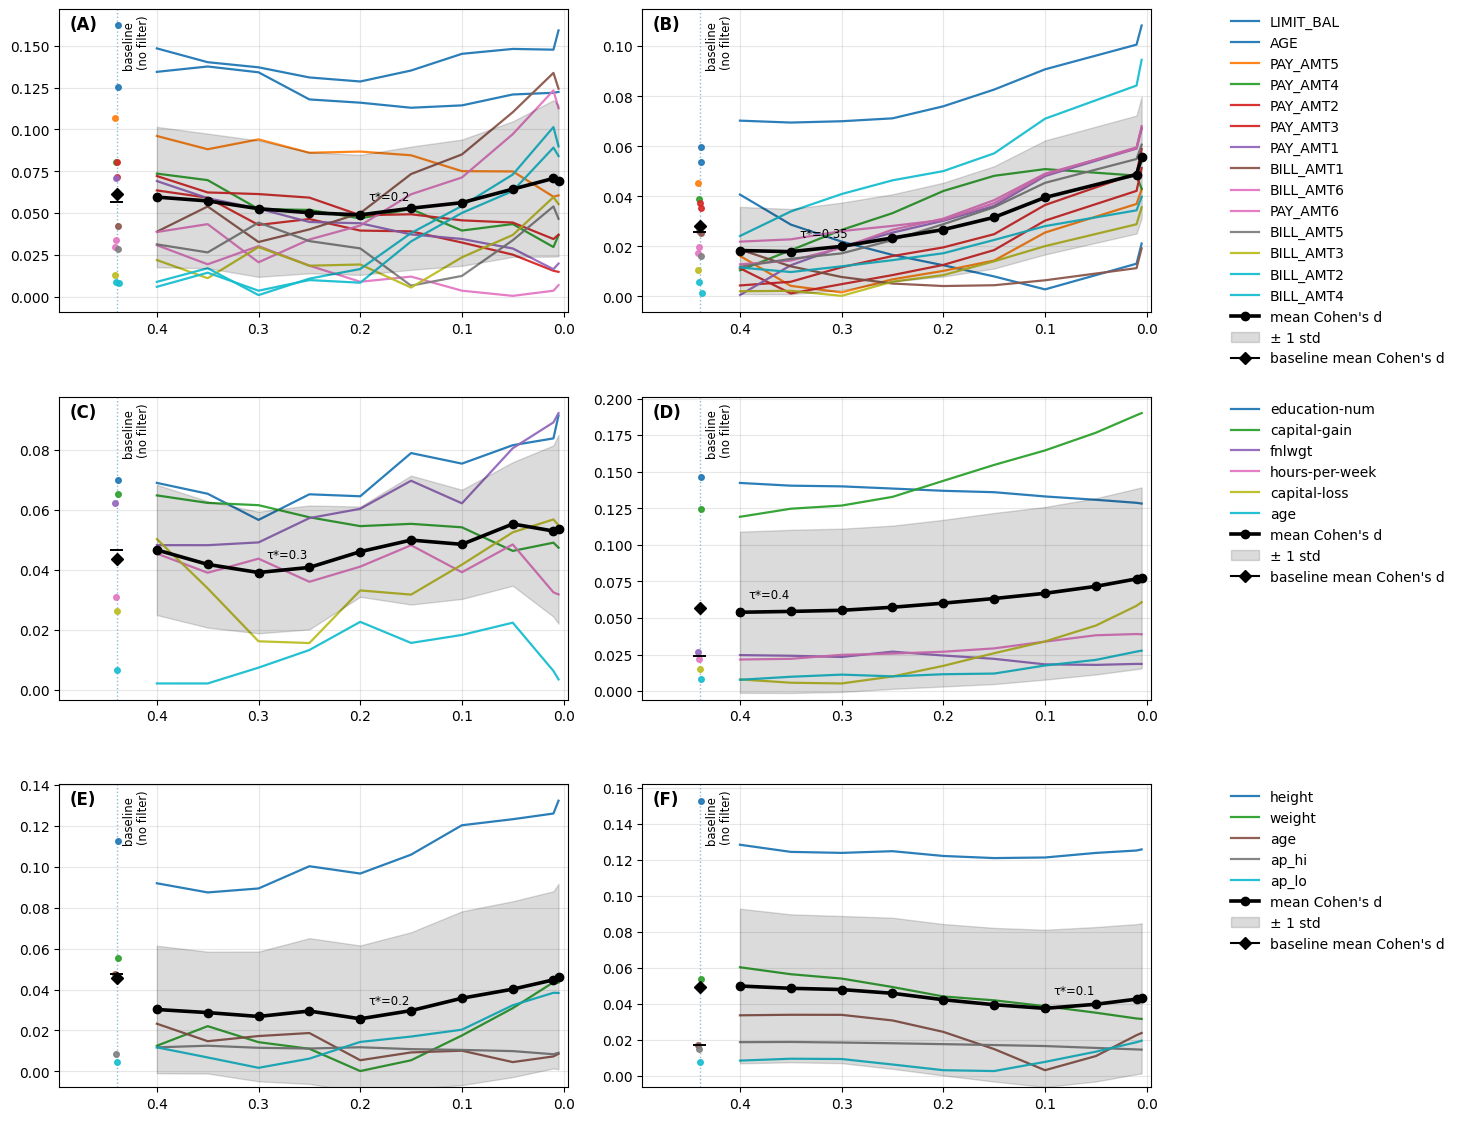

In [23]:
import matplotlib.pyplot as plt
import numpy as np


import string

def add_panel_labels(axes, *,
                     start="A",
                     fmt="({})",
                     x=0.02, y=0.98,
                     fontsize=12,
                     fontweight="bold",
                     va="top", ha="left",
                     use_axes_coords=True,
                     zorder=10):
    """
    Add (A)… labels to a list (or 2D array) of matplotlib Axes.
    Labels are placed inside each axis at (x,y) in axes-fraction coords by default.
    """
    # Flatten common containers (list of lists, np array)
    if hasattr(axes, "ravel"):
        axes_flat = list(axes.ravel())
    else:
        # assume list-like
        axes_flat = [a for row in axes for a in (row if isinstance(row, (list, tuple)) else [row])]

    letters = string.ascii_uppercase
    start_idx = letters.index(start.upper())
    for i, ax in enumerate(axes_flat):
        lab = fmt.format(letters[start_idx + i])
        coord = ax.transAxes if use_axes_coords else ax.transData
        ax.text(x, y, lab, transform=coord,
                fontsize=fontsize, fontweight=fontweight,
                va=va, ha=ha, zorder=zorder)



fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(
    nrows=3, ncols=3,
    width_ratios=[1.0, 1.0, 0.45],  # last column = legend gutter
    wspace=0.18, hspace=0.28
)



# plot axes
ax = {
    ("credit","CTGAN"): fig.add_subplot(gs[0, 0]),
    ("credit","TVAE"):  fig.add_subplot(gs[0, 1]),
    ("adult","CTGAN"):  fig.add_subplot(gs[1, 0]),
    ("adult","TVAE"):   fig.add_subplot(gs[1, 1]),
    ("cardio","CTGAN"): fig.add_subplot(gs[2, 0]),
    ("cardio","TVAE"):  fig.add_subplot(gs[2, 1]),
}

# legend axes (one per dataset row)
ax_leg = {
    "credit": fig.add_subplot(gs[0, 2]),
    "adult":  fig.add_subplot(gs[1, 2]),
    "cardio": fig.add_subplot(gs[2, 2]),
}
for a in ax_leg.values():
    a.axis("off")

# Your configs (same values you already use)
panels = {
    ("credit","CTGAN"): dict(
        params=np.array([0.43,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_credit_ctgan_heom_any,
        baseline=0.43,
        highlights=num_list_credit_card,
        title="– Credit-card data - CTGAN",
    ),
    ("credit","TVAE"): dict(
        params=np.array([0.52,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.01,0.005]),
        results=dict_results_credit_tvae_heom_any,
        baseline=0.52,
        highlights=num_list_credit_card,
        title="– Credit-card data - TVAE",
    ),

    ("adult","CTGAN"): dict(
        params=np.array([0.457,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_adult_ctgan_heom_any,
        baseline=0.457,
        highlights=num_list_adult,
        title="– Adult data - CTGAN",
    ),
    ("adult","TVAE"): dict(
        params=np.array([0.56,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_adult_tvae_heom_any,
        baseline=0.56,
        highlights=num_list_adult,
        title="– Adult data - TVAE",
    ),

    ("cardio","CTGAN"): dict(
        params=np.array([0.63,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_cardio_ctgan_heom_any,
        baseline=0.63,
        highlights=num_list_cardio,
        title="– Cardio data - CTGAN",
    ),
    ("cardio","TVAE"): dict(
        params=np.array([0.65,0.4,0.35,0.3,0.25,0.2,0.15,0.1,0.05,0.01,0.005]),
        results=dict_results_cardio_tvae_heom_any,
        baseline=0.65,
        highlights=num_list_cardio,
        title="– Cardio data - TVAE",
    ),
}

plot_axes_in_order = [
    ax[("credit","CTGAN")], ax[("credit","TVAE")],
    ax[("adult","CTGAN")],  ax[("adult","TVAE")],
    ax[("cardio","CTGAN")], ax[("cardio","TVAE")],
]

legend_done = {"credit": False, "adult": False, "cardio": False}

for (dataset, model), cfg in panels.items():
    dict_js_cat, dict_js_num, dict_cohen_num = get_plotable_measure(cfg["results"])
    params, dict_cohen_num = sort_by_epsilon(dict_cohen_num, cfg["params"])

    want_leg_entries = not legend_done[dataset]

    plot_privacy_vs_quality_to_keep_1(
        dict_cohen_num, params,
        metric_label="Cohen's d",
        baseline_eps=cfg["baseline"],
        highlight_features=cfg["highlights"],
        title_suffix="",                 # use row/col headers instead
        put_delta_in_title=False,
        show_panel_title=False,          # IMPORTANT
        show_axis_labels=False,          # optional (use global supxlabel/supylabel)
        ax=ax[(dataset, model)],
        legend_outside=False,
        show_legend=want_leg_entries
    )

    if want_leg_entries:
        handles, labels = ax[(dataset, model)].get_legend_handles_labels()
        ax_leg[dataset].legend(
            handles, labels,
            loc="upper left",
            frameon=False,
            fontsize="medium",
            borderaxespad=0.0
        )
        leg = ax[(dataset, model)].get_legend()
        if leg is not None:
            leg.remove()
        legend_done[dataset] = True

# NOW add labels (after everything)
add_panel_labels(plot_axes_in_order, start="A", fmt="({})", x=0.02, y=0.98)

plt.show()


In [34]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_credit_tvae_heom_any['credit TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['credit TVAE','credit TVAE 0.01', 'credit TVAE 0.3']

datasets = {}
datasets['credit REAL'] = df_real_credit_card_train

for key, value in dict_results_credit_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_credit_card,
    num_features=num_list_credit_card,
    baseline='credit REAL',            # default: the highest ε becomes baseline
    out_dir="./analysis_out_credit_tvae", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])


Per-feature divergences: ./analysis_out_credit_tvae/divergence_table.csv
Ranking table: ./analysis_out_credit_tvae/ranking_table.csv
Plots: ./analysis_out_credit_tvae/plots


In [35]:
synth = dict_results_credit_tvae_heom_any['credit TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['credit CTGAN','credit CTGAN 0.01', 'credit CTGAN 0.3']

datasets = {}
datasets['credit REAL'] = df_real_credit_card_train

for key, value in dict_results_credit_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']
p1, cat_table = categorical_log2fc_table(datasets, cat_list_credit_card, 'credit REAL', "./analysis_out_credit_tvae", pseudocount=1e-6)
p2, num_table = numeric_heuristic_table(datasets, num_list_credit_card, 'credit REAL', "./analysis_out_credit_tvae", tail_q=(0.05, 0.95))

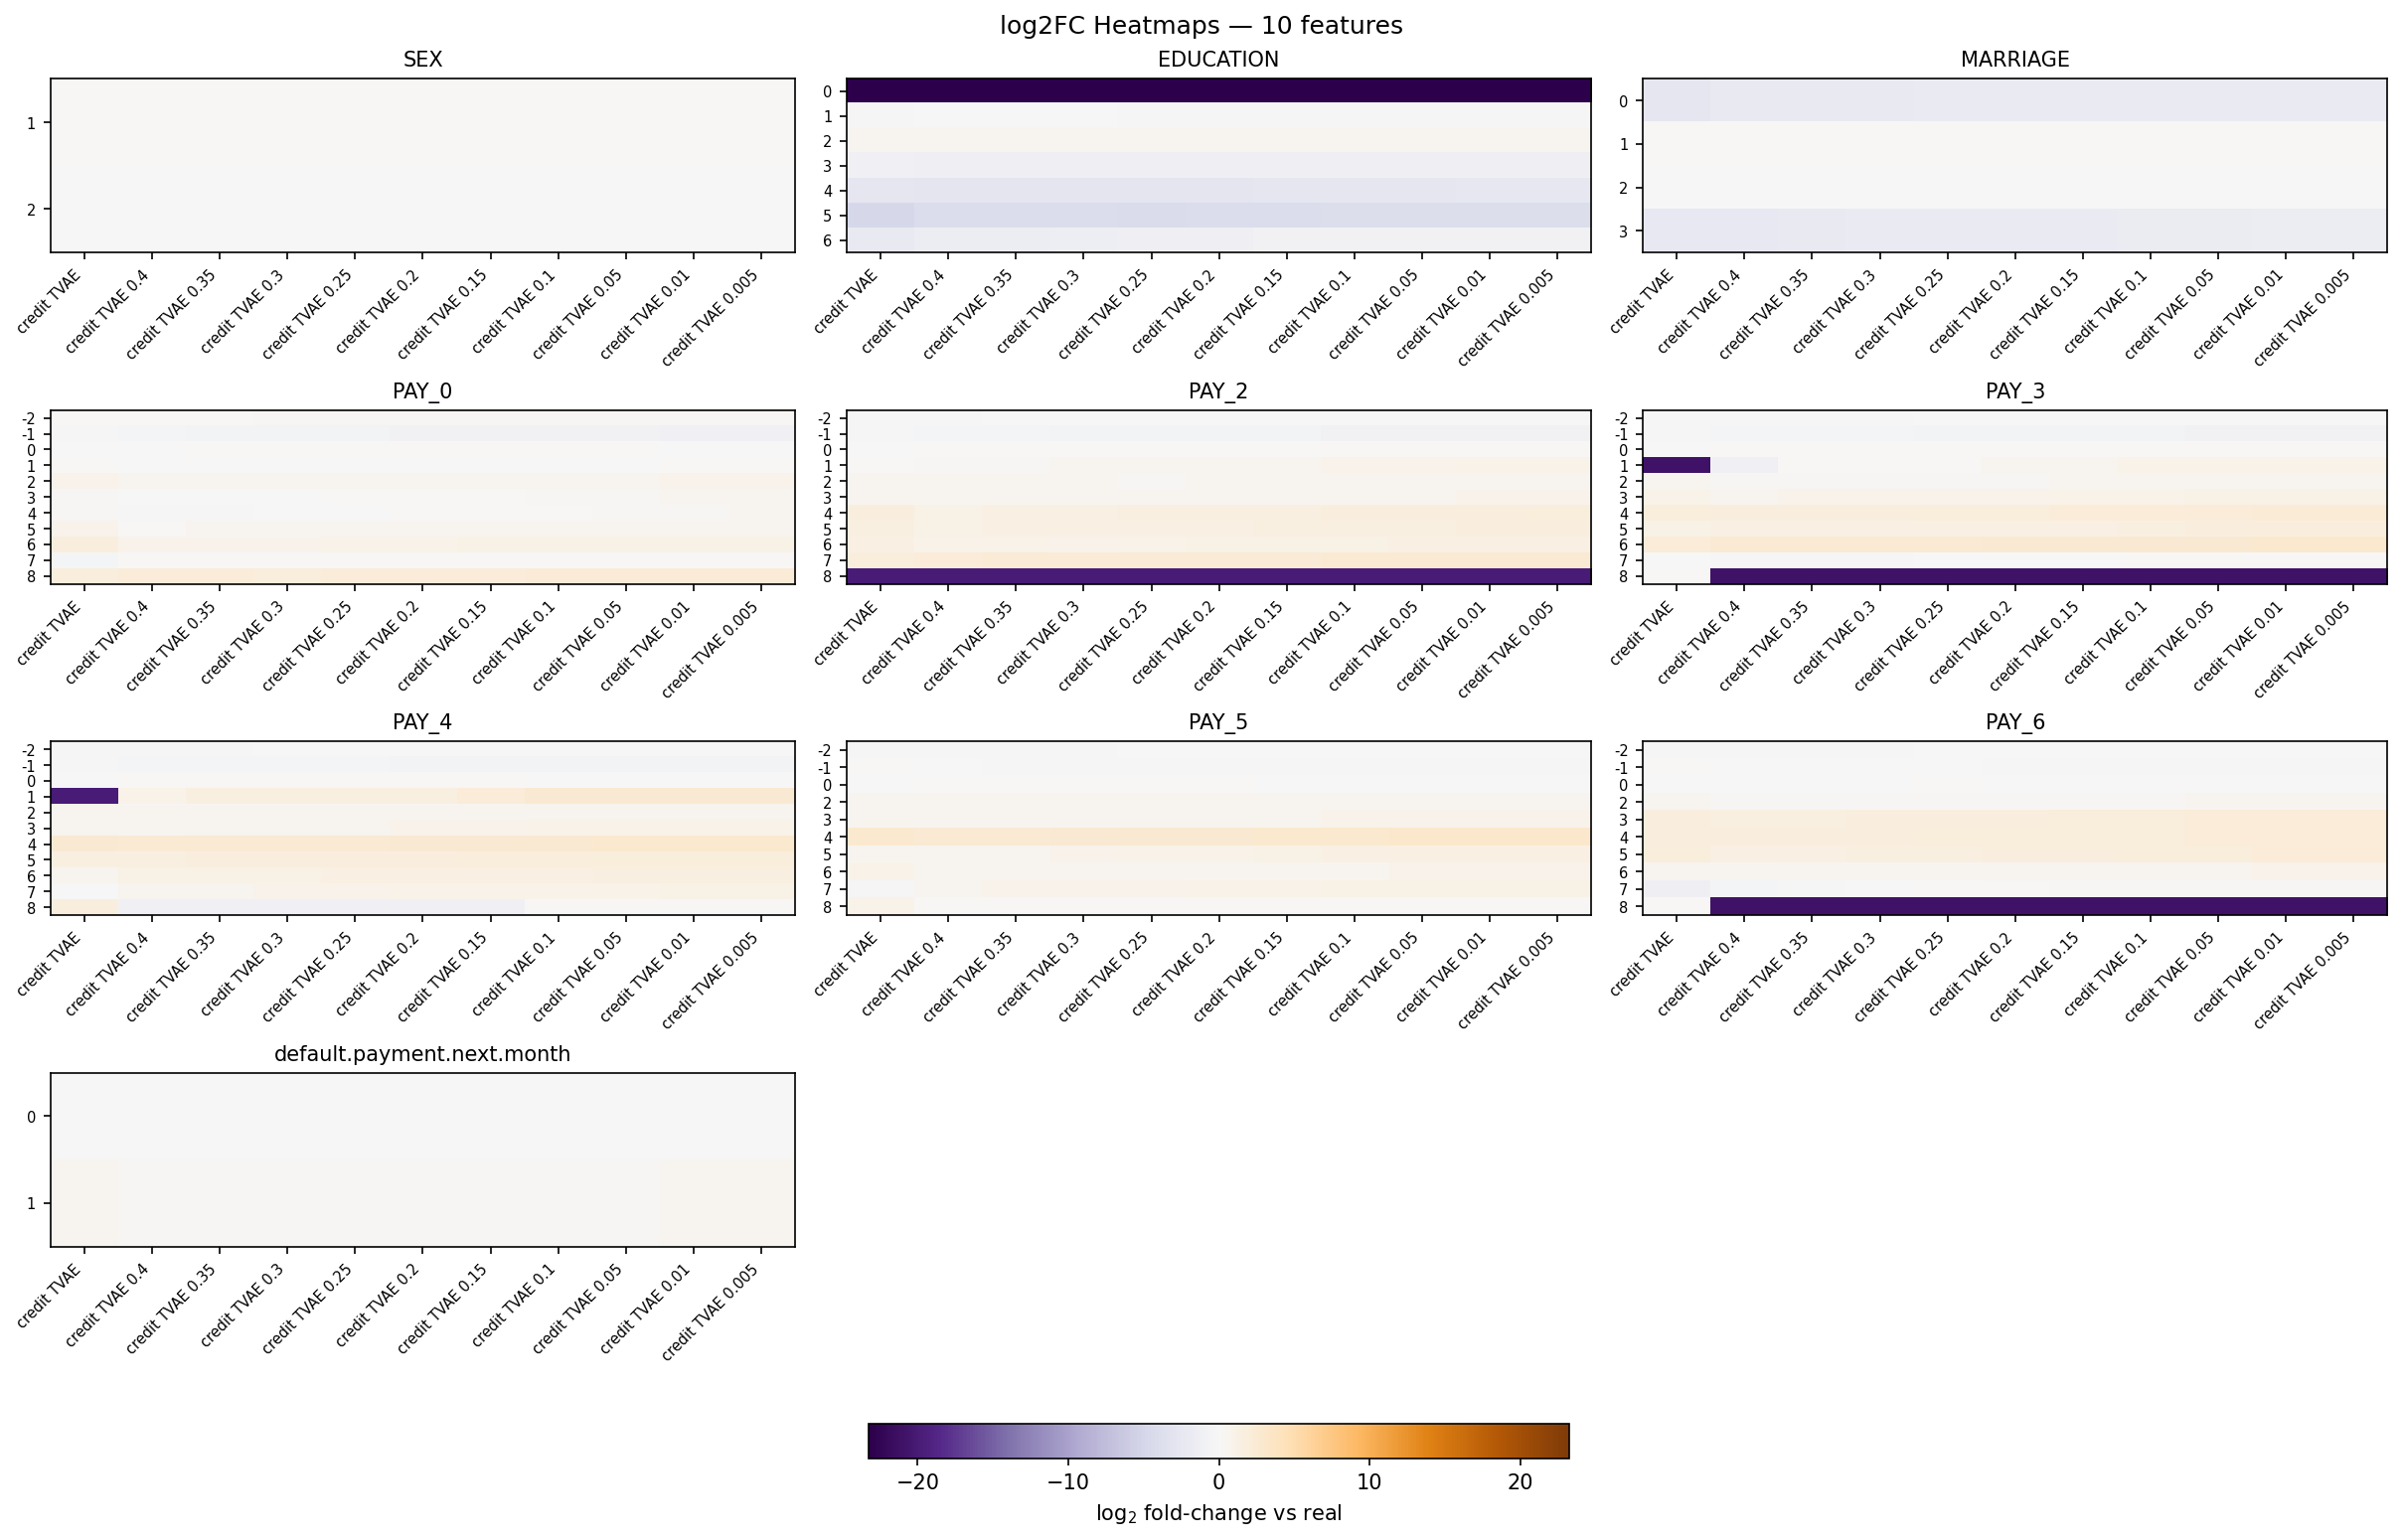

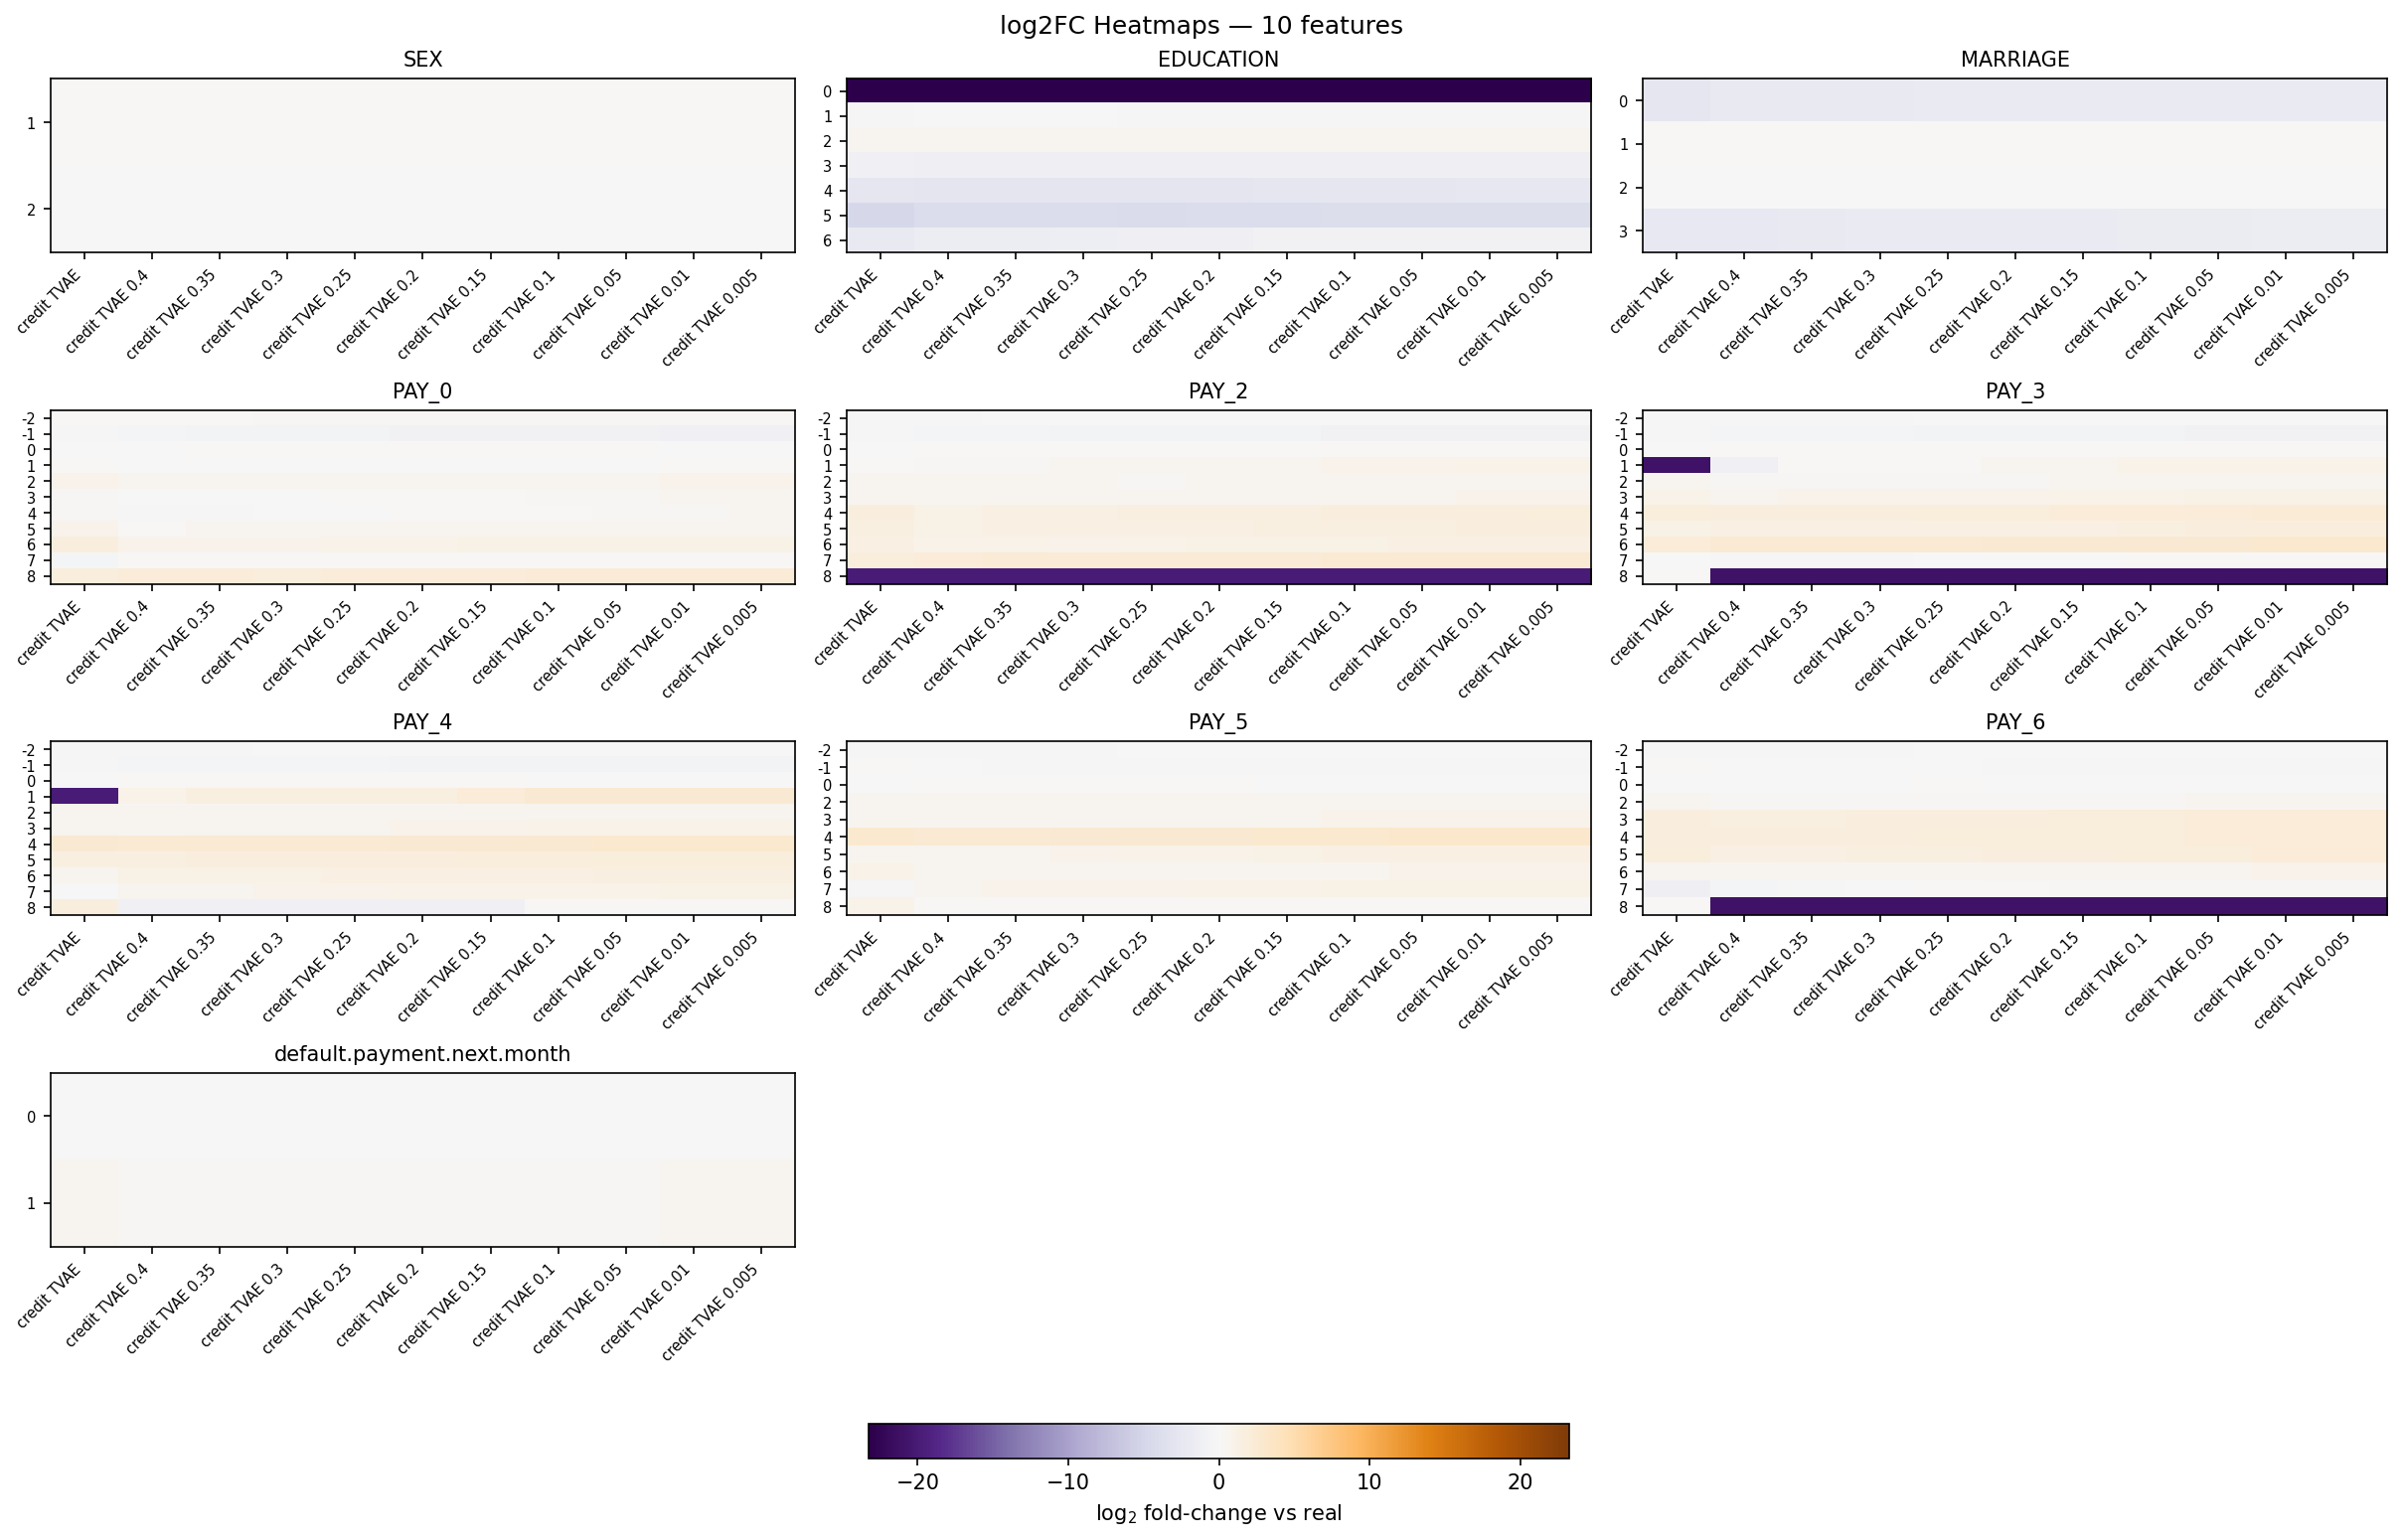

In [37]:
import pandas as pd

cat_table = pd.read_csv("./analysis_out_credit_tvae/categorical_log2fc_table_credit_tvae.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_credit_tvae_heom_any]  # order by ε (high→low)

plot_log2fc_heatmaps_grid(
    cat_table,
    features=cat_list_credit_card,
    dataset_order=datasets,
    top_k=30,
    order_by="baseline",
    ncols=3,
    figsize=(16, 10),
    save_path="./analysis_out_credit_tvae/plots/log2fc_heatmap_grid_credit_tvae.png",
)

In [27]:

epsilon = [ 'credit TVAE : baseline',
            'credit TVAE eps = 0.4',
            'credit TVAE eps = 0.35',
            'credit TVAE eps = 0.3',
            'credit TVAE eps = 0.25',
            'credit TVAE eps = 0.2',
            'credit TVAE eps = 0.15',
            'credit TVAE eps = 0.1',
            'credit TVAE eps = 0.05',
            'credit TVAE eps = 0.01',
            'credit TVAE eps = 0.005']
dict_results = dict_results_credit_ctgan_heom_any
get_mean_univariate_evaluation_markdown(dict_results_credit_tvae_heom_any, epsilon)
print_js_cohen(dict_results_credit_tvae_heom_any, epsilon)

|                                |   credit TVAE : baseline |   credit TVAE eps = 0.4 |   credit TVAE eps = 0.35 |   credit TVAE eps = 0.3 |   credit TVAE eps = 0.25 |   credit TVAE eps = 0.2 |   credit TVAE eps = 0.15 |   credit TVAE eps = 0.1 |   credit TVAE eps = 0.05 |   credit TVAE eps = 0.01 |   credit TVAE eps = 0.005 |
|:-------------------------------|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|-------------------------:|--------------------------:|
| categorical JS divergence mean |                0.0850169 |               0.0789653 |                0.0817347 |               0.0832127 |                0.0854345 |               0.0882226 |                0.0909597 |               0.0951874 |                0.100069  |                0.103783  |                 0.104293  |
| numerical c

In [69]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any

synth = dict_results_credit_tvae_heom_any['credit TVAE']['generation_results']['synthetic_data']
df_real_credit_card_train = DataLoader('../../data/credit_card_Train.csv').get_dataframe(cat_list_credit_card)

resemblance_report = ResemblanceReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit_tvae_heom_any)
resemblance_report.get_categorical_univariate_report()
# synth = DataLoader.align_categoricals(synth, df_real_credit_card_train, cat_list_credit_card)
# # get_epsilon_heom_any(df_real_cardio_train, synth, num_list_cardio, cat_list_cardio)
# get_epsilon_heom_any(df_real_credit_card_train, synth, num_list_credit_card, cat_list_credit_card)

### Adult

#### paper

In [38]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_adult_ctgan_heom_any['adult CTGAN']['generation_results']['synthetic_data']
synth_to_plot = ['adult CTGAN','adult CTGAN 0.01', 'adult CTGAN 0.3']

datasets = {}
datasets['adult REAL'] = df_real_adult_train

for key, value in dict_results_adult_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_adult,
    num_features=num_list_adult,
    baseline='adult REAL',            # default: the highest ε becomes baseline
    out_dir="./analysis_out_adult_ctgan", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])


Per-feature divergences: ./analysis_out_adult_ctgan/divergence_table.csv
Ranking table: ./analysis_out_adult_ctgan/ranking_table.csv
Plots: ./analysis_out_adult_ctgan/plots


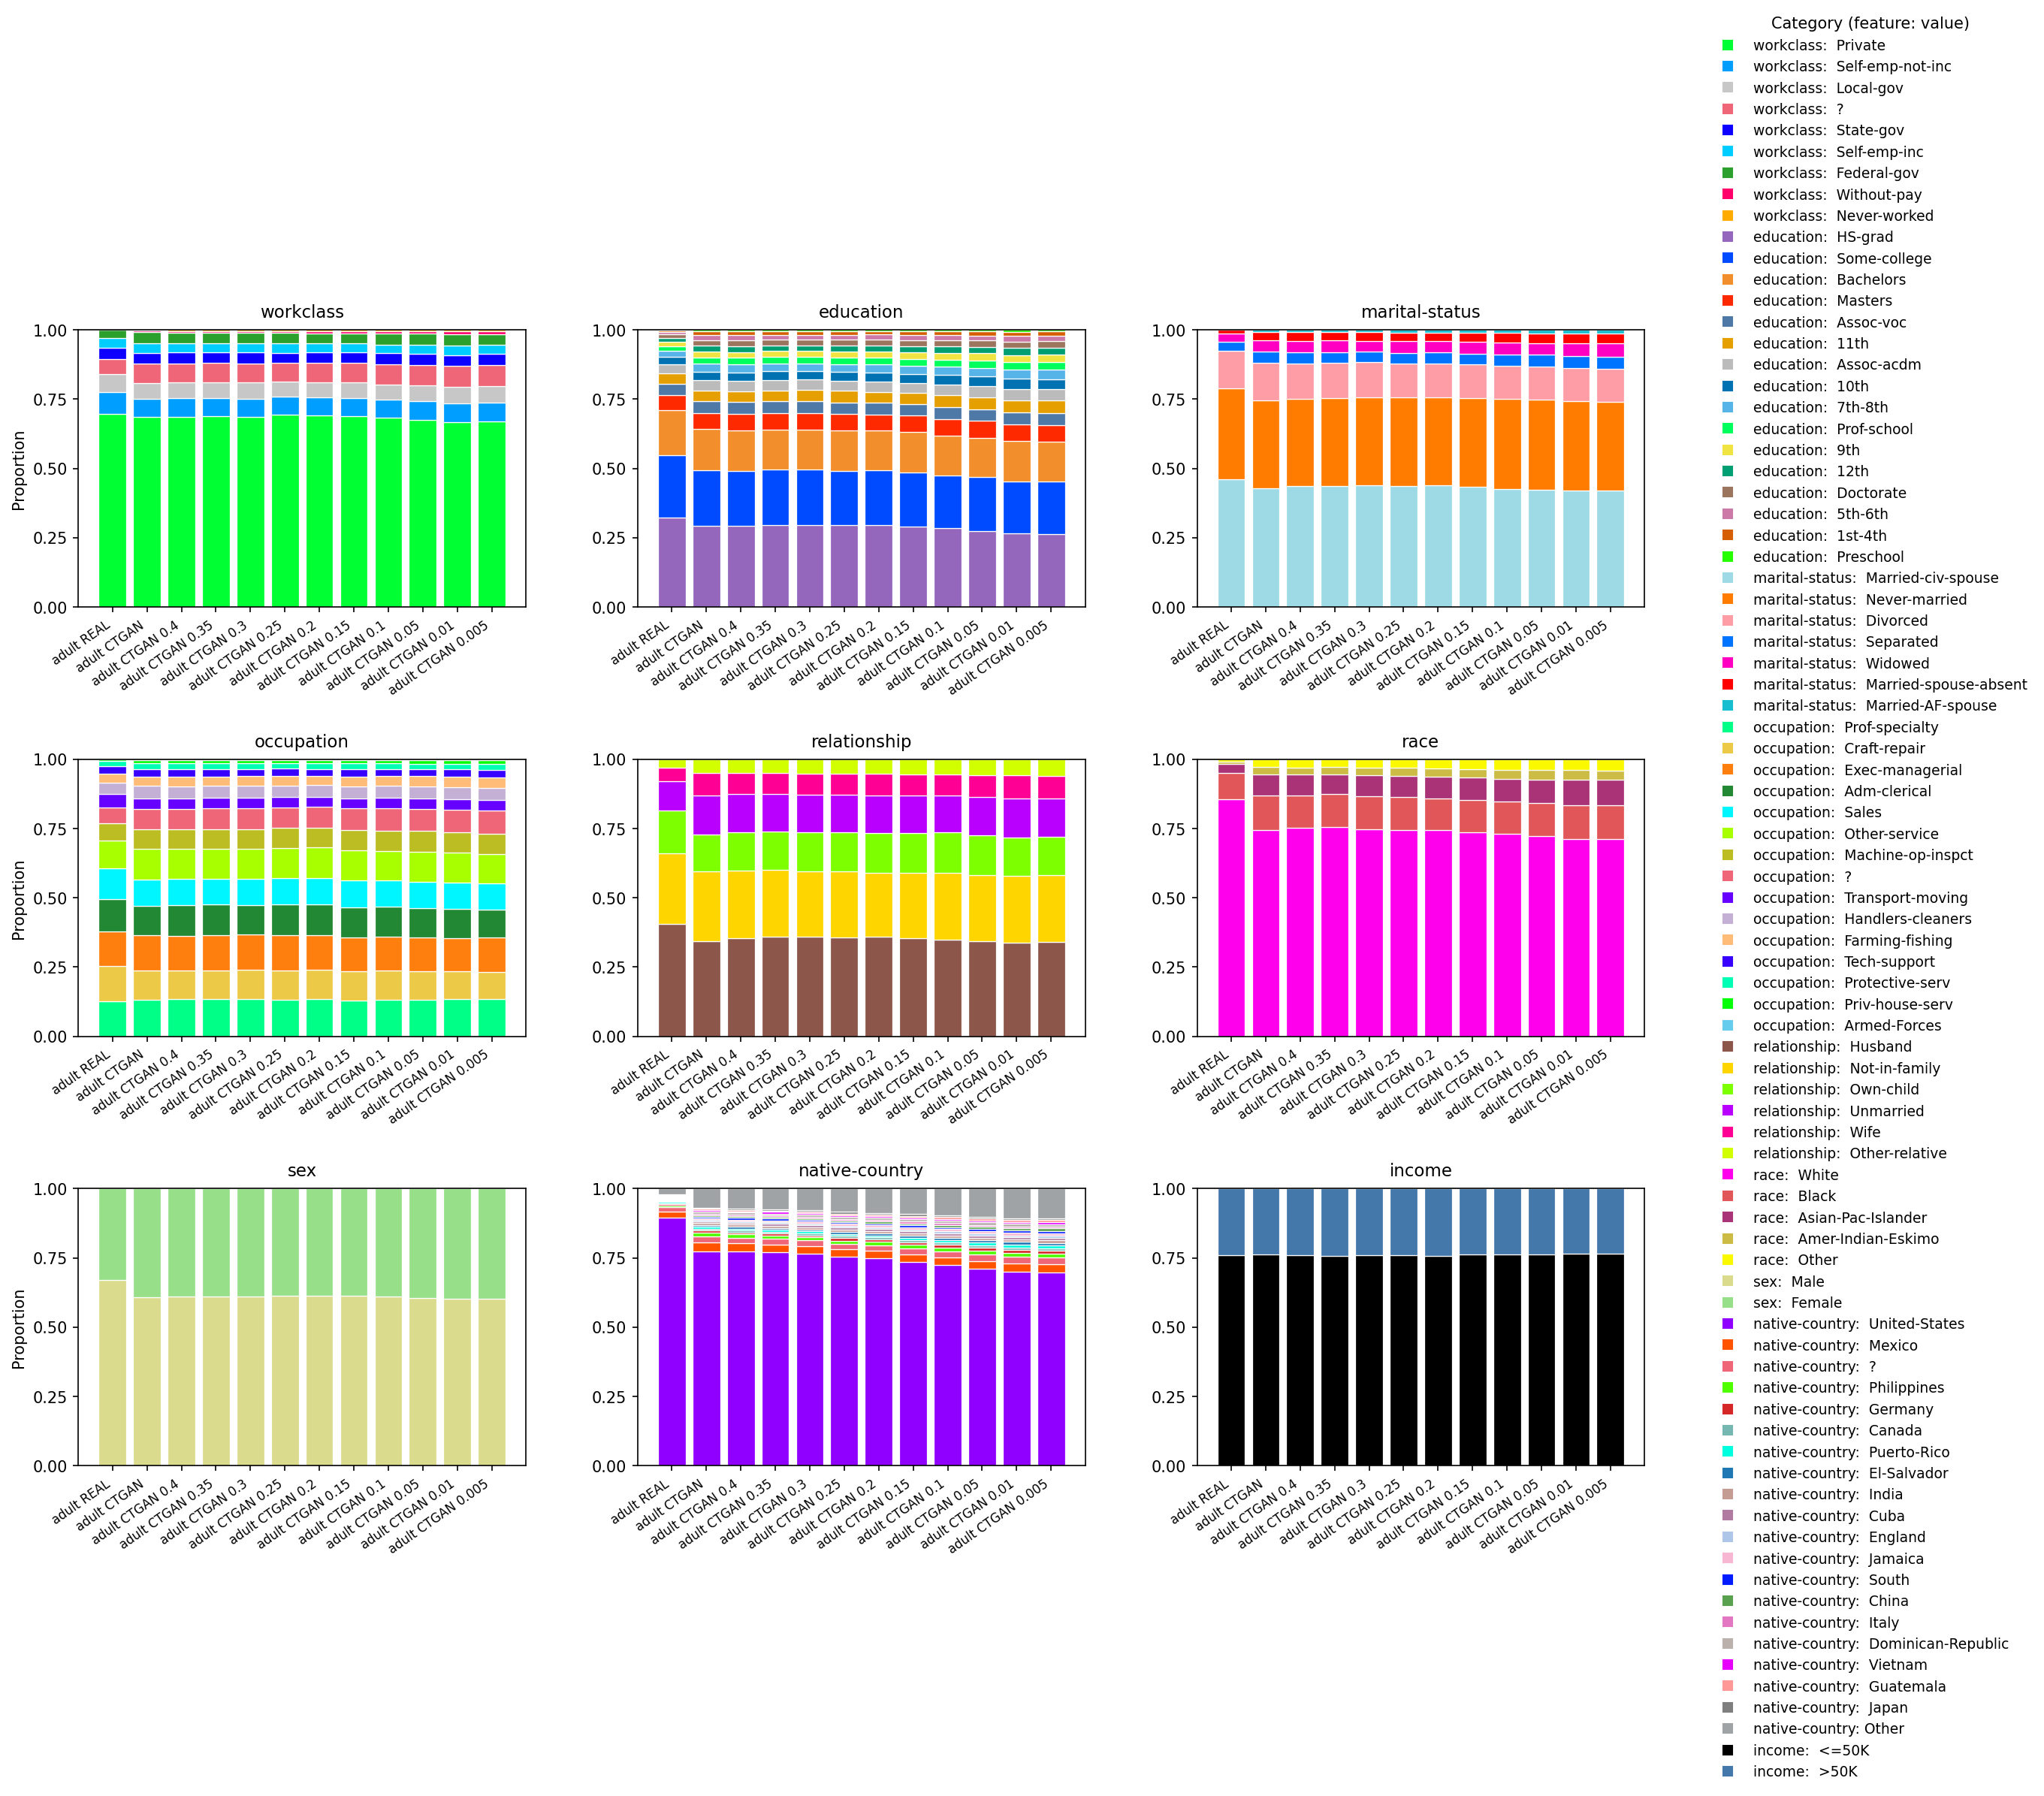

In [39]:
synth = dict_results_adult_ctgan_heom_any['adult CTGAN']['generation_results']['synthetic_data']
synth_to_plot = ['adult CTGAN','adult CTGAN 0.01', 'adult CTGAN 0.3']

datasets = {}
datasets['adult REAL'] = df_real_adult_train

for key, value in dict_results_adult_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']

fig_cat = plot_categorical_stacks_grid(
    datasets=datasets,
    cat_features=cat_list_adult,
    baseline='adult REAL',                 # defaults to first *REAL*
    max_categories_to_plot=20,
    ncols=3,
    figsize=(20, 12),
    save_path="./analysis_out_adult_ctgan/plots/categorical_stacks_grid.png",
)

Per-feature divergences: ./analysis_out_adult_ctgan/divergence_table.csv
Ranking table: ./analysis_out_adult_ctgan/ranking_table.csv
Plots: ./analysis_out_adult_ctgan/plots


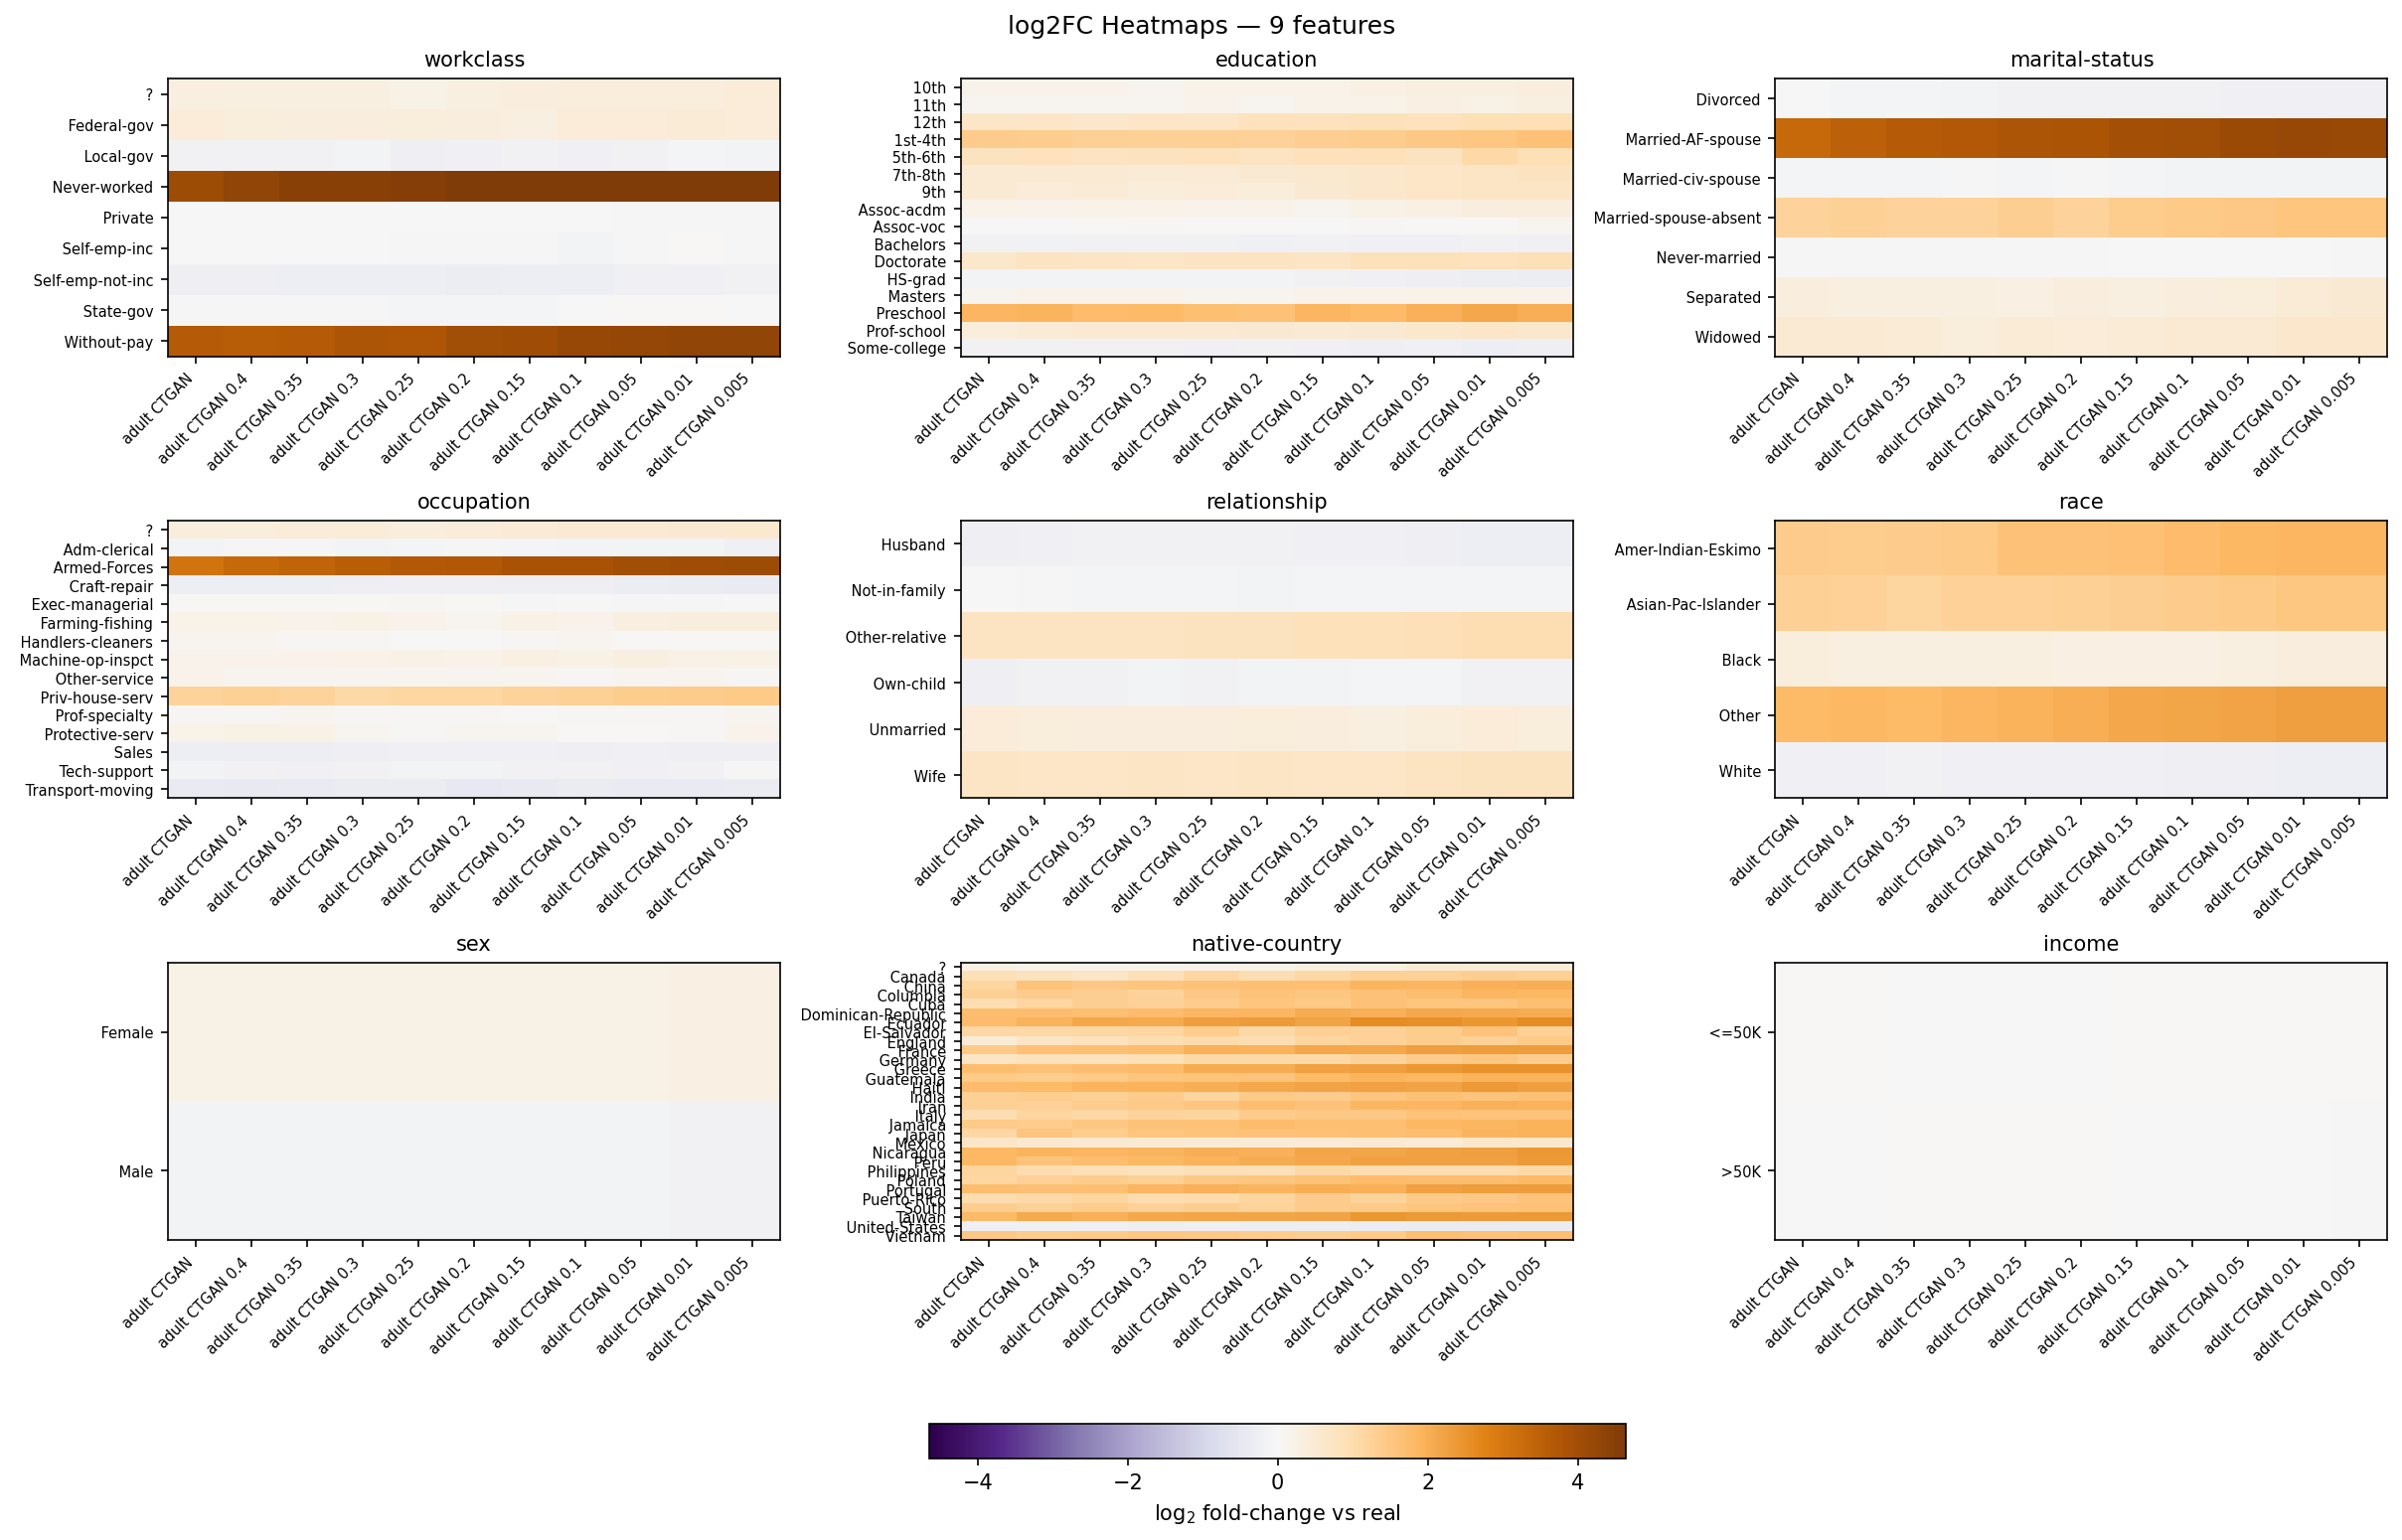

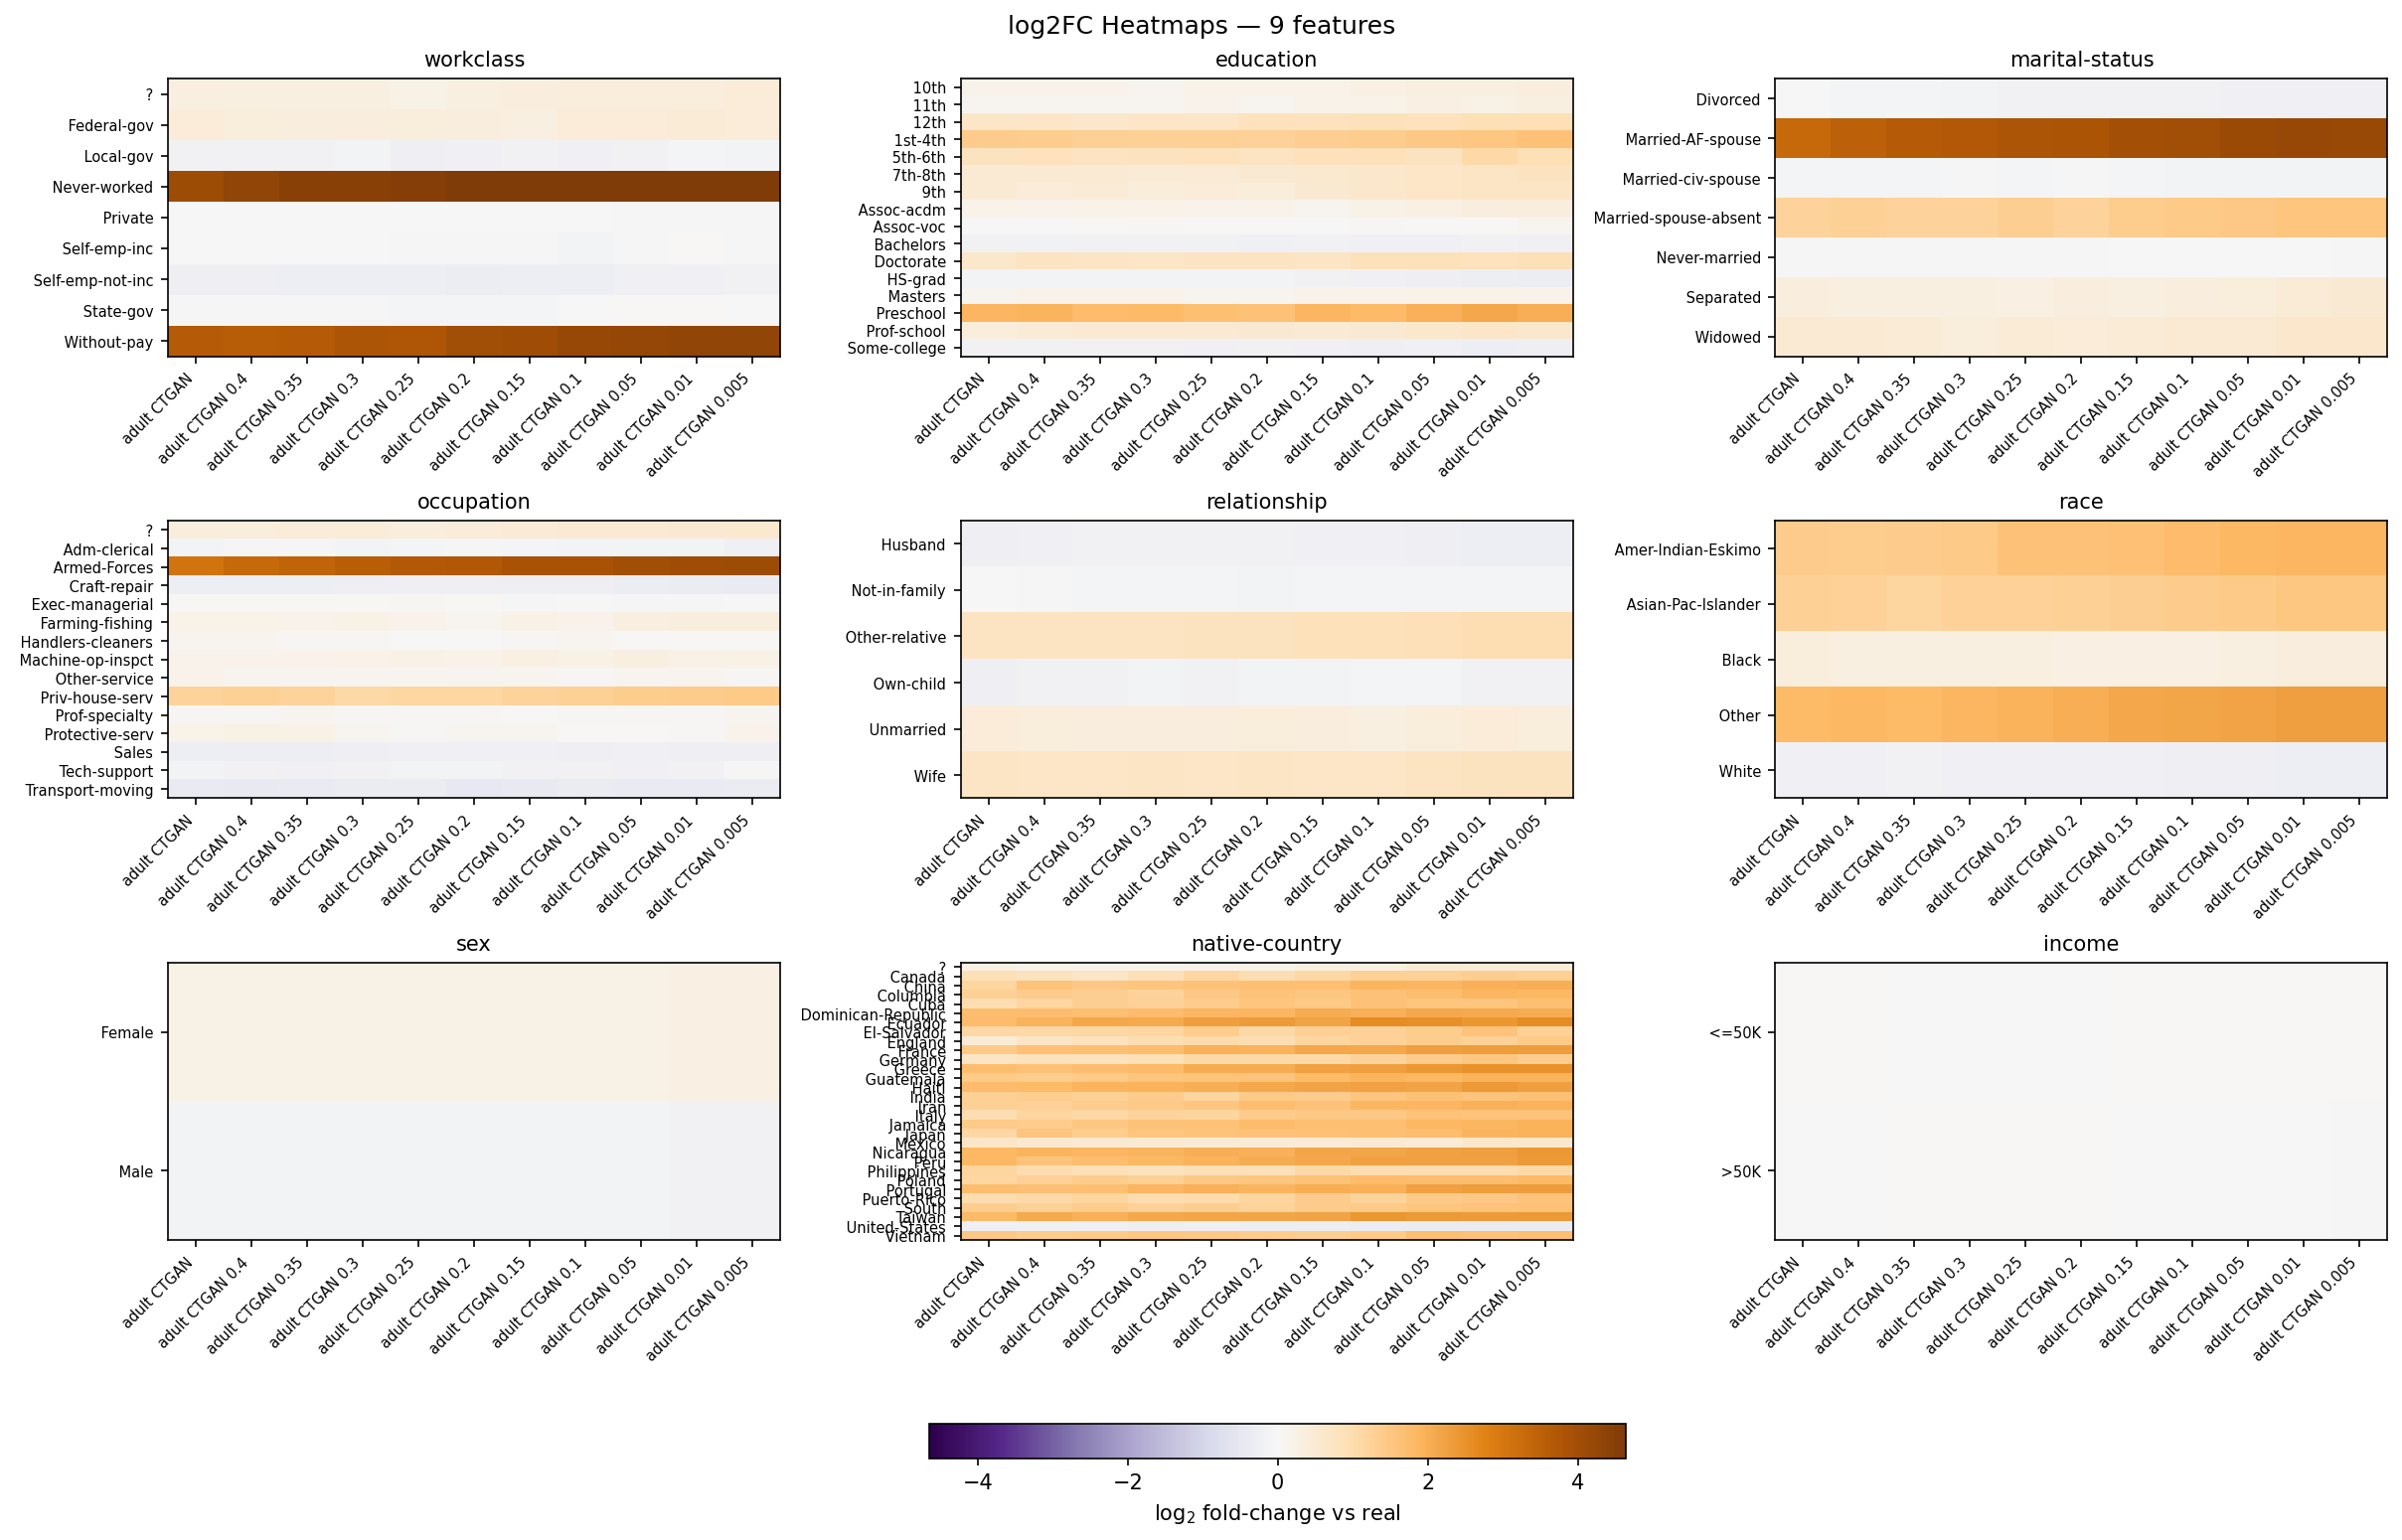

In [40]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_adult_ctgan_heom_any['adult CTGAN']['generation_results']['synthetic_data']
# synth_to_plot = ['adult CTGAN','adult CTGAN 0.01', 'adult CTGAN 0.3']

datasets = {}
datasets['adult REAL'] = df_real_adult_train

for key, value in dict_results_adult_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_adult,
    num_features=num_list_adult,
    baseline='adult REAL',            # default: the highest ε becomes baseline
    out_dir="./analysis_out_adult_ctgan", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])

synth = dict_results_adult_ctgan_heom_any['adult CTGAN']['generation_results']['synthetic_data']
# synth_to_plot = ['adult CTGAN','adult CTGAN 0.01', 'adult CTGAN 0.3']

datasets = {}
datasets['adult REAL'] = df_real_adult_train

for key, value in dict_results_adult_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']
p1, cat_table = categorical_log2fc_table(datasets, cat_list_adult, 'adult REAL', "./analysis_out_adult_ctgan", pseudocount=1e-6)
p2, num_table = numeric_heuristic_table(datasets, num_list_adult, 'adult REAL', "./analysis_out_adult_ctgan", tail_q=(0.05, 0.95))
import pandas as pd

cat_table = pd.read_csv("./analysis_out_adult_ctgan/categorical_log2fc_table.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_adult_ctgan_heom_any]  # order by ε (high→low)

plot_log2fc_heatmaps_grid(
    cat_table,
    features=cat_list_adult,
    dataset_order=datasets,
    top_k=30,
    order_by="baseline",
    ncols=3,
    figsize=(16, 10),
    save_path="./analysis_out_adult_ctgan/plots/log2fc_heatmap_grid_adult_ctgan.png",
)

In [30]:
resemblance_evaluation = {}

for key in dict_results_adult_ctgan_heom_any :
    resemblance_evaluation[key] = dict_results_adult_ctgan_heom_any[key]['resemblance_evaluation_results']
resemblance_evaluation

{'adult CTGAN': {'categorical_univariate': {'chi_test':                 chisquared_tests_p
   workclass                 0.382072
   education                 0.736709
   marital-status            0.397769
   occupation                0.399137
   relationship              0.176184
   race                      0.616412
   sex                       0.883451
   native-country            0.969178
   income                    0.885196,
   'jensen_shanon':                 KL_divergence_tests  JS_divergence
   workclass                  0.010872       0.068383
   education                  0.017835       0.083220
   marital-status             0.015172       0.079217
   occupation                 0.013641       0.071705
   relationship               0.023961       0.094907
   race                       0.045323       0.134724
   sex                        0.008087       0.054317
   native-country             0.058306       0.154322
   income                     0.000052       0.004314,
   'jens

In [18]:

epsilon = [ 'adult CTGAN : baseline',
            'adult CTGAN eps = 0.4',
            'adult CTGAN eps = 0.35',
            'adult CTGAN eps = 0.3',
            'adult CTGAN eps = 0.25',
            'adult CTGAN eps = 0.2',
            'adult CTGAN eps = 0.15',
            'adult CTGAN eps = 0.1',
            'adult CTGAN eps = 0.05',
            'adult CTGAN eps = 0.01',
            'adult CTGAN eps = 0.005']
dict_results = dict_results_adult_ctgan_heom_any
get_mean_univariate_evaluation_markdown(dict_results_adult_ctgan_heom_any, epsilon)
print_js_cohen(dict_results_adult_ctgan_heom_any, epsilon)

|                                |   adult CTGAN : baseline |   adult CTGAN eps = 0.4 |   adult CTGAN eps = 0.35 |   adult CTGAN eps = 0.3 |   adult CTGAN eps = 0.25 |   adult CTGAN eps = 0.2 |   adult CTGAN eps = 0.15 |   adult CTGAN eps = 0.1 |   adult CTGAN eps = 0.05 |   adult CTGAN eps = 0.01 |   adult CTGAN eps = 0.005 |
|:-------------------------------|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|-------------------------:|--------------------------:|
| categorical JS divergence mean |                0.0827899 |               0.0821198 |                0.0815654 |               0.0828301 |                0.0857045 |               0.0879083 |                0.0925925 |               0.0969028 |                0.103713  |                0.108542  |                 0.103713  |
| numerical c

In [56]:
dict_cohen_num

{'age': array([0.00686576, 0.00225654, 0.00224915, 0.00751485, 0.01337801,
        0.022748  , 0.01573541, 0.01839141, 0.01123197, 0.00641783,
        0.01123197]),
 'fnlwgt': array([0.06229204, 0.04827365, 0.0482582 , 0.04917863, 0.05726445,
        0.06036372, 0.06970286, 0.06218745, 0.08407807, 0.08912199,
        0.08407807]),
 'education-num': array([0.06980082, 0.06898373, 0.06536868, 0.05666931, 0.06519173,
        0.06453395, 0.07890809, 0.07539626, 0.08111974, 0.08379033,
        0.08111974]),
 'capital-gain': array([0.06533259, 0.06482275, 0.06232585, 0.0615713 , 0.05754149,
        0.0545965 , 0.05535936, 0.05420699, 0.05166428, 0.04909079,
        0.05166428]),
 'capital-loss': array([0.02647899, 0.05028901, 0.03389526, 0.0162809 , 0.01569538,
        0.03320453, 0.03180876, 0.04177754, 0.04386784, 0.05682404,
        0.04386784]),
 'hours-per-week': array([0.03104125, 0.04545692, 0.03909007, 0.04376802, 0.03608265,
        0.04111842, 0.04824066, 0.03925833, 0.03209742, 0.

In [31]:
resemblance_evaluation = {}

for key in dict_results_adult_tvae_heom_any :
    resemblance_evaluation[key] = dict_results_adult_tvae_heom_any[key]['resemblance_evaluation_results']
resemblance_evaluation

{'adult TVAE': {'categorical_univariate': {'chi_test':                 chisquared_tests_p
   workclass             8.775984e-01
   education             6.848347e-01
   marital-status        8.960391e-01
   occupation            9.949112e-01
   relationship          4.646339e-01
   race                  2.504322e-01
   sex                   3.385462e-01
   native-country        5.241509e-10
   income                4.565256e-01,
   'jensen_shanon':                 KL_divergence_tests  JS_divergence
   workclass                  0.018163       0.078006
   education                  0.036613       0.106375
   marital-status             0.009667       0.059842
   occupation                 0.019360       0.084381
   relationship               0.015458       0.075284
   race                       0.011521       0.065028
   sex                        0.000462       0.012931
   native-country                  inf       0.067798
   income                     0.000571       0.014301,
   'jense

Per-feature divergences: ./analysis_out_adult_tvae/divergence_table.csv
Ranking table: ./analysis_out_adult_tvae/ranking_table.csv
Plots: ./analysis_out_adult_tvae/plots


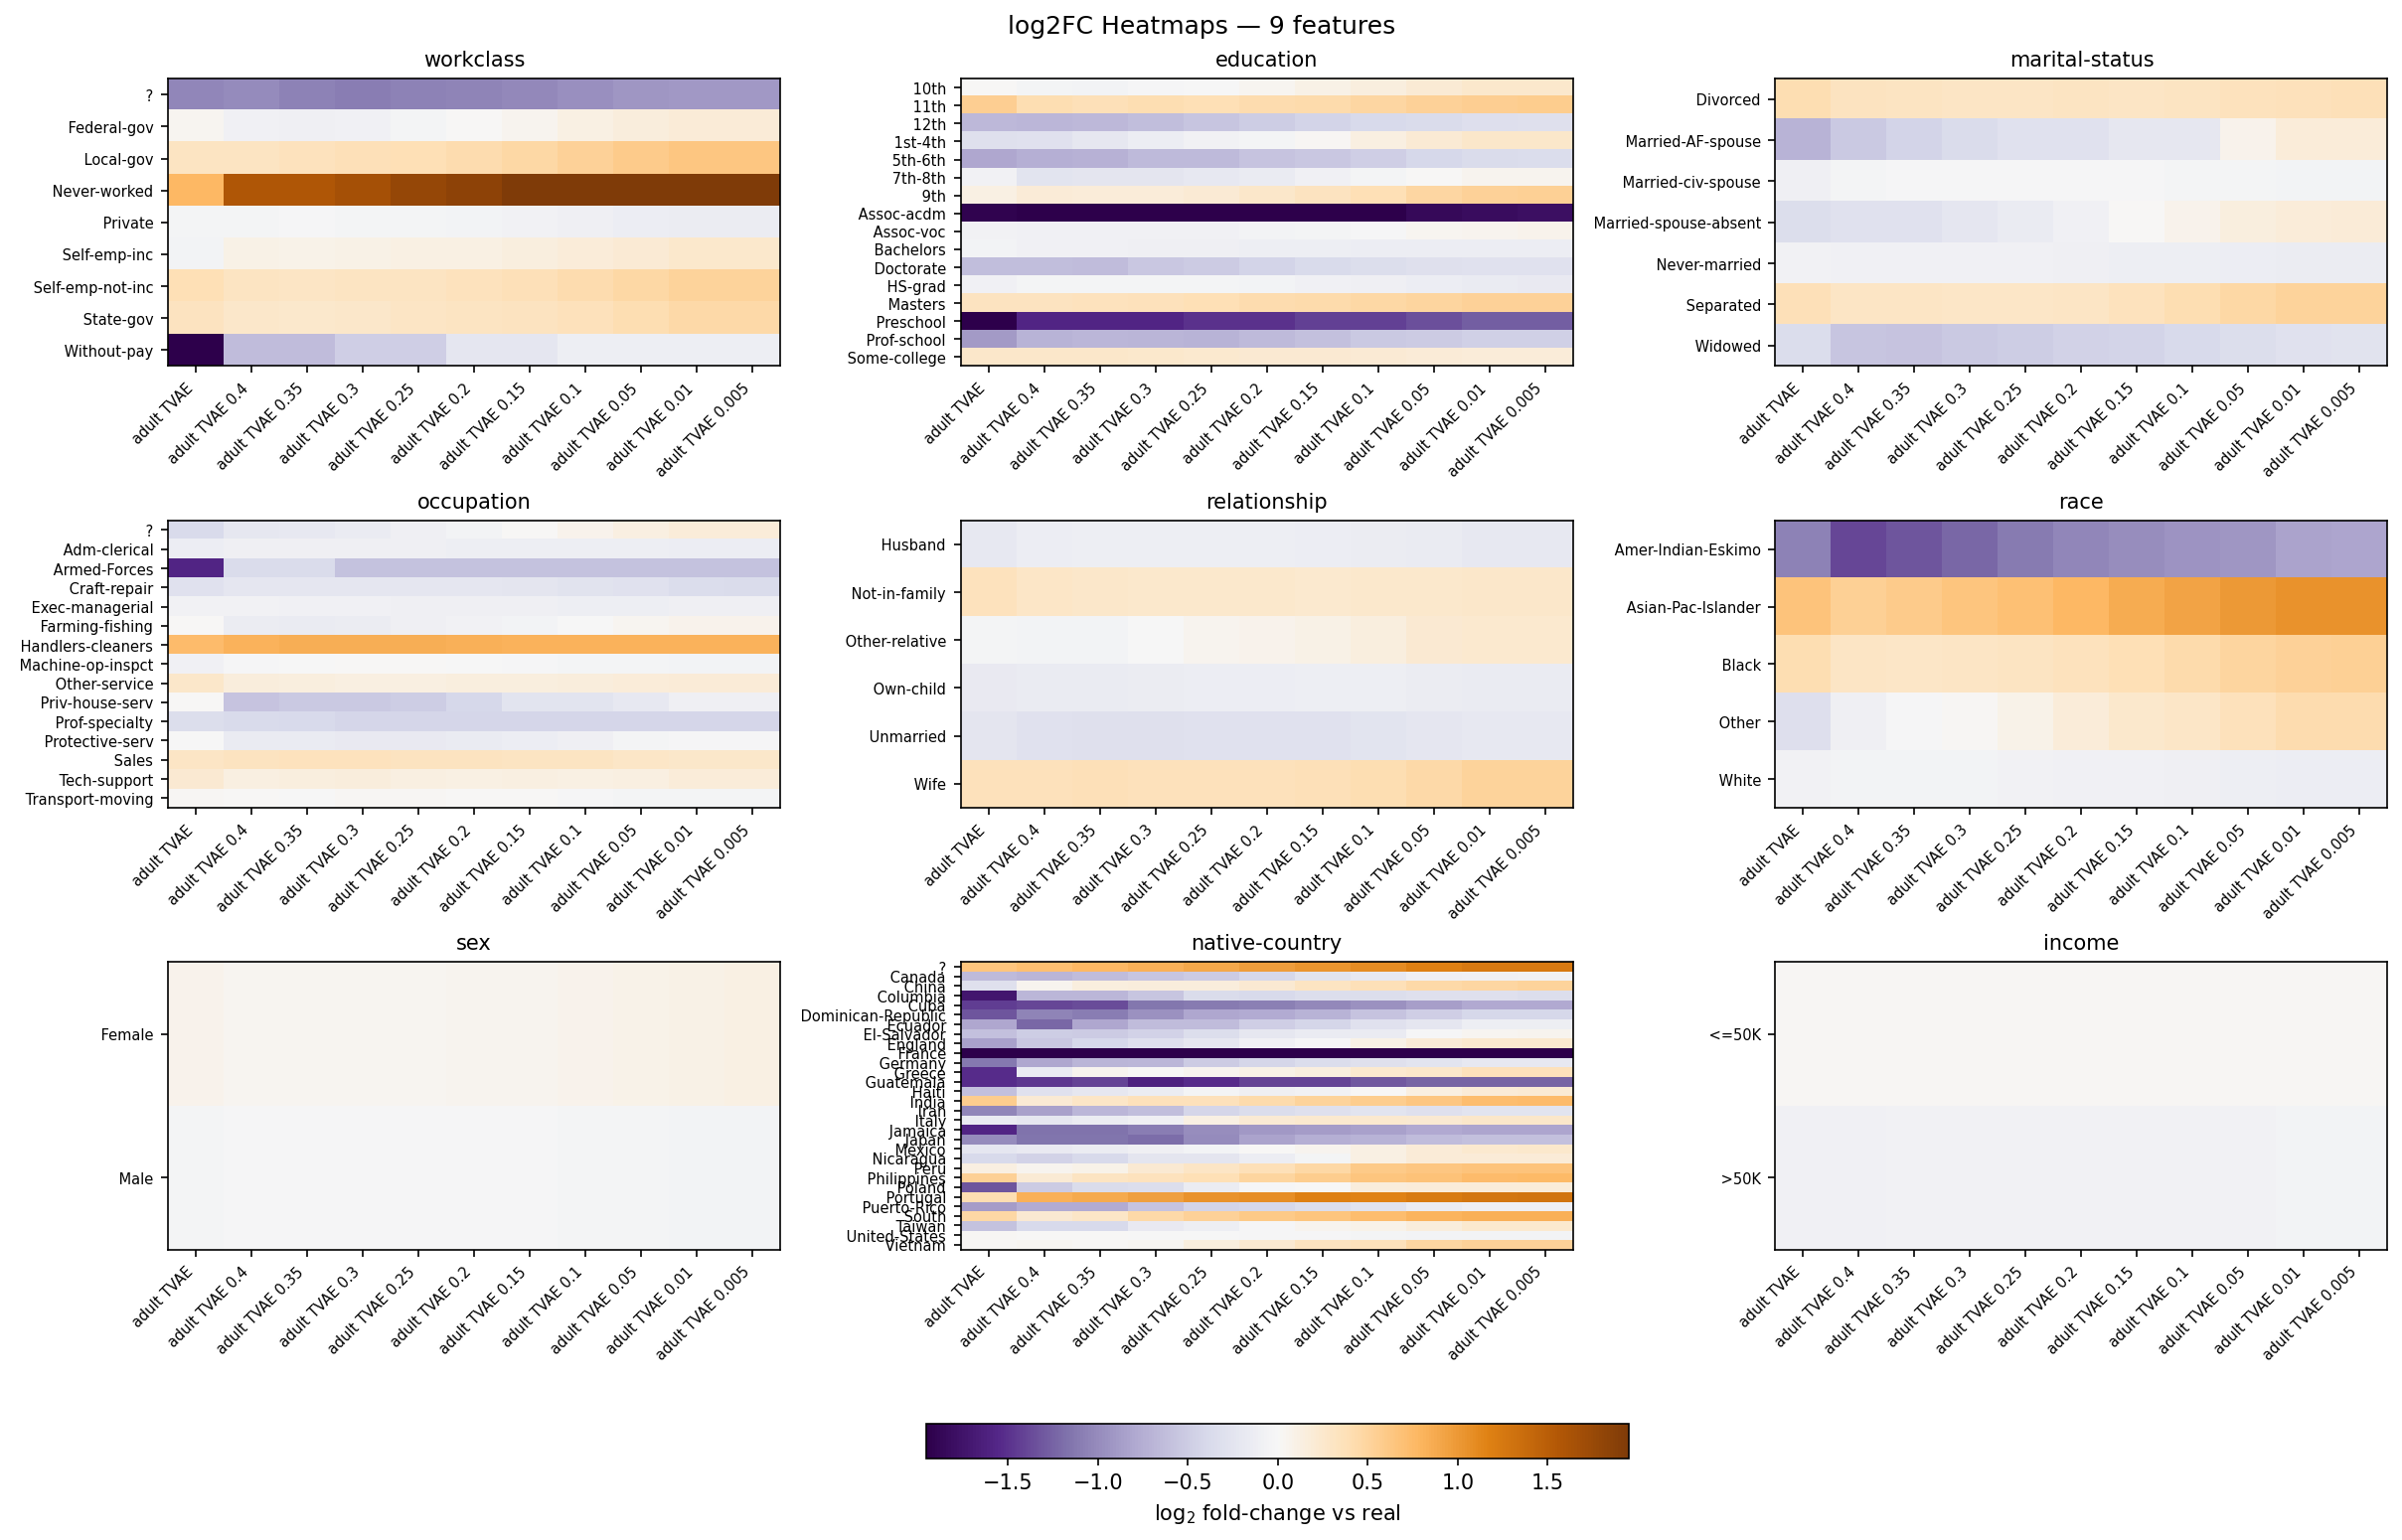

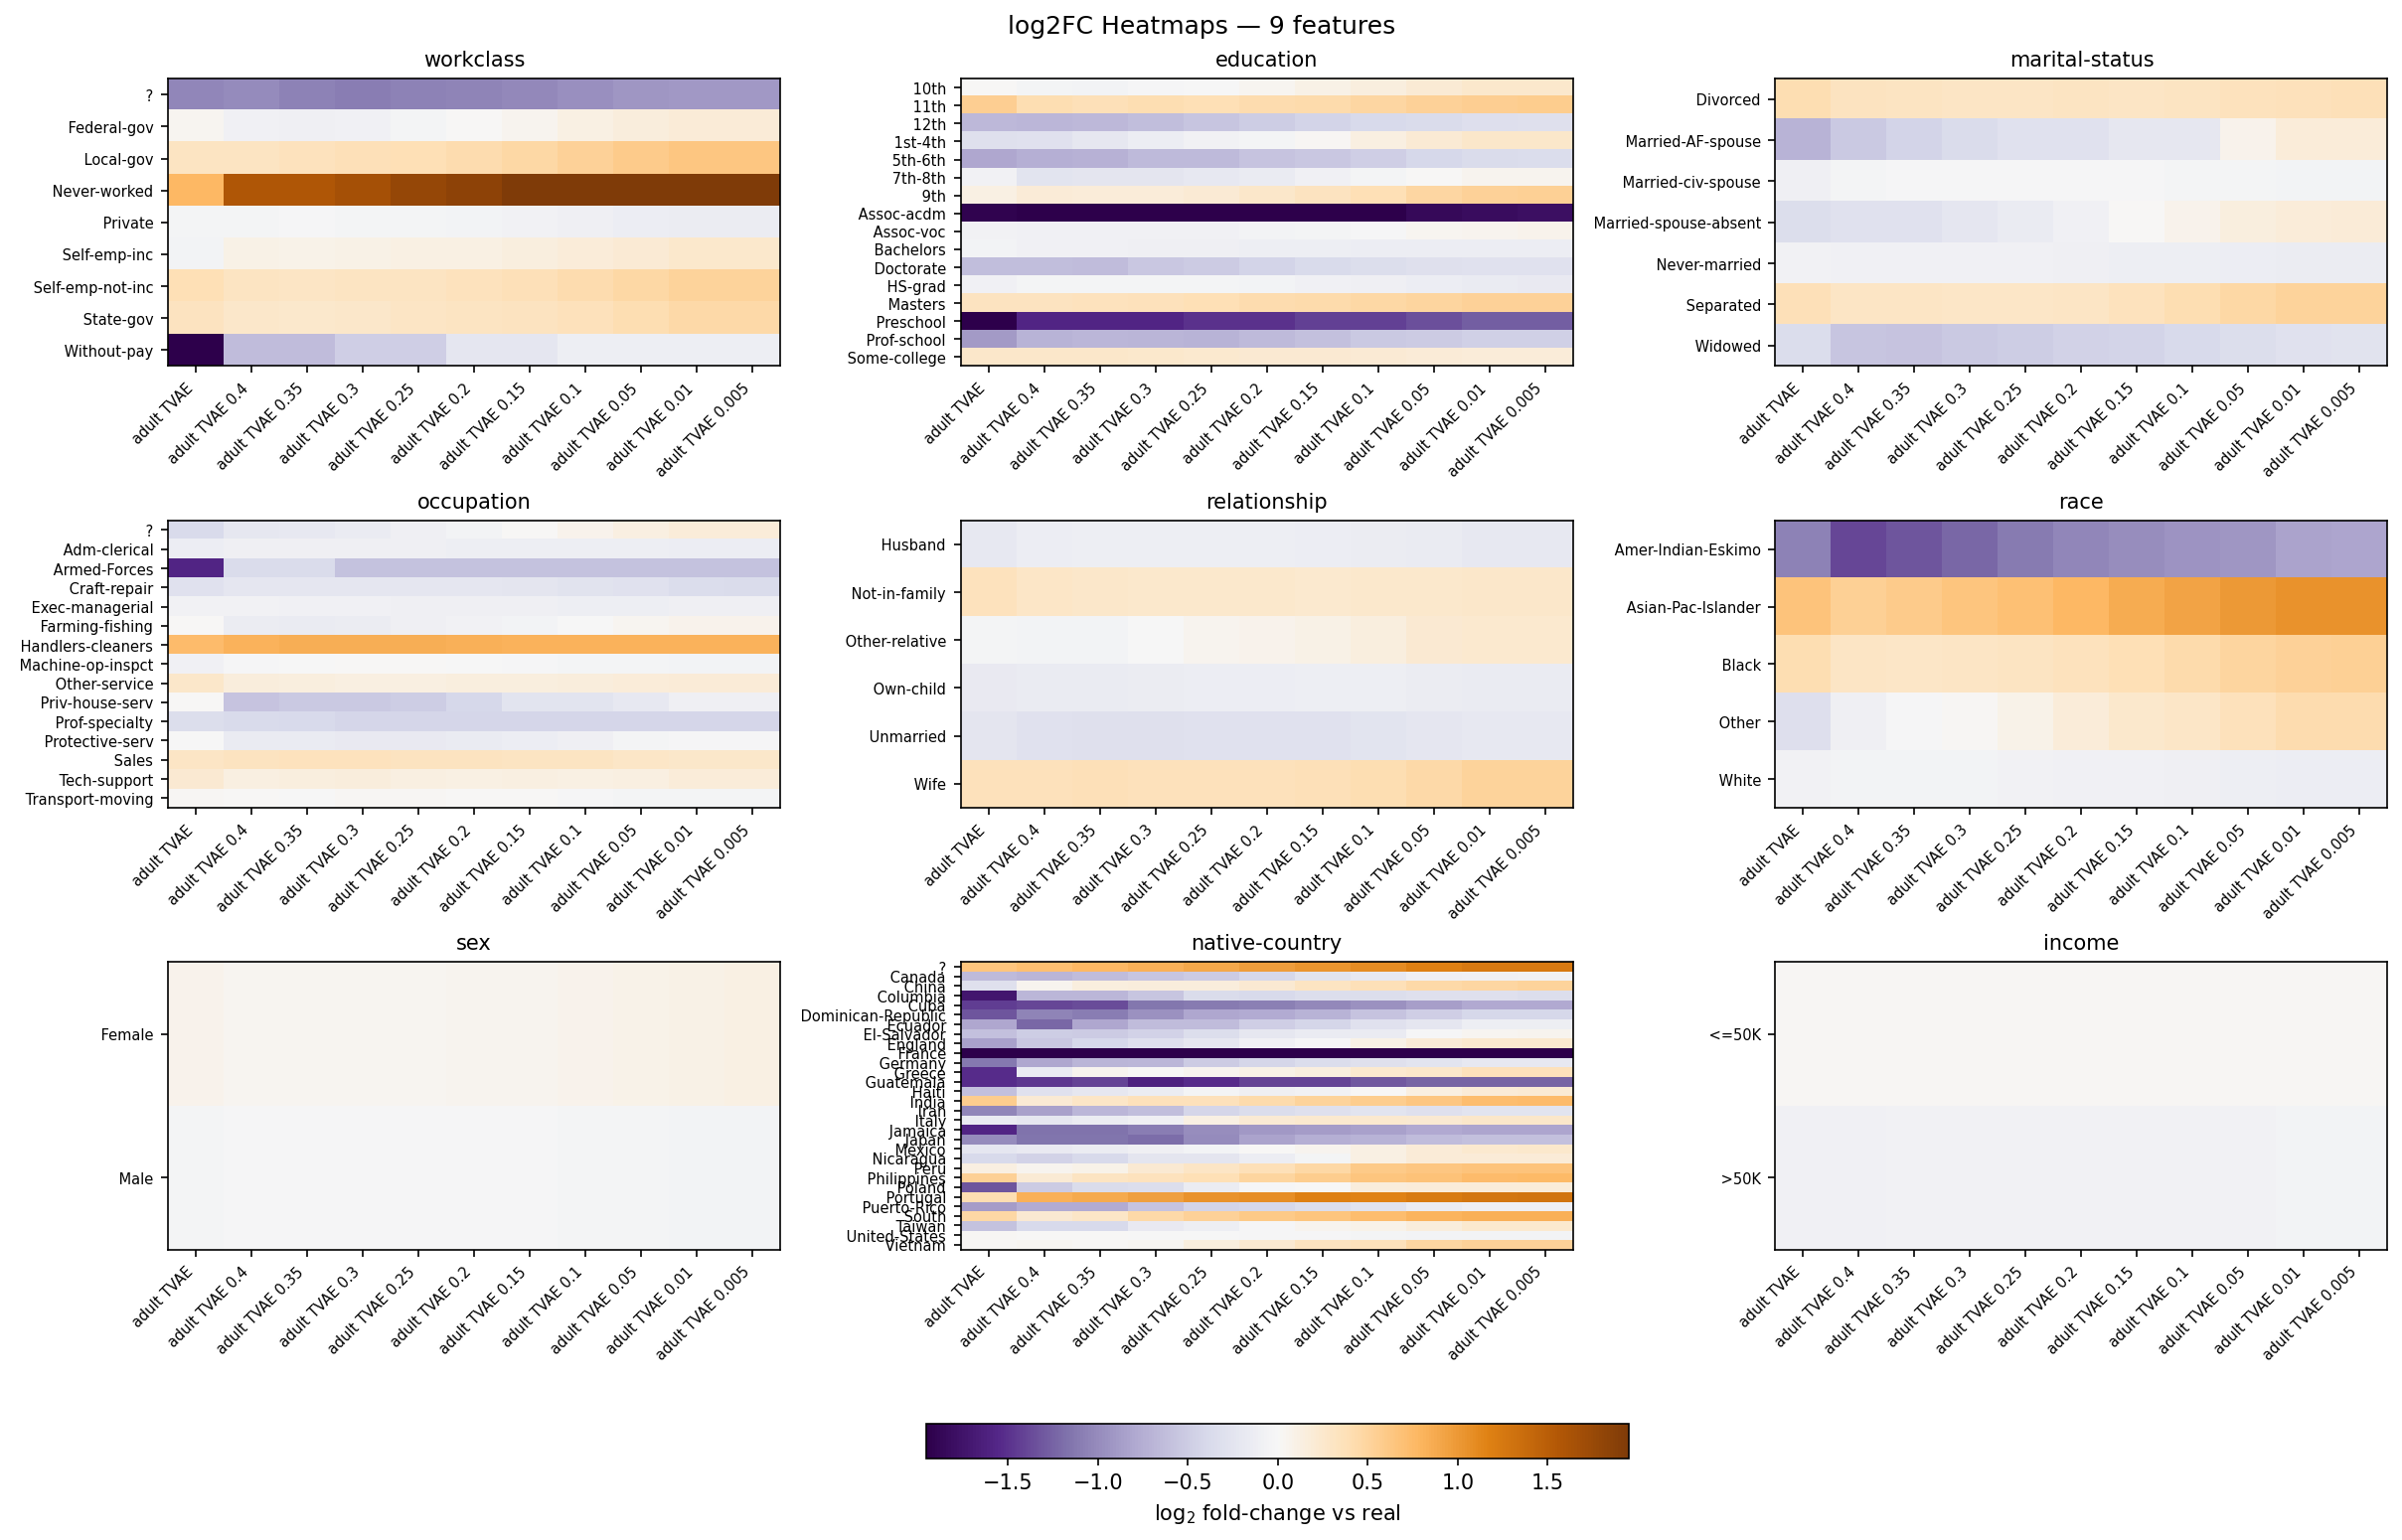

In [41]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_adult_tvae_heom_any['adult TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['adult TVAE','adult TVAE 0.01', 'adult TVAE 0.3']

datasets = {}
datasets['adult REAL'] = df_real_adult_train

for key, value in dict_results_adult_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_adult,
    num_features=num_list_adult,
    baseline='adult REAL',            # default: the highest ε becomes baseline
    out_dir="./analysis_out_adult_tvae", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])

synth = dict_results_adult_tvae_heom_any['adult TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['adult TVAE','adult TVAE 0.01', 'adult TVAE 0.3']

datasets = {}
datasets['adult REAL'] = df_real_adult_train

for key, value in dict_results_adult_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']
p1, cat_table = categorical_log2fc_table(datasets, cat_list_adult, 'adult REAL', "./analysis_out_adult_tvae", pseudocount=1e-6)
p2, num_table = numeric_heuristic_table(datasets, num_list_adult, 'adult REAL', "./analysis_out_adult_tvae", tail_q=(0.05, 0.95))
import pandas as pd

cat_table = pd.read_csv("./analysis_out_adult_tvae/categorical_log2fc_table.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_adult_tvae_heom_any]  # order by ε (high→low)

plot_log2fc_heatmaps_grid(
    cat_table,
    features=cat_list_adult,
    dataset_order=datasets,
    top_k=30,
    order_by="baseline",
    ncols=3,
    figsize=(16, 10),
    save_path="./analysis_out_adult_tvae/plots/log2fc_heatmap_grid_adult_tvae.png",
)

Per-feature divergences: ./analysis_out_cardio_tvae/divergence_table.csv
Ranking table: ./analysis_out_cardio_tvae/ranking_table.csv
Plots: ./analysis_out_cardio_tvae/plots


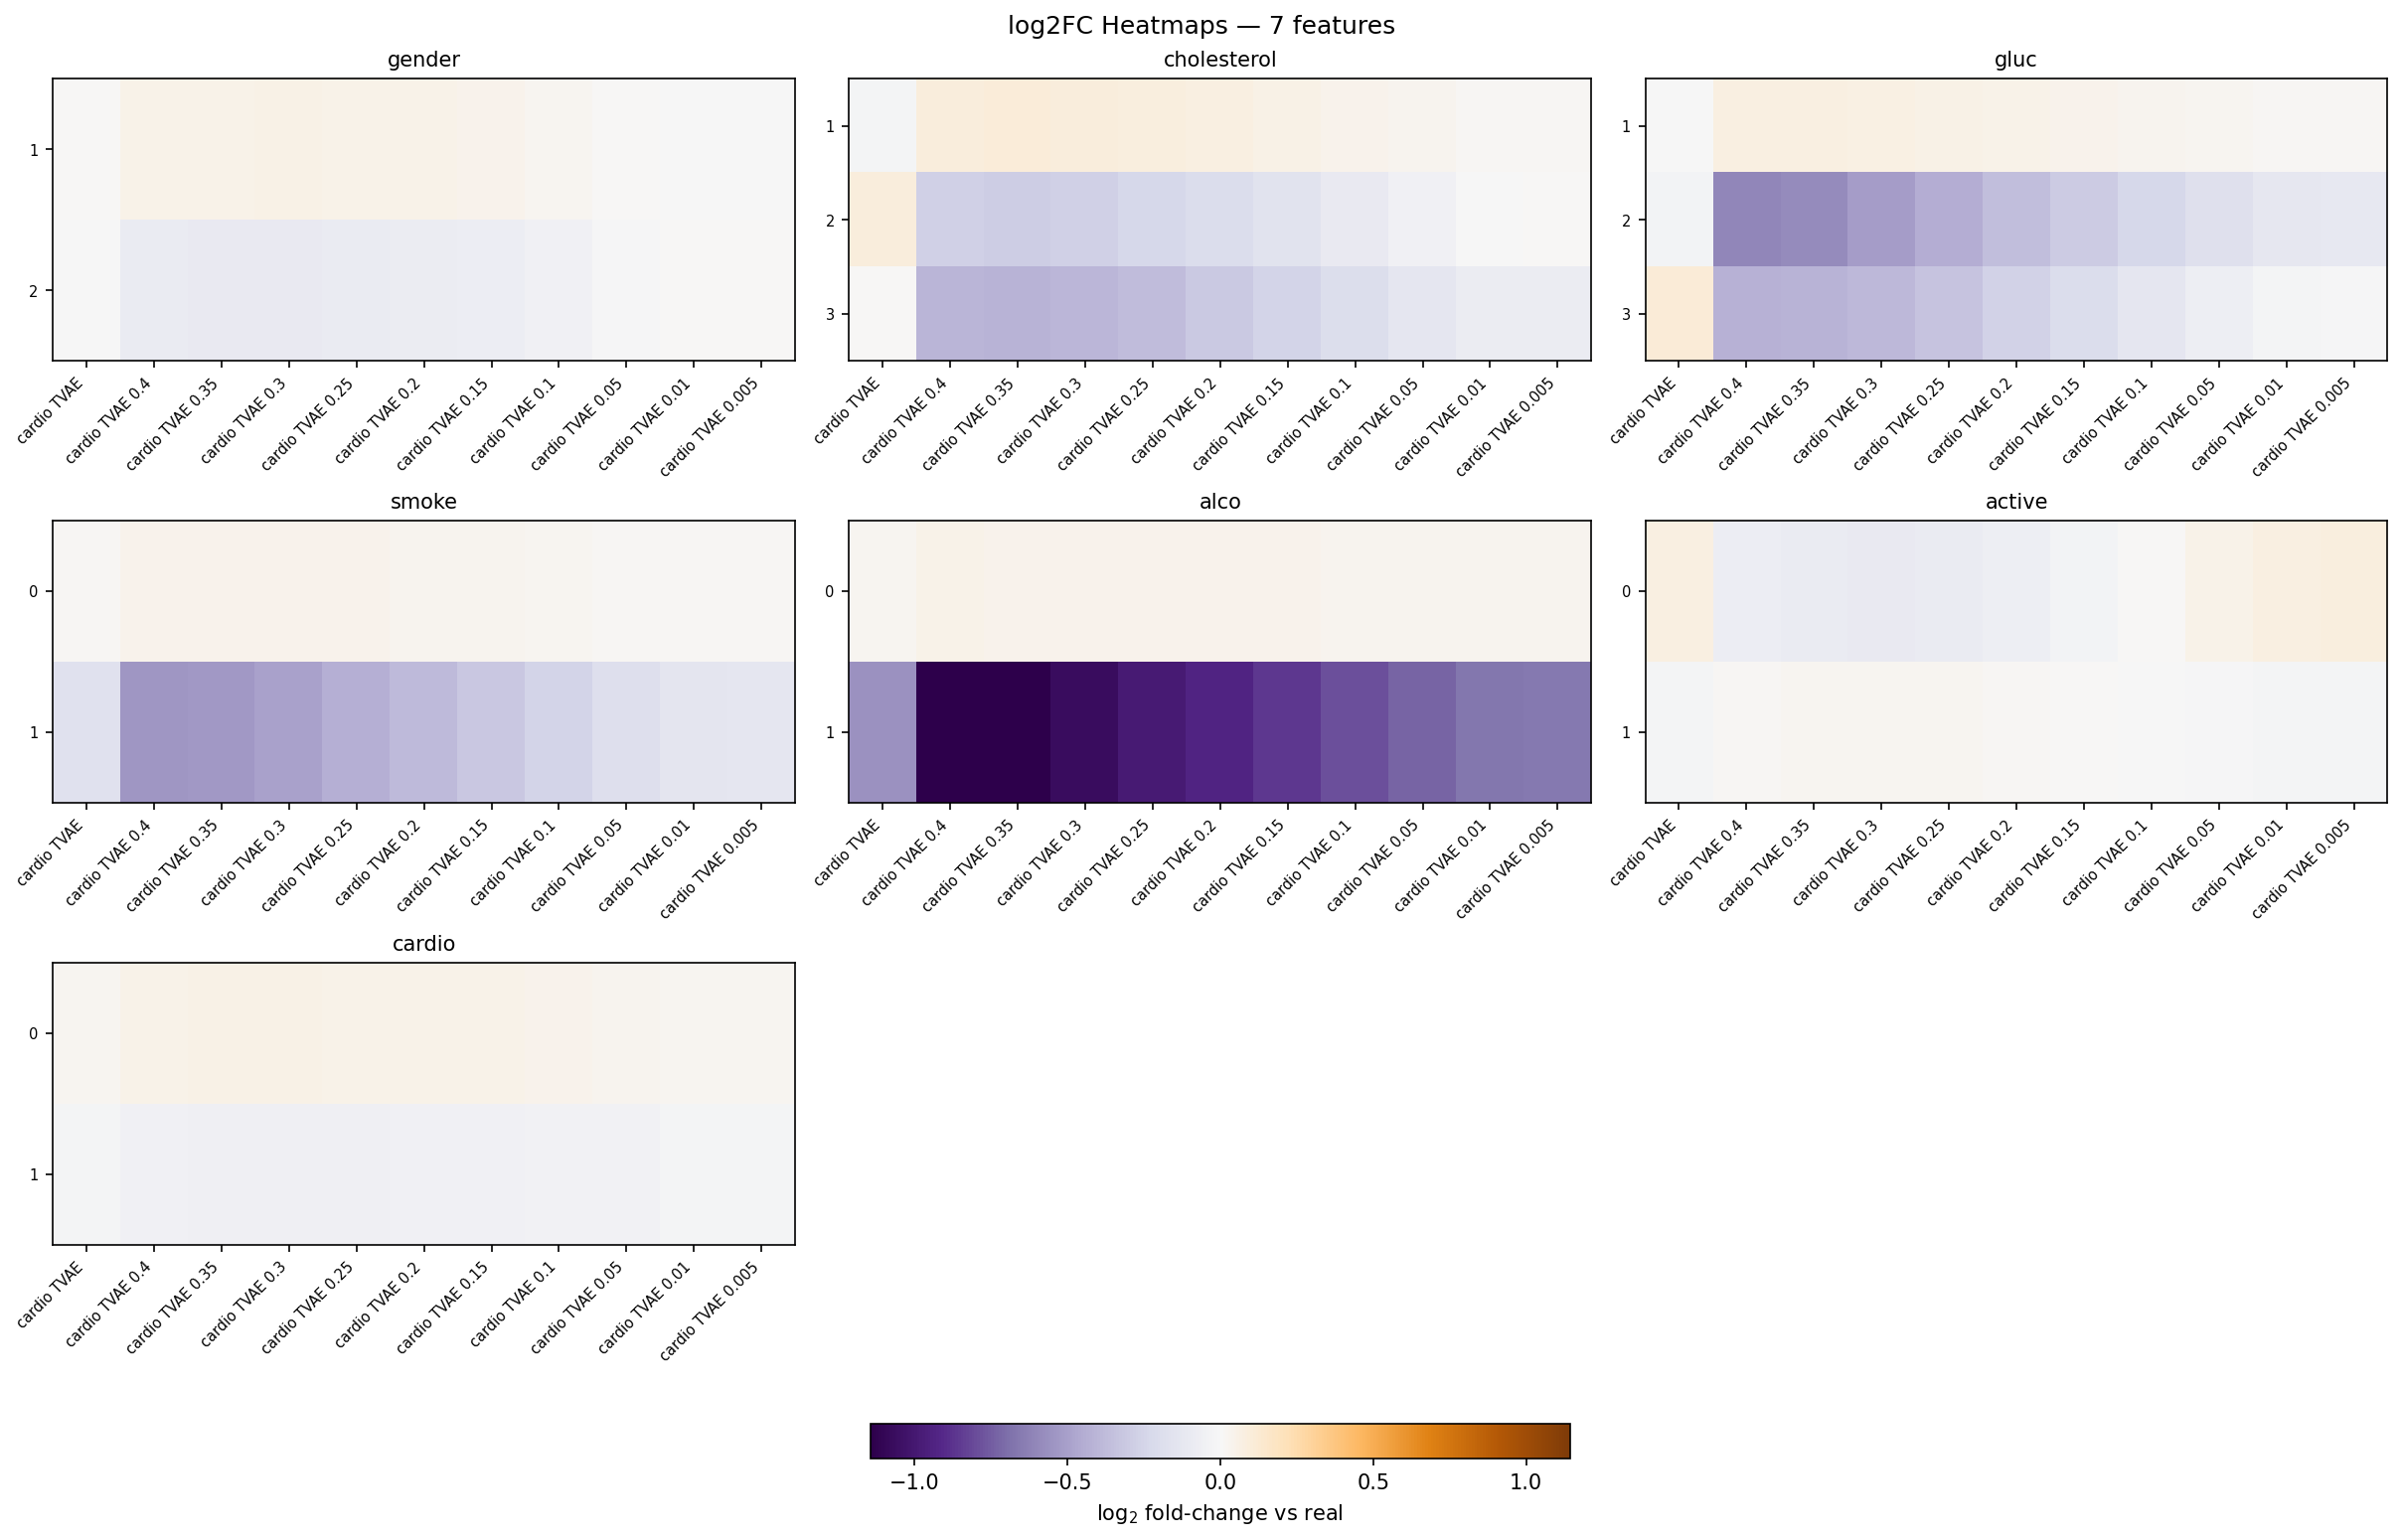

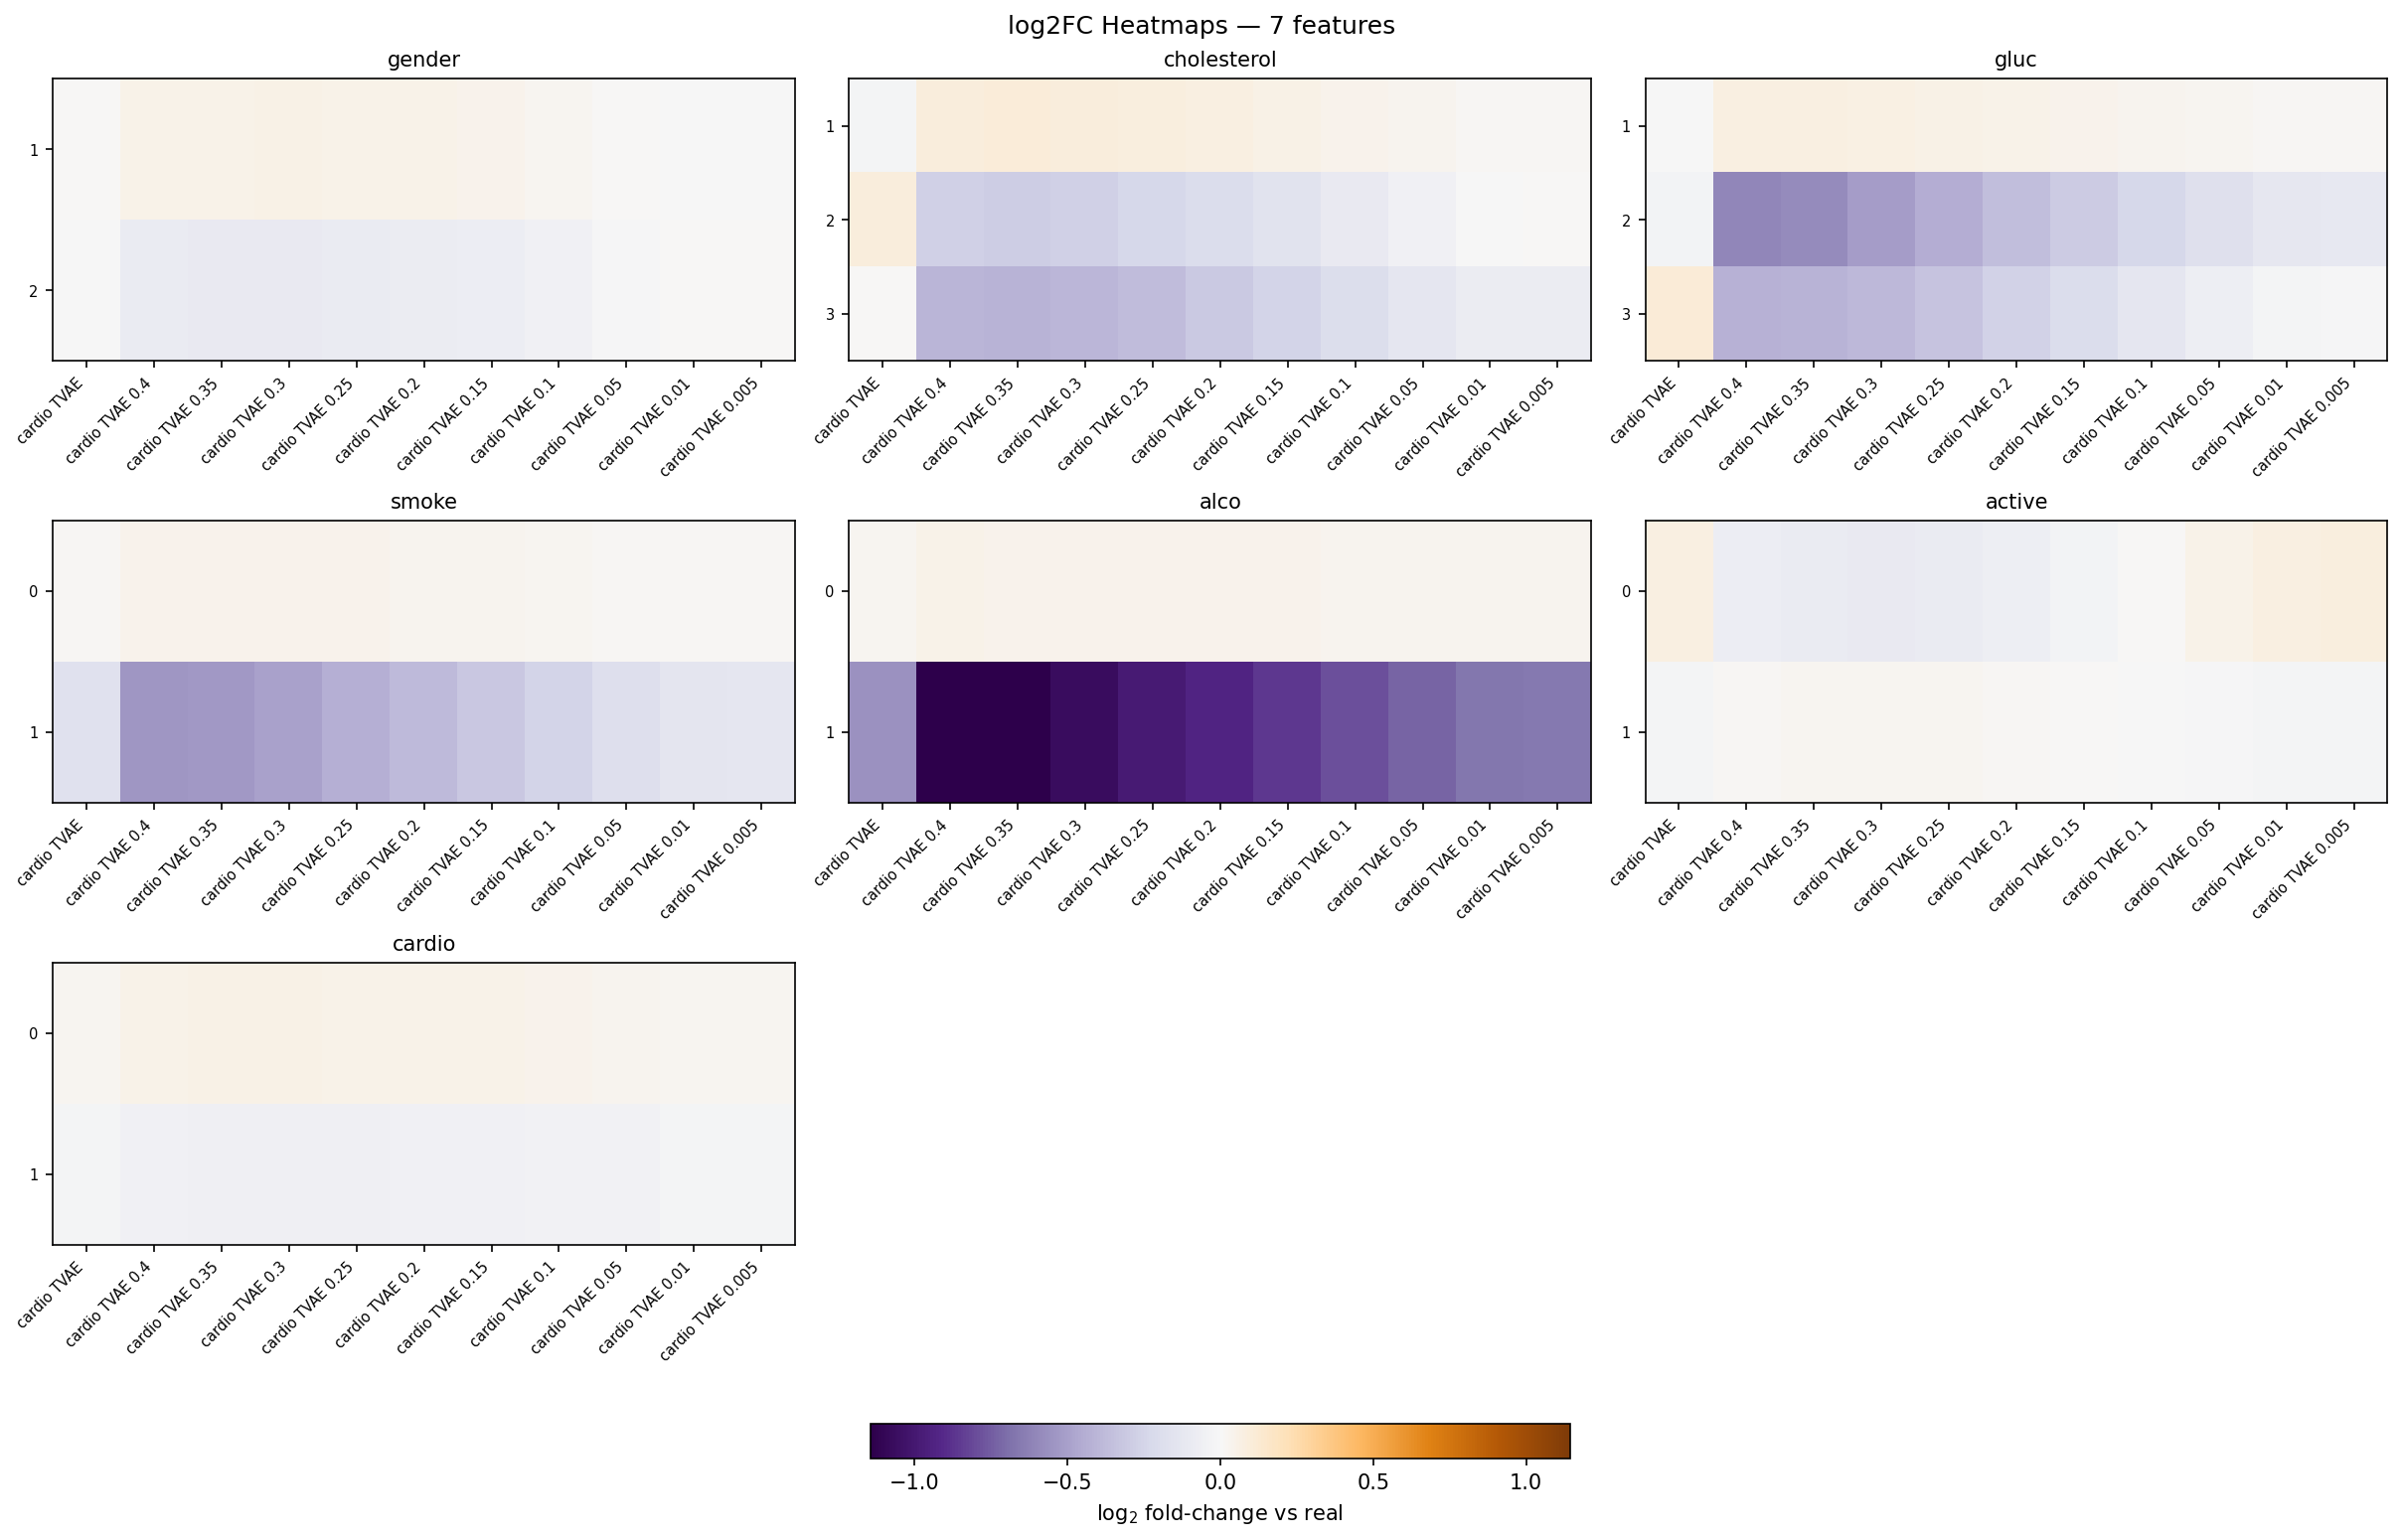

In [34]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_cardio_tvae_heom_any['cardio TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['cardio TVAE','cardio TVAE 0.01', 'cardio TVAE 0.3']

datasets = {}
datasets['cardio REAL'] = df_real_cardio_train

for key, value in dict_results_cardio_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_cardio,
    num_features=num_list_cardio,
    baseline='cardio REAL',            # default: the highest ε becomes baseline
    out_dir="./analysis_out_cardio_tvae", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])

synth = dict_results_cardio_tvae_heom_any['cardio TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['cardio TVAE','cardio TVAE 0.01', 'cardio TVAE 0.3']

datasets = {}
datasets['cardio REAL'] = df_real_cardio_train

for key, value in dict_results_cardio_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']
p1, cat_table = categorical_log2fc_table(datasets, cat_list_cardio, 'cardio REAL', "./analysis_out_cardio_tvae", pseudocount=1e-6)
p2, num_table = numeric_heuristic_table(datasets, num_list_cardio, 'cardio REAL', "./analysis_out_cardio_tvae", tail_q=(0.05, 0.95))
import pandas as pd

cat_table = pd.read_csv("./analysis_out_cardio_tvae/categorical_log2fc_table.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_cardio_tvae_heom_any]  # order by ε (high→low)

plot_log2fc_heatmaps_grid(
    cat_table,
    features=cat_list_cardio,
    dataset_order=datasets,
    top_k=30,
    order_by="baseline",
    ncols=3,
    figsize=(16, 10),
    save_path="./analysis_out_cardio_tvae/plots/log2fc_heatmap_grid_cardio_tvae.png",
)

In [19]:
epsilon = [ 'adult TVAE : baseline',
            'adult TVAE eps = 0.4',
            'adult TVAE eps = 0.35',
            'adult TVAE eps = 0.3',
            'adult TVAE eps = 0.25',
            'adult TVAE eps = 0.2',
            'adult TVAE eps = 0.15',
            'adult TVAE eps = 0.1',
            'adult TVAE eps = 0.05',
            'adult TVAE eps = 0.01',
            'adult TVAE eps = 0.005']
dict_results = dict_results_adult_tvae_heom_any
get_mean_univariate_evaluation_markdown(dict_results_adult_tvae_heom_any, epsilon)
print_js_cohen(dict_results_adult_tvae_heom_any, epsilon)

|                                |   adult TVAE : baseline |   adult TVAE eps = 0.4 |   adult TVAE eps = 0.35 |   adult TVAE eps = 0.3 |   adult TVAE eps = 0.25 |   adult TVAE eps = 0.2 |   adult TVAE eps = 0.15 |   adult TVAE eps = 0.1 |   adult TVAE eps = 0.05 |   adult TVAE eps = 0.01 |   adult TVAE eps = 0.005 |
|:-------------------------------|------------------------:|-----------------------:|------------------------:|-----------------------:|------------------------:|-----------------------:|------------------------:|-----------------------:|------------------------:|------------------------:|-------------------------:|
| categorical JS divergence mean |               0.0626607 |              0.0574406 |               0.0572645 |              0.0572144 |               0.0571922 |              0.0583356 |               0.0599202 |              0.0627008 |               0.0662504 |               0.0699928 |                0.0703917 |
| numerical cohen's d mean       |            

In [60]:
dict_cohen_num

{'age': array([0.01500387, 0.00800239, 0.00572253, 0.00521844, 0.01000464,
        0.01726192, 0.0259155 , 0.03395975, 0.04482592, 0.0583537 ,
        0.06080124]),
 'fnlwgt': array([0.00849136, 0.00773084, 0.00979723, 0.01126664, 0.01008149,
        0.01152989, 0.01198937, 0.01751759, 0.02134327, 0.02703349,
        0.02764431]),
 'education-num': array([0.02164335, 0.0215968 , 0.02206625, 0.02479644, 0.02563112,
        0.02693257, 0.02921168, 0.03382947, 0.03818045, 0.03902519,
        0.03888044]),
 'capital-gain': array([0.1463795 , 0.14237349, 0.14050502, 0.14003069, 0.13853242,
        0.13699707, 0.13603551, 0.13313181, 0.13084817, 0.12878063,
        0.12825719]),
 'capital-loss': array([0.12429032, 0.11921072, 0.12473904, 0.12690221, 0.13284134,
        0.14381031, 0.15471292, 0.1646068 , 0.17672698, 0.1887354 ,
        0.19014644]),
 'hours-per-week': array([0.0264732 , 0.02462615, 0.02417053, 0.02332895, 0.02698239,
        0.02433779, 0.02205358, 0.01829339, 0.0179191 , 0.

### Cardio

#### paper

In [32]:
resemblance_evaluation = {}

for key in dict_results_cardio_ctgan_heom_any :
    resemblance_evaluation[key] = dict_results_cardio_ctgan_heom_any[key]['resemblance_evaluation_results']
resemblance_evaluation

{'cardio CTGAN': {'categorical_univariate': {'chi_test':              chisquared_tests_p
   gender                 0.530019
   cholesterol            0.871574
   gluc                   0.954572
   smoke                  0.063623
   alco                   0.451871
   active                 0.317961
   cardio                 0.683468,
   'jensen_shanon':              KL_divergence_tests  JS_divergence
   gender                  0.004126       0.038724
   cholesterol             0.010578       0.062478
   gluc                    0.019514       0.086158
   smoke                   0.017834       0.083057
   alco                    0.028161       0.106327
   active                  0.006143       0.047648
   cardio                  0.000123       0.006656,
   'jensen_shanon_data_mean': KL_divergence_tests    0.012354
   JS_divergence          0.061578
   dtype: float64,
   'mode_collapse_dict': {}},
  'numerical_univariate': {'univariate_num_s':         mann_whitney      wilcoxon     student

Per-feature divergences: ./analysis_out_cardio_ctgan/divergence_table.csv
Ranking table: ./analysis_out_cardio_ctgan/ranking_table.csv
Plots: ./analysis_out_cardio_ctgan/plots


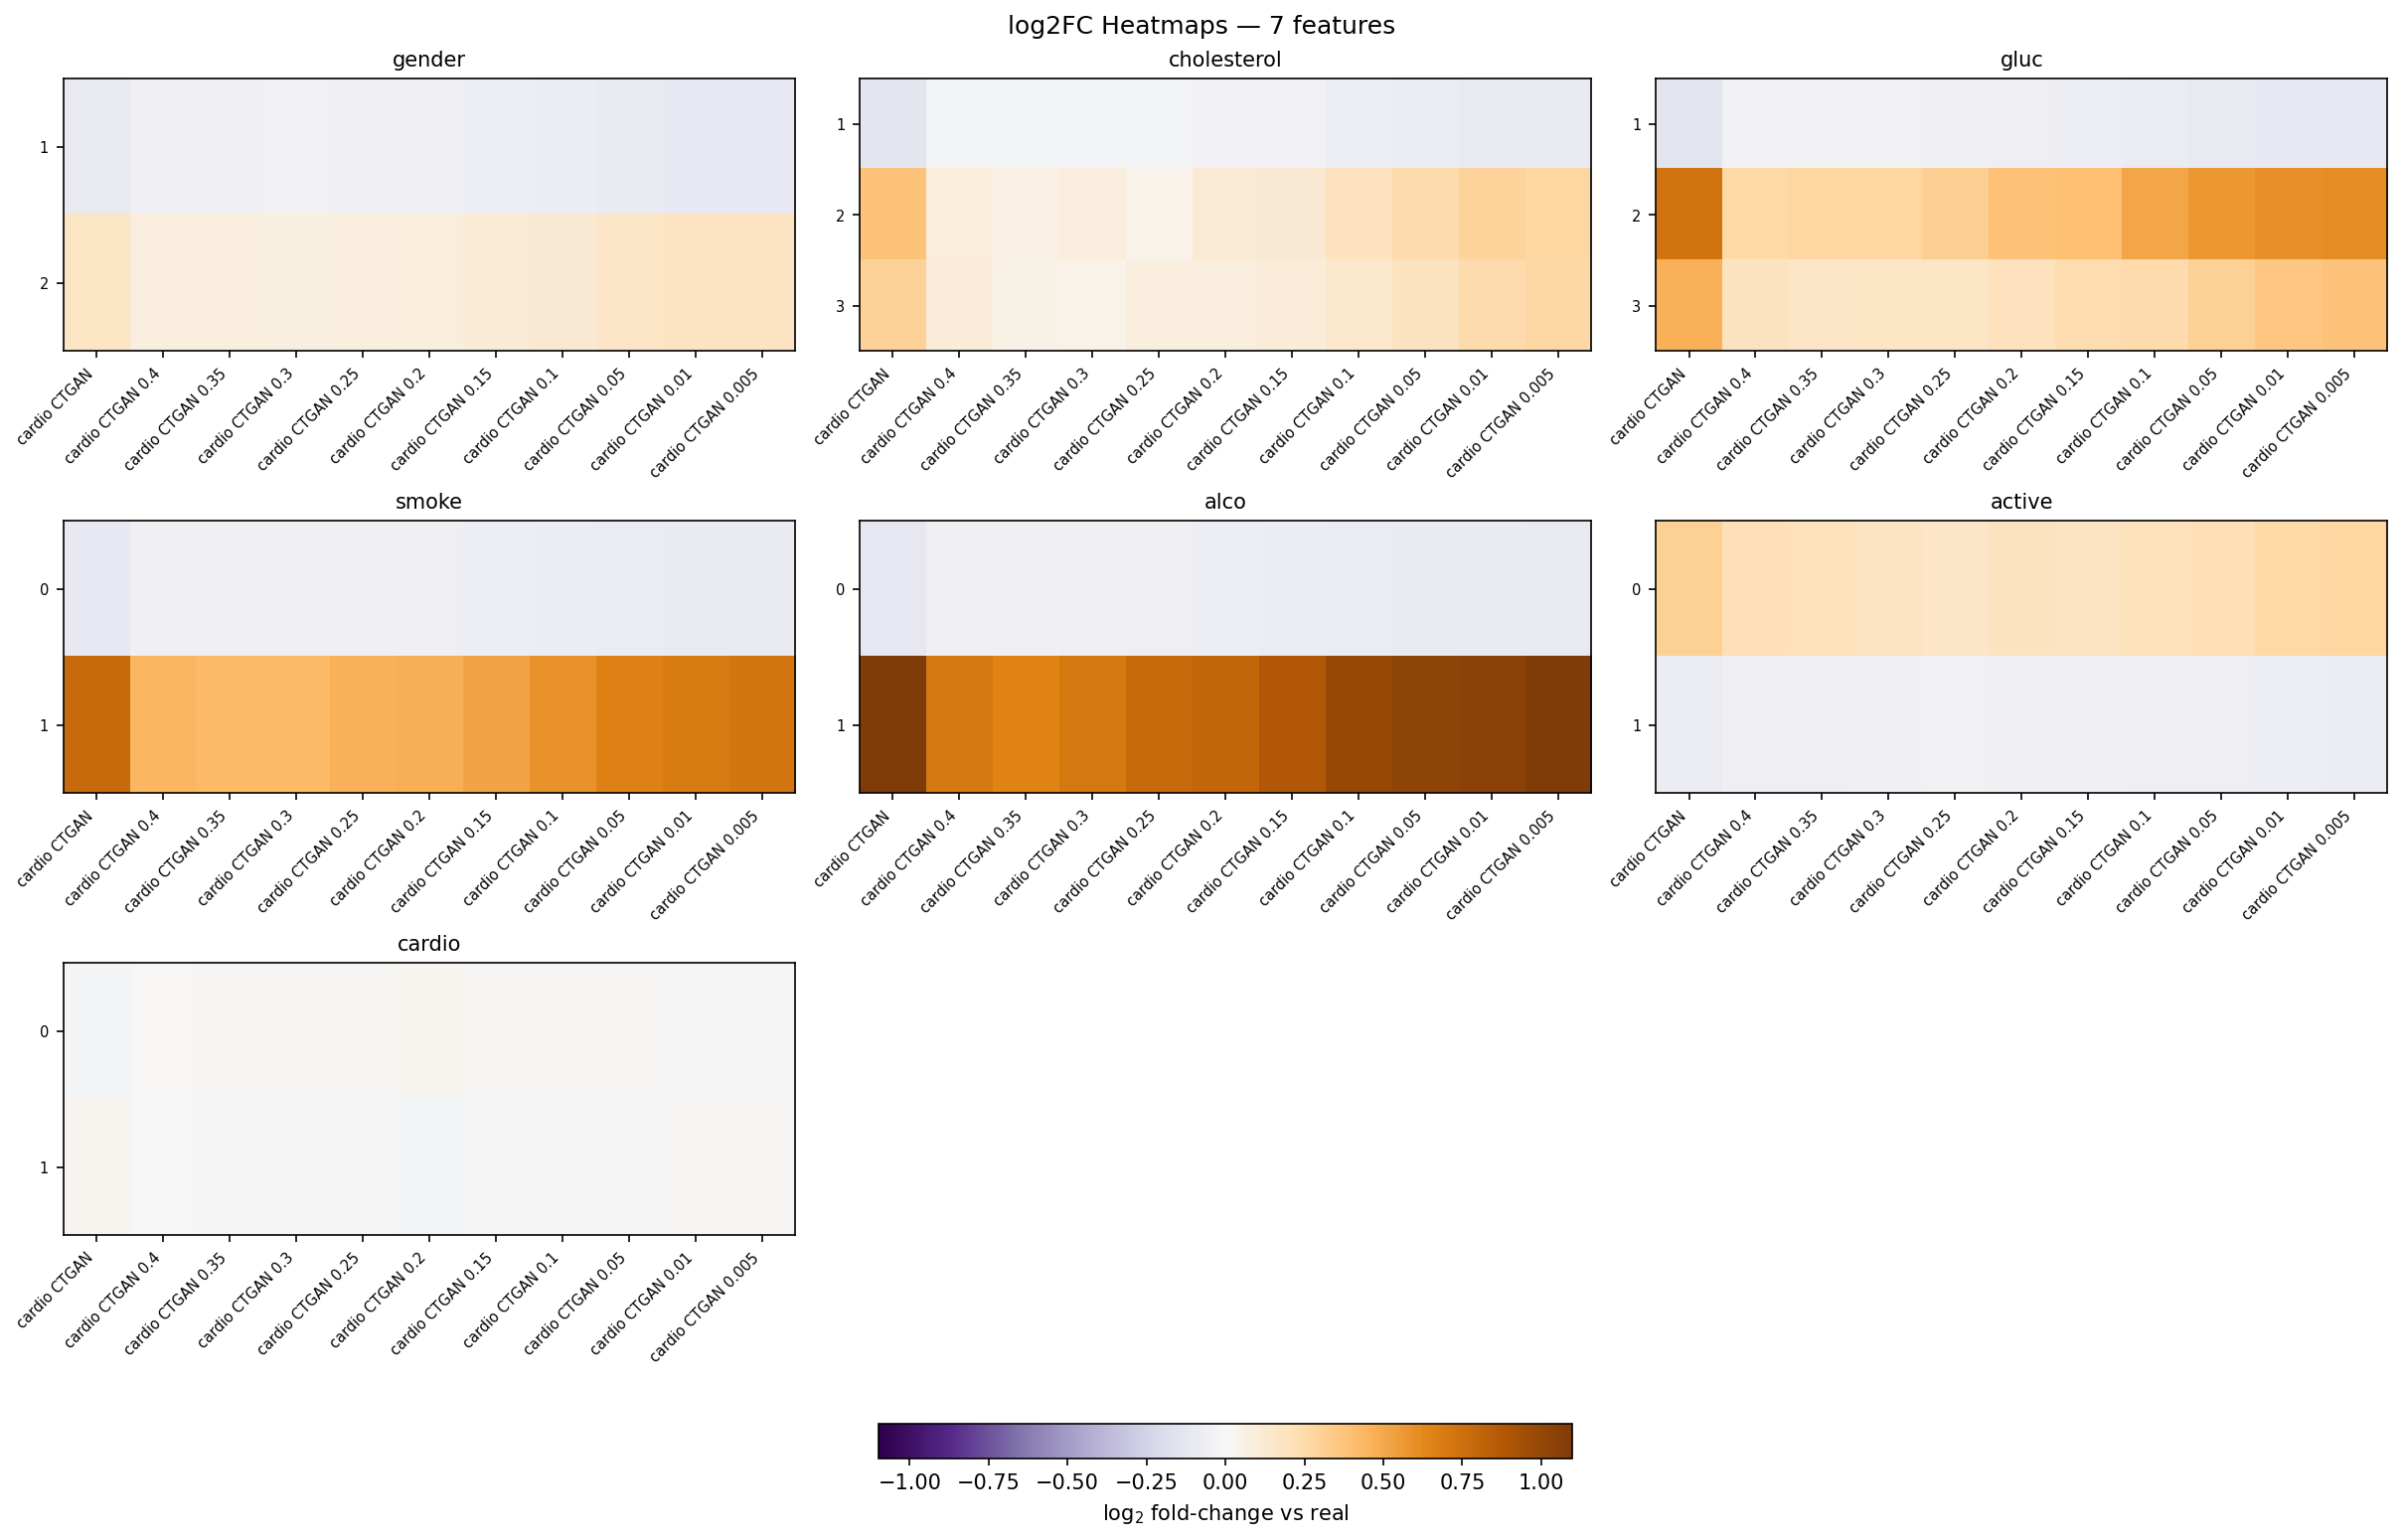

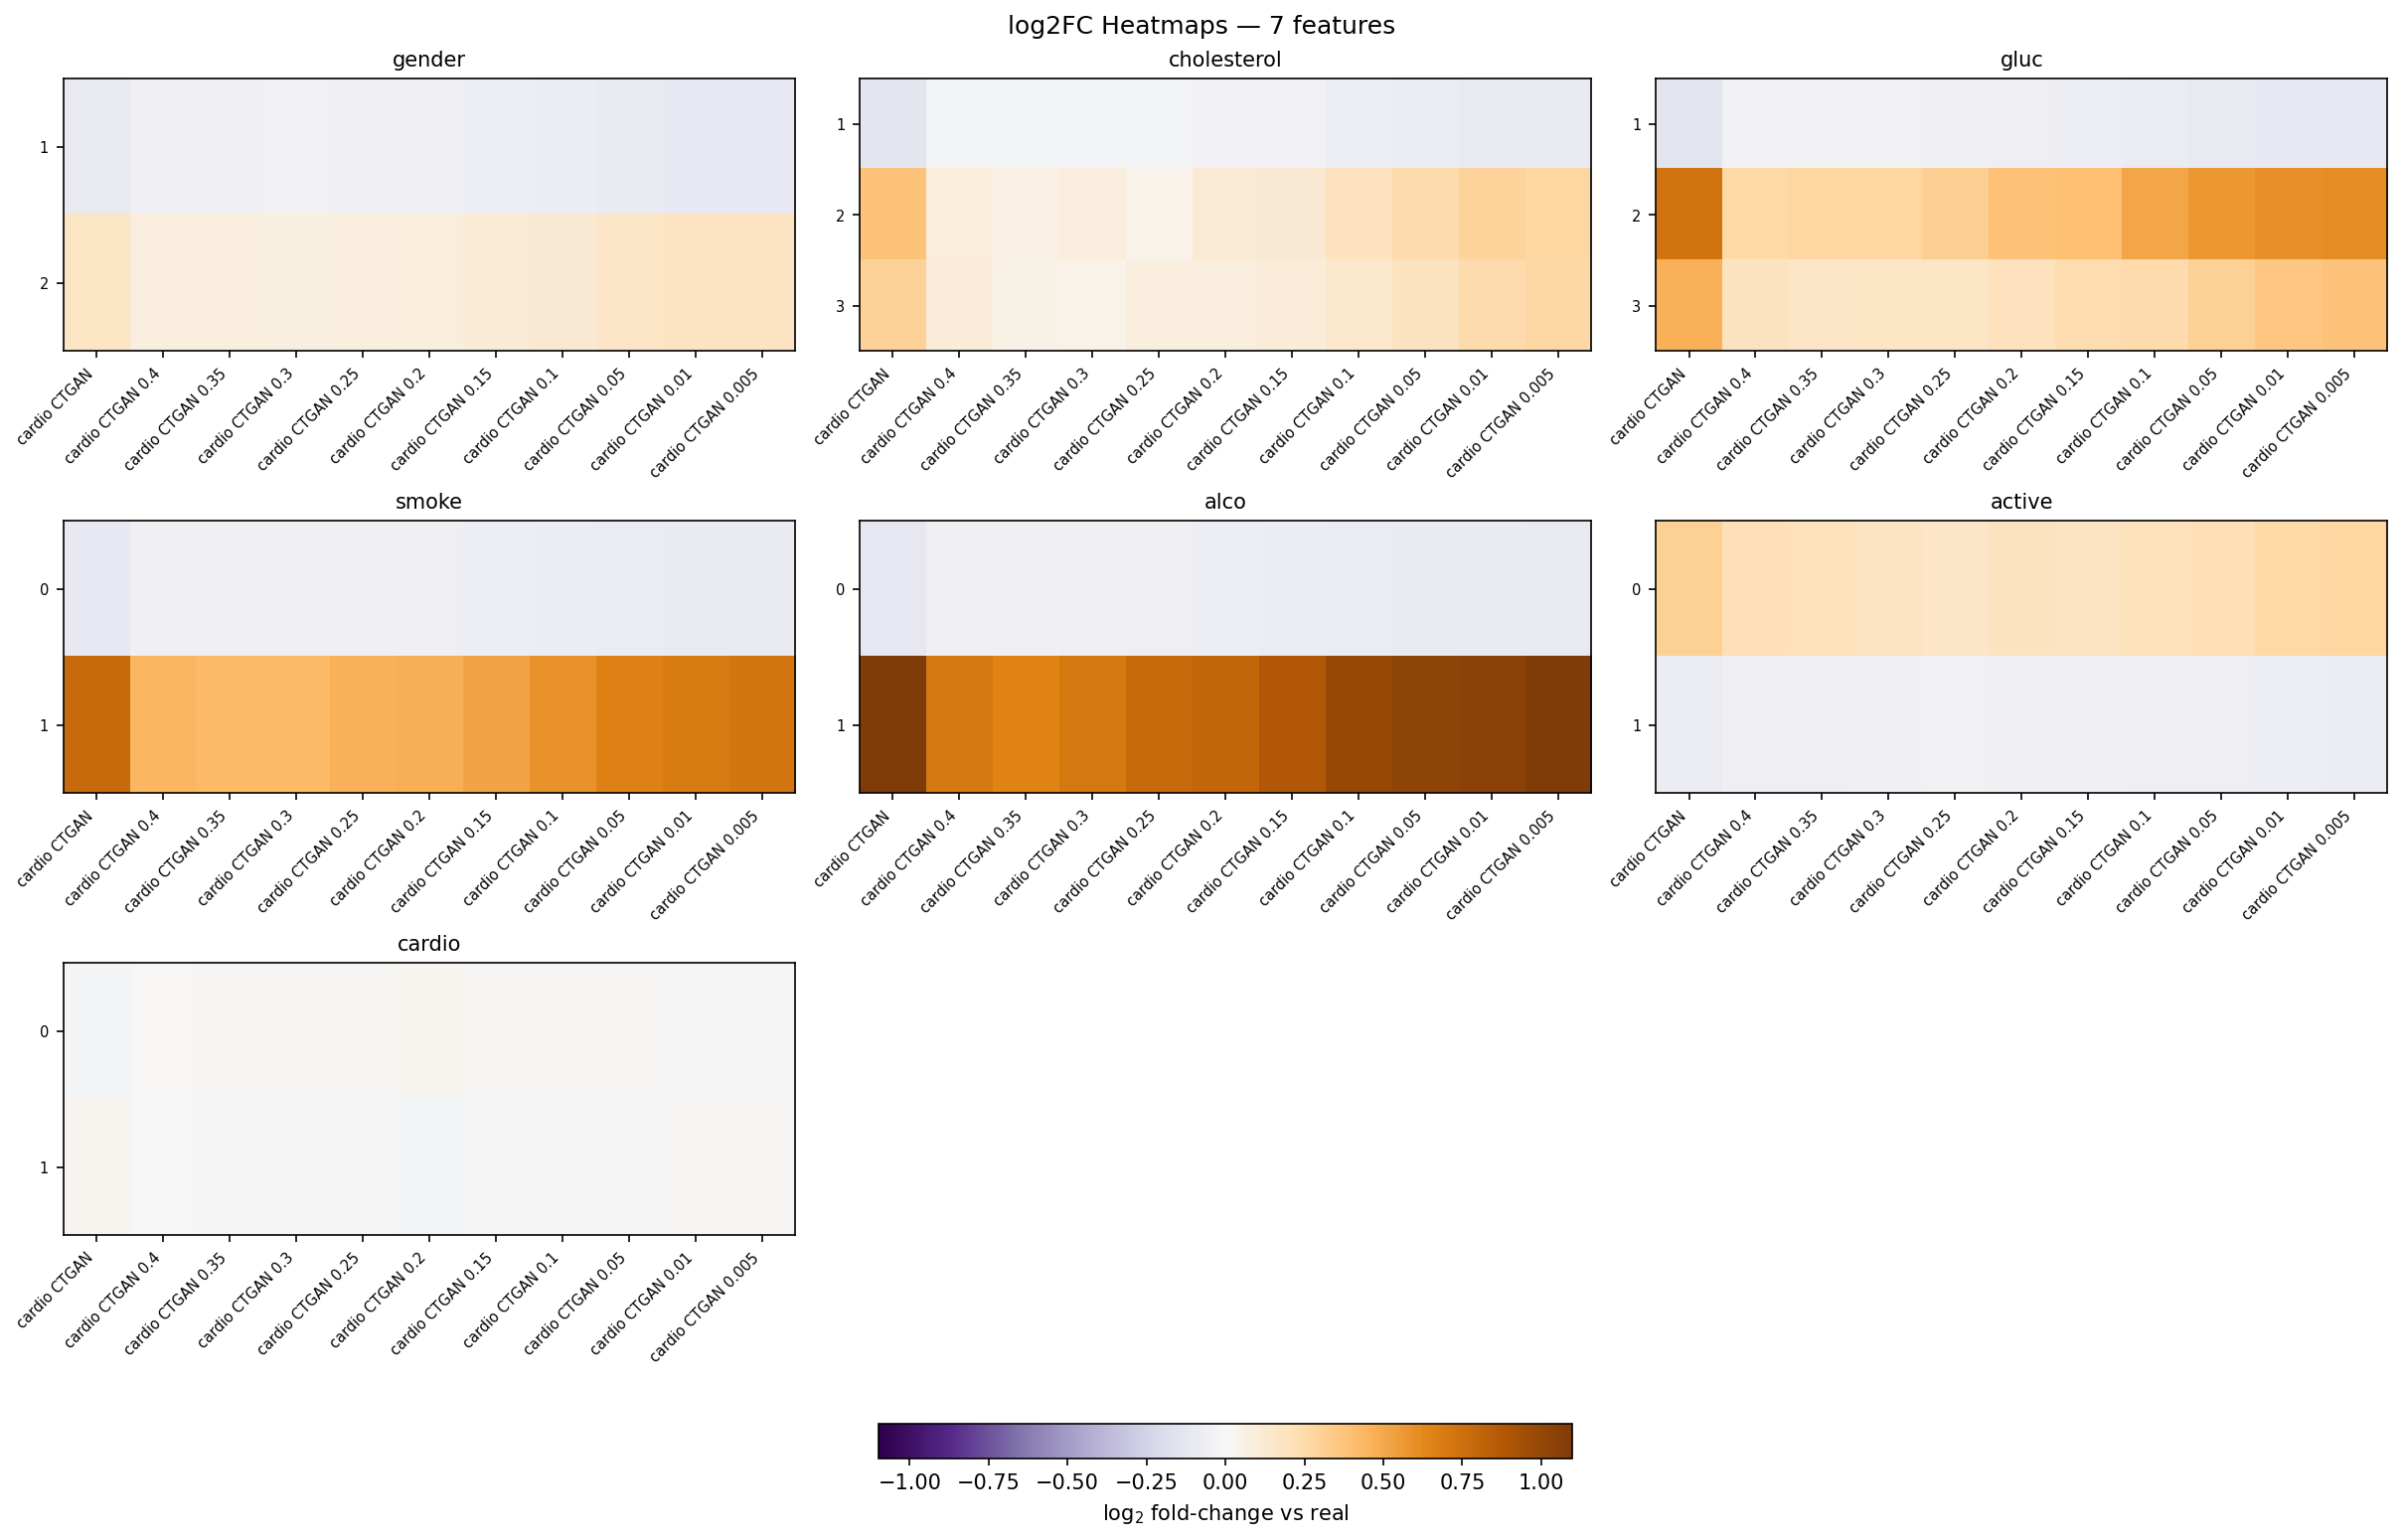

In [42]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_cardio_ctgan_heom_any['cardio CTGAN']['generation_results']['synthetic_data']
# synth_to_plot = ['cardio CTGAN','cardio CTGAN 0.01', 'cardio CTGAN 0.3']

datasets = {}
datasets['cardio REAL'] = df_real_cardio_train

for key, value in dict_results_cardio_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_cardio,
    num_features=num_list_cardio,
    baseline='cardio REAL',            # default: the highest ε becomes baseline
    out_dir="./analysis_out_cardio_ctgan", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])

synth = dict_results_cardio_ctgan_heom_any['cardio CTGAN']['generation_results']['synthetic_data']
# synth_to_plot = ['cardio CTGAN','cardio CTGAN 0.01', 'cardio CTGAN 0.3']

datasets = {}
datasets['cardio REAL'] = df_real_cardio_train

for key, value in dict_results_cardio_ctgan_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']
p1, cat_table = categorical_log2fc_table(datasets, cat_list_cardio, 'cardio REAL', "./analysis_out_cardio_ctgan", pseudocount=1e-6)
p2, num_table = numeric_heuristic_table(datasets, num_list_cardio, 'cardio REAL', "./analysis_out_cardio_ctgan", tail_q=(0.05, 0.95))
import pandas as pd

cat_table = pd.read_csv("./analysis_out_cardio_ctgan/categorical_log2fc_table.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_cardio_ctgan_heom_any]  # order by ε (high→low)

plot_log2fc_heatmaps_grid(
    cat_table,
    features=cat_list_cardio,
    dataset_order=datasets,
    top_k=30,
    order_by="baseline",
    ncols=3,
    figsize=(16, 10),
    save_path="./analysis_out_cardio_ctgan/plots/log2fc_heatmap_grid_cardio_ctgan.png",
)

In [20]:
epsilon = [ 'cardio CTGAN : baseline',
            'cardio CTGAN eps = 0.4',
            'cardio CTGAN eps = 0.35',
            'cardio CTGAN eps = 0.3',
            'cardio CTGAN eps = 0.25',
            'cardio CTGAN eps = 0.2',
            'cardio CTGAN eps = 0.15',
            'cardio CTGAN eps = 0.1',
            'cardio CTGAN eps = 0.05',
            'cardio CTGAN eps = 0.01',
            'cardio CTGAN eps = 0.005']
dict_results = dict_results_cardio_ctgan_heom_any
get_mean_univariate_evaluation_markdown(dict_results_cardio_ctgan_heom_any, epsilon)
print_js_cohen(dict_results_cardio_ctgan_heom_any, epsilon)

|                                |   cardio CTGAN : baseline |   cardio CTGAN eps = 0.4 |   cardio CTGAN eps = 0.35 |   cardio CTGAN eps = 0.3 |   cardio CTGAN eps = 0.25 |   cardio CTGAN eps = 0.2 |   cardio CTGAN eps = 0.15 |   cardio CTGAN eps = 0.1 |   cardio CTGAN eps = 0.05 |   cardio CTGAN eps = 0.01 |   cardio CTGAN eps = 0.005 |
|:-------------------------------|--------------------------:|-------------------------:|--------------------------:|-------------------------:|--------------------------:|-------------------------:|--------------------------:|-------------------------:|--------------------------:|--------------------------:|---------------------------:|
| categorical JS divergence mean |                 0.0615782 |                0.0280993 |                 0.0265847 |                0.0265241 |                 0.0286723 |                0.0319912 |                 0.0346214 |                0.0415725 |                 0.0472135 |                 0.0512394 |          

In [24]:
from data_synthesizer.privacy_sampling import get_epsilon_heom_any

synth = dict_results_cardio_ctgan_heom_any['cardio CTGAN']['generation_results']['synthetic_data']
df_real_cardio_train = DataLoader('../../data/cardio_train.csv').get_dataframe(cat_list_cardio)

synth = DataLoader.align_categoricals(synth, df_real_cardio_train, cat_list_cardio)
# get_epsilon_heom_any(df_real_cardio_train, synth, num_list_cardio, cat_list_cardio)
get_epsilon_heom_any(df_real_cardio_train, synth, num_list_cardio, cat_list_cardio)

0.6361428571428571

In [39]:
dict_js_cat

{'gender': array([0.03490982, 0.03934366, 0.03490982, 0.02863046, 0.02345442,
        0.01967807, 0.01815425, 0.01662893, 0.017939  , 0.01795694,
        0.03872357]),
 'cholesterol': array([0.03943838, 0.04843442, 0.03943838, 0.03063097, 0.01934831,
        0.017494  , 0.01084083, 0.01142994, 0.01102507, 0.0162433 ,
        0.0624777 ]),
 'gluc': array([0.06203394, 0.06715993, 0.06203394, 0.05359414, 0.04351616,
        0.04022014, 0.03280749, 0.02865364, 0.02870513, 0.02847905,
        0.08615782]),
 'smoke': array([0.06998852, 0.07277467, 0.06998852, 0.06082245, 0.05305986,
        0.04789592, 0.04702793, 0.04244213, 0.04196151, 0.04388001,
        0.08305661]),
 'alco': array([0.08740235, 0.08971478, 0.08740235, 0.0841082 , 0.07291991,
        0.06575702, 0.0631316 , 0.0571104 , 0.05209822, 0.05629152,
        0.10632734]),
 'active': array([0.03354948, 0.03840592, 0.03354948, 0.02994499, 0.02594336,
        0.02736356, 0.02428929, 0.02611062, 0.0306717 , 0.03237097,
        0.0476

In [ ]:
resemblance_evaluation = {}

for key in dict_results_cardio_tvae_heom_any :
    resemblance_evaluation[key] = dict_results_cardio_tvae_heom_any[key]['resemblance_evaluation_results']
resemblance_evaluation

{'cardio TVAE': {'categorical_univariate': {'chi_test':              chisquared_tests_p
   gender                 0.505483
   cholesterol            0.599544
   gluc                   0.632678
   smoke                  0.622372
   alco                   0.527808
   active                 0.070665
   cardio                 0.563824,
   'jensen_shanon':              KL_divergence_tests  JS_divergence
   gender                  0.000005       0.001381
   cholesterol             0.000355       0.011359
   gluc                    0.000253       0.009612
   smoke                   0.000607       0.014664
   alco                    0.003751       0.035593
   active                  0.000387       0.011854
   cardio                  0.000121       0.006604,
   'jensen_shanon_data_mean': KL_divergence_tests    0.000783
   JS_divergence          0.013010
   dtype: float64,
   'mode_collapse_dict': {}},
  'numerical_univariate': {'univariate_num_s':         mann_whitney       wilcoxon      studen

: 

Per-feature divergences: ./analysis_out_cardio_tvae/divergence_table.csv
Ranking table: ./analysis_out_cardio_tvae/ranking_table.csv
Plots: ./analysis_out_cardio_tvae/plots


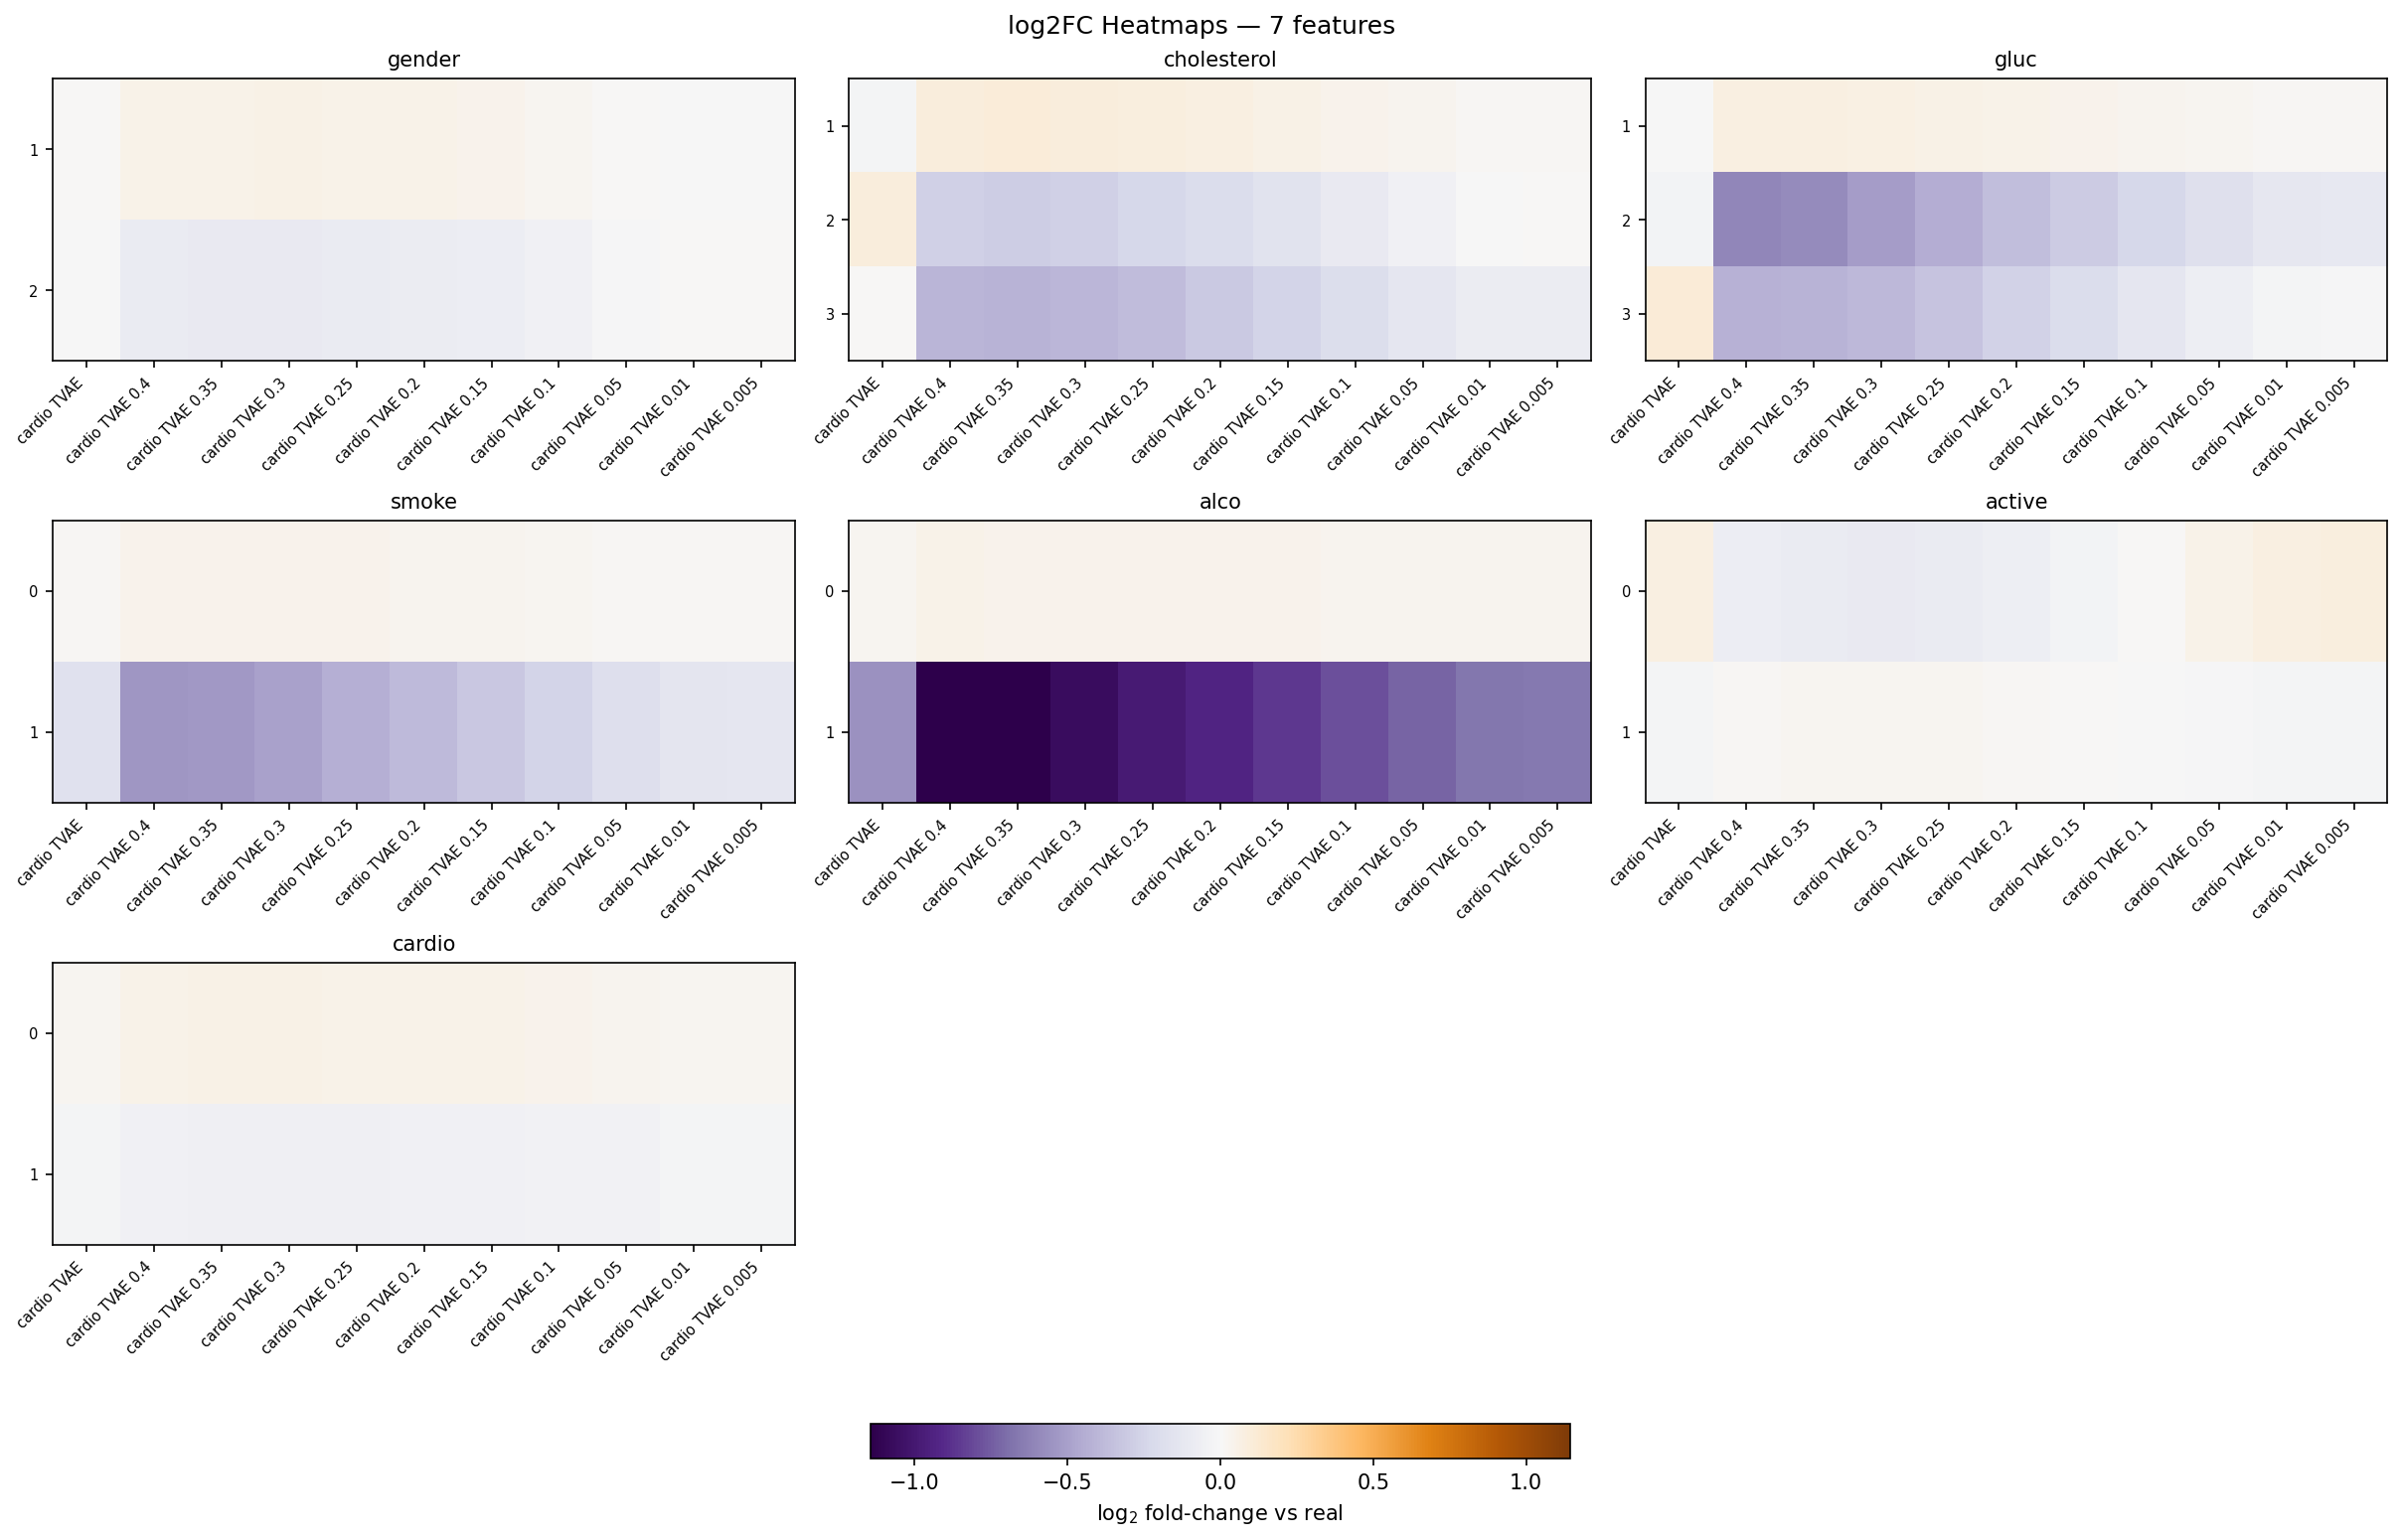

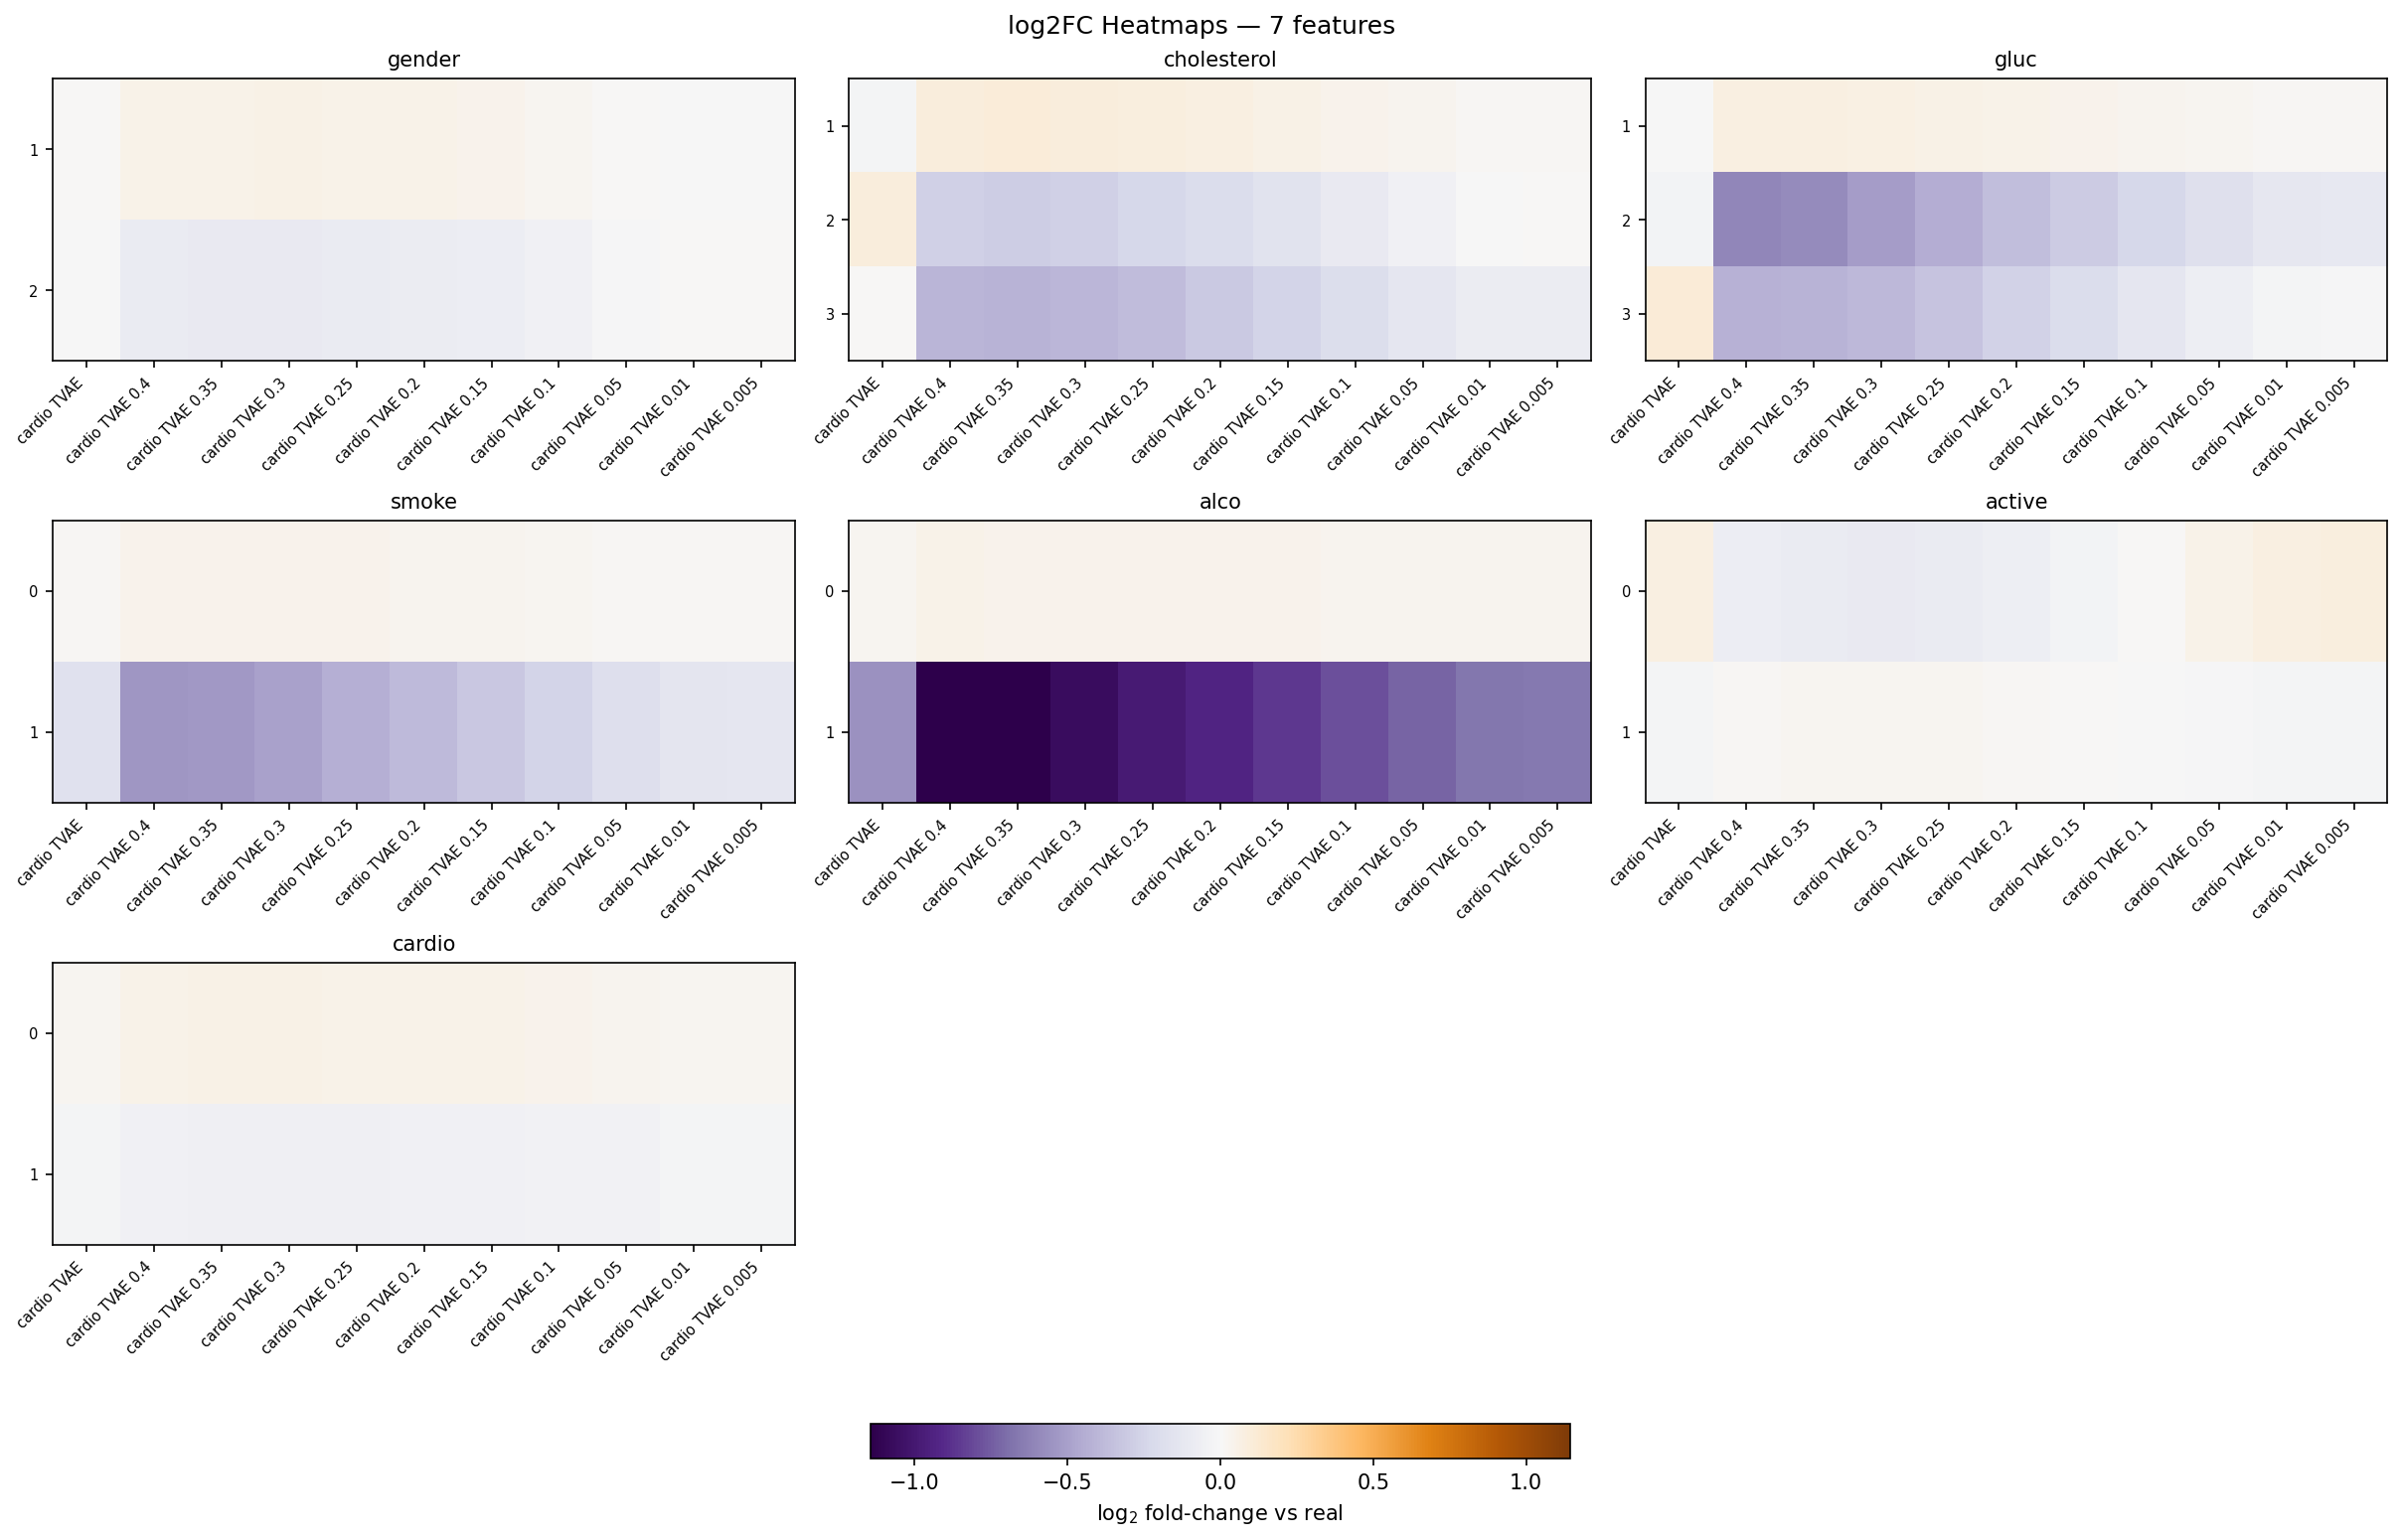

In [43]:
import pandas as pd

# Suppose you already have 4 synthetic variants made with the same generator,
# differing ONLY by ε_ANY thresholds applied post-hoc.
# Each DataFrame has identical columns.

synth = dict_results_cardio_tvae_heom_any['cardio TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['cardio TVAE','cardio TVAE 0.01', 'cardio TVAE 0.3']

datasets = {}
datasets['cardio REAL'] = df_real_cardio_train

for key, value in dict_results_cardio_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']


res = analyze_synth_distributions(
    datasets=datasets,
    cat_features= cat_list_cardio,
    num_features=num_list_cardio,
    baseline='cardio REAL',            # default: the highest ε becomes baseline
    out_dir="./analysis_out_cardio_tvae", # outputs CSVs and PNGs here
    kde_points=512,
    kde_bw_adjust=1.0,
    density_diff_threshold=0.20,  # shade areas where variant differs >20% from baseline density
    max_categories_to_plot=20,
    figure_dpi=150,
)

print("Per-feature divergences:", res["divergence_table_path"])
print("Ranking table:", res["ranking_table_path"])
print("Plots:", res["plot_dir"])

synth = dict_results_cardio_tvae_heom_any['cardio TVAE']['generation_results']['synthetic_data']
# synth_to_plot = ['cardio TVAE','cardio TVAE 0.01', 'cardio TVAE 0.3']

datasets = {}
datasets['cardio REAL'] = df_real_cardio_train

for key, value in dict_results_cardio_tvae_heom_any.items():
    # if key in  synth_to_plot:
    datasets[key] = value['generation_results']['synthetic_data']
p1, cat_table = categorical_log2fc_table(datasets, cat_list_cardio, 'cardio REAL', "./analysis_out_cardio_tvae", pseudocount=1e-6)
p2, num_table = numeric_heuristic_table(datasets, num_list_cardio, 'cardio REAL', "./analysis_out_cardio_tvae", tail_q=(0.05, 0.95))
import pandas as pd

cat_table = pd.read_csv("./analysis_out_cardio_tvae/categorical_log2fc_table.csv")
# feature = "PAY_0"
datasets = [key for key in dict_results_cardio_tvae_heom_any]  # order by ε (high→low)

plot_log2fc_heatmaps_grid(
    cat_table,
    features=cat_list_cardio,
    dataset_order=datasets,
    top_k=30,
    order_by="baseline",
    ncols=3,
    figsize=(16, 10),
    save_path="./analysis_out_cardio_tvae/plots/log2fc_heatmap_grid_cardio_tvae.png",
)

In [21]:
epsilon = [ 'cardio TVAE : baseline',
            'cardio TVAE eps = 0.4',
            'cardio TVAE eps = 0.35',
            'cardio TVAE eps = 0.3',
            'cardio TVAE eps = 0.25',
            'cardio TVAE eps = 0.2',
            'cardio TVAE eps = 0.15',
            'cardio TVAE eps = 0.1',
            'cardio TVAE eps = 0.05',
            'cardio TVAE eps = 0.01',
            'cardio TVAE eps = 0.005']
dict_results = dict_results_cardio_tvae_heom_any
get_mean_univariate_evaluation_markdown(dict_results_cardio_tvae_heom_any, epsilon)
print_js_cohen(dict_results_cardio_tvae_heom_any, epsilon)

|                                |   cardio TVAE : baseline |   cardio TVAE eps = 0.4 |   cardio TVAE eps = 0.35 |   cardio TVAE eps = 0.3 |   cardio TVAE eps = 0.25 |   cardio TVAE eps = 0.2 |   cardio TVAE eps = 0.15 |   cardio TVAE eps = 0.1 |   cardio TVAE eps = 0.05 |   cardio TVAE eps = 0.01 |   cardio TVAE eps = 0.005 |
|:-------------------------------|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|------------------------:|-------------------------:|-------------------------:|--------------------------:|
| categorical JS divergence mean |                0.0130098 |               0.0386188 |                0.038987  |               0.037345  |                0.0338463 |               0.0298856 |                0.0254568 |               0.0199394 |                0.0161222 |                0.0133332 |                 0.0131373 |
| numerical c